<a href="https://colab.research.google.com/github/giovanisaavedra/FIAP/blob/main/ANO%201/FASE%2006/CAP.01%20-%20O%20DESPERTAR%20DA%20REDE%20NEURAL/00%20-%20PROJETO/Fase06-Cap01-Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Fase 6 — Visão Computacional



### **Grupo 12** - Integrantes

- **Nome:** Giovani Saavedra - RM566797
- **Nome:** Marcio Elifas - RM567871
- **Nome:** Felipe Bernardo Papeleo de Oliveira - RM567782

- **Disciplina:** PBL Fase 6 — FIAP


---


## Contexto

A FarmTech Solutions está expandindo seus serviços de IA para além do agronegócio,
atuando agora também na área de Visão Computacional. Como integrante do time de
desenvolvedores, este notebook documenta a construção e avaliação de um sistema de
visão computacional, com o objetivo de demonstrar ao cliente o potencial e a
acurácia de diferentes abordagens de Deep Learning aplicadas a um mesmo problema.

## Objetivo

Construir um sistema capaz de identificar dois objetos distintos — **gato** e
**cachorro** — em imagens, e comparar criticamente o desempenho de diferentes
abordagens de visão computacional sobre a mesma base de dados.

## Abordagens implementadas

Conforme as Entregas 1 e 2 do enunciado, são implementadas três abordagens
obrigatórias e uma quarta como exploração extra:

1. **YOLO customizada** (Entrega 1) — modelo YOLOv5s ajustado por transfer learning
   com 30 e 60 épocas sobre o nosso dataset, comparando o impacto da quantidade de
   épocas no desempenho do modelo
2. **YOLO padrão** (Entrega 2) — uso direto do modelo `yolov5s.pt` pré-treinado no
   dataset COCO, sem treino adicional
3. **CNN treinada do zero** (Entrega 2) — rede convolucional construída e treinada
   totalmente a partir de pesos aleatórios, em TensorFlow/Keras
4. **Transfer Learning com MobileNetV2** (extra) — implementação parcial da segunda
   opção do "Ir Além" (item 3.2 do enunciado), limitada ao Transfer Learning sem a
   etapa de segmentação

Ao final, as quatro abordagens são comparadas criticamente nas dimensões exigidas
pelo enunciado: facilidade de uso, precisão, tempo de treinamento e tempo de
inferência.

## Dataset

- **Objeto A:** Gato (40 imagens)
- **Objeto B:** Cachorro (40 imagens)
- **Total:** 80 imagens
- **Divisão:** 64 treino / 8 validação / 8 teste
- **Fonte:** Oxford-IIIT Pet Dataset (via Kaggle)

## Estrutura do notebook

### Entrega 1 — YOLO customizada
1. Instalação do YOLOv5
2. Configuração do dataset (arquivo `.yaml`)
3. Treinamento — Experimento 1 (30 épocas)
4. Análise dos resultados — Experimento 1
5. Retreinamento com dataset corrigido (identificação e correção de bug nos labels)
6. Experimento 2 — Treino com 60 épocas e comparação com 30 épocas
7. Etapa de teste do melhor modelo nas 8 imagens não vistas

### Entrega 2 — Comparação com outras abordagens
8. YOLO padrão (sem customização)
9. CNN treinada do zero (TensorFlow/Keras)

### Bônus — Demonstração extra
10. Transfer Learning com MobileNetV2

### Análise final
11. Comparativo das quatro abordagens nas dimensões do enunciado
12. Conclusões finais do projeto

In [ ]:
# Conecta o Google Drive ao Colab para acessar o dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define os caminhos base do projeto no Google Drive
import os

# Caminho base do dataset
DATASET_PATH = '/content/drive/MyDrive/FIAP/fase06-cap01/dataset'

# Caminhos das imagens
TRAIN_IMG = os.path.join(DATASET_PATH, 'images/train')
VAL_IMG   = os.path.join(DATASET_PATH, 'images/val')
TEST_IMG  = os.path.join(DATASET_PATH, 'images/test')

# Caminhos dos labels
TRAIN_LBL = os.path.join(DATASET_PATH, 'labels/train')
VAL_LBL   = os.path.join(DATASET_PATH, 'labels/val')

# Verifica se as pastas existem e conta os arquivos
print("=== Verificação do Dataset ===\n")
for nome, caminho in [
    ('Imagens treino', TRAIN_IMG),
    ('Imagens validação', VAL_IMG),
    ('Imagens teste', TEST_IMG),
    ('Labels treino', TRAIN_LBL),
    ('Labels validação', VAL_LBL),
]:
    if os.path.exists(caminho):
        qtd = len(os.listdir(caminho))
        print(f"✅ {nome}: {qtd} arquivos em {caminho}")
    else:
        print(f"❌ {nome}: pasta NÃO encontrada em {caminho}")

=== Verificação do Dataset ===

✅ Imagens treino: 64 arquivos em /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/train
✅ Imagens validação: 8 arquivos em /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/val
✅ Imagens teste: 8 arquivos em /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test
✅ Labels treino: 64 arquivos em /content/drive/MyDrive/FIAP/fase06-cap01/dataset/labels/train
✅ Labels validação: 8 arquivos em /content/drive/MyDrive/FIAP/fase06-cap01/dataset/labels/val


## 1. Instalação do YOLOv5

Nesta etapa, clonamos o repositório oficial do YOLOv5 (Ultralytics) e instalamos
todas as suas dependências. O YOLOv5 é um modelo de detecção de objetos em tempo
real, conhecido por sua boa relação entre velocidade e precisão.

In [ ]:
# Clona o repositório oficial do YOLOv5 da Ultralytics
!git clone https://github.com/ultralytics/yolov5.git

# Entra na pasta do YOLOv5
%cd yolov5

# Instala as dependências necessárias
!pip install -qr requirements.txt

# Verifica a versão do PyTorch e se a GPU está disponível
import torch
print(f"\n✅ PyTorch versão: {torch.__version__}")
print(f"✅ CUDA disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU em uso: {torch.cuda.get_device_name(0)}")

Cloning into 'yolov5'...
remote: Enumerating objects: 17924, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 17924 (delta 80), reused 48 (delta 48), pack-reused 17825 (from 2)
Receiving objects: 100% (17924/17924), 17.04 MiB | 15.51 MiB/s, done.
Resolving deltas: 100% (12211/12211), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 14.8 MB/s eta 0:00:00

✅ PyTorch versão: 2.10.0+cu128
✅ CUDA disponível: True
✅ GPU em uso: Tesla T4


## 2. Configuração do Dataset (arquivo .yaml)

O YOLOv5 precisa de um arquivo de configuração no formato YAML que informa:

- **path**: caminho base onde está o dataset
- **train**: caminho relativo das imagens de treino
- **val**: caminho relativo das imagens de validação
- **test**: caminho relativo das imagens de teste (opcional)
- **nc**: número de classes (no nosso caso, 2: gato e cachorro)
- **names**: nome de cada classe na ordem definida durante a rotulação no Make Sense

A ordem dos nomes em `names` é **crítica**: precisa ser exatamente a mesma ordem
em que as classes foram definidas no Make Sense AI.

In [ ]:
# Cria o arquivo de configuração do dataset (formato YAML)
yaml_content = """
# Configuração do dataset para YOLOv5
# Projeto Fase 6 - Detecção de gatos e cachorros

path: /content/drive/MyDrive/FIAP/fase06-cap01/dataset  # caminho base
train: images/train  # caminho relativo das imagens de treino
val: images/val      # caminho relativo das imagens de validação
test: images/test    # caminho relativo das imagens de teste

# Número de classes
nc: 2

# Nome de cada classe (ordem definida no Make Sense)
names: ['gato', 'cachorro']
"""

# Salva o arquivo na pasta data/ do YOLOv5
yaml_path = '/content/yolov5/data/petshop.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

# Confirma a criação e exibe o conteúdo
print(f"✅ Arquivo criado em: {yaml_path}\n")
print("=== Conteúdo do .yaml ===")
!cat {yaml_path}

✅ Arquivo criado em: /content/yolov5/data/petshop.yaml

=== Conteúdo do .yaml ===

# Configuração do dataset para YOLOv5
# Projeto Fase 6 - Detecção de gatos e cachorros

path: /content/drive/MyDrive/FIAP/fase06-cap01/dataset  # caminho base
train: images/train  # caminho relativo das imagens de treino
val: images/val      # caminho relativo das imagens de validação
test: images/test    # caminho relativo das imagens de teste

# Número de classes
nc: 2

# Nome de cada classe (ordem definida no Make Sense)
names: ['gato', 'cachorro']


## 3. Treinamento do Modelo — Experimento 1 (30 épocas)

Vamos treinar o YOLOv5 no nosso dataset customizado de gatos e cachorros. Os principais parâmetros são:

- **--img 640**: redimensiona as imagens para 640x640 pixels (padrão do YOLOv5)
- **--batch 16**: processa 16 imagens por vez (ajustável conforme a memória da GPU)
- **--epochs 30**: número de épocas de treino (uma "época" = uma passagem completa pelo dataset)
- **--data**: caminho para o arquivo .yaml com a configuração do dataset
- **--weights yolov5s.pt**: pesos pré-treinados do modelo "small" (transfer learning a partir do COCO)
- **--name exp_30epochs**: nome da pasta onde os resultados serão salvos

O modelo `yolov5s` é a versão "small" — boa para datasets pequenos como o nosso (80 imagens), pois treina rápido e tem menor risco de overfitting.

Os resultados ficarão em `yolov5/runs/train/exp_30epochs/`.

In [ ]:
# Desabilita o Weights & Biases (W&B) para não pedir login interativo
import os
os.environ['WANDB_MODE'] = 'disabled'

# Também desinstala o W&B só para garantir
!pip uninstall -y wandb -q

print("✅ W&B desabilitado")

✅ W&B desabilitado


In [ ]:
# Garante que estamos na pasta do YOLOv5
%cd /content/yolov5

# Executa o treinamento com 30 épocas
!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 30 \
  --data /content/yolov5/data/petshop.yaml \
  --weights yolov5s.pt \
  --name exp_30epochs \
  --project runs/train

/content/yolov5
2026-04-27 14:00:31.838048: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777298431.873439    5295 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777298431.884656    5295 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777298431.912426    5295 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777298431.912465    5295 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777298431.912473    5295 computation_placer.cc:177] comput

## 4. Análise dos Resultados — Experimento 1 (30 épocas)

O treinamento foi concluído em aproximadamente 1.4 minutos na GPU Tesla T4. Abaixo, as métricas finais obtidas na validação:

| Classe | Imagens | Instâncias | Precision (P) | Recall (R) | mAP@0.5 | mAP@0.5:0.95 |
|--------|---------|------------|---------------|------------|---------|--------------|
| **all** | 8 | 8 | 0.500 | 0.206 | 0.420 | 0.253 |
| gato | 8 | 4 | 1.000 | 0.411 | 0.575 | 0.379 |
| cachorro | 8 | 4 | 0.000 | 0.000 | 0.265 | 0.127 |

### Interpretação das métricas

- **Precision (P):** dos objetos detectados, quantos estavam corretos
- **Recall (R):** dos objetos que existiam, quantos foram detectados
- **mAP@0.5:** média da precisão considerando IoU ≥ 0.5 (métrica principal do YOLO)
- **mAP@0.5:0.95:** média mais rigorosa, varia o IoU de 0.5 a 0.95

### Observações iniciais

1. A classe **gato** apresentou Precision perfeita (1.0), mas Recall baixo (0.41) — o modelo é "cauteloso": quando diz que é gato, acerta sempre, mas deixa de detectar muitos gatos.
2. A classe **cachorro** apresentou métricas zeradas em P e R — o modelo praticamente não conseguiu detectar cachorros nas imagens de validação.
3. O dataset tem alta variabilidade intra-classe: as imagens de cachorro contêm múltiplas raças muito distintas (bulldog, pit bull, basset hound, beagle, etc.), o que dificulta o aprendizado de uma representação genérica de "cachorro" com poucos exemplos.

Vamos agora visualizar os gráficos gerados pelo YOLOv5 para entender melhor o comportamento do modelo ao longo do treino.

### 4.1 Gráficos gerados durante o treinamento

O YOLOv5 gera automaticamente diversos artefatos durante o treinamento, salvos em
`runs/train/exp_30epochs2/`. Os principais são:

- **results.png:** evolução das losses e métricas ao longo das épocas
- **confusion_matrix.png:** matriz de confusão entre as classes
- **labels.jpg:** distribuição dos labels no dataset de treino
- **train_batch*.jpg:** exemplos de imagens de treino com bounding boxes
- **val_batch*.jpg:** exemplos de validação (predições do modelo vs ground truth)
- **PR_curve.png, P_curve.png, R_curve.png, F1_curve.png:** curvas de avaliação


📈 Evolução das losses e métricas ao longo das épocas


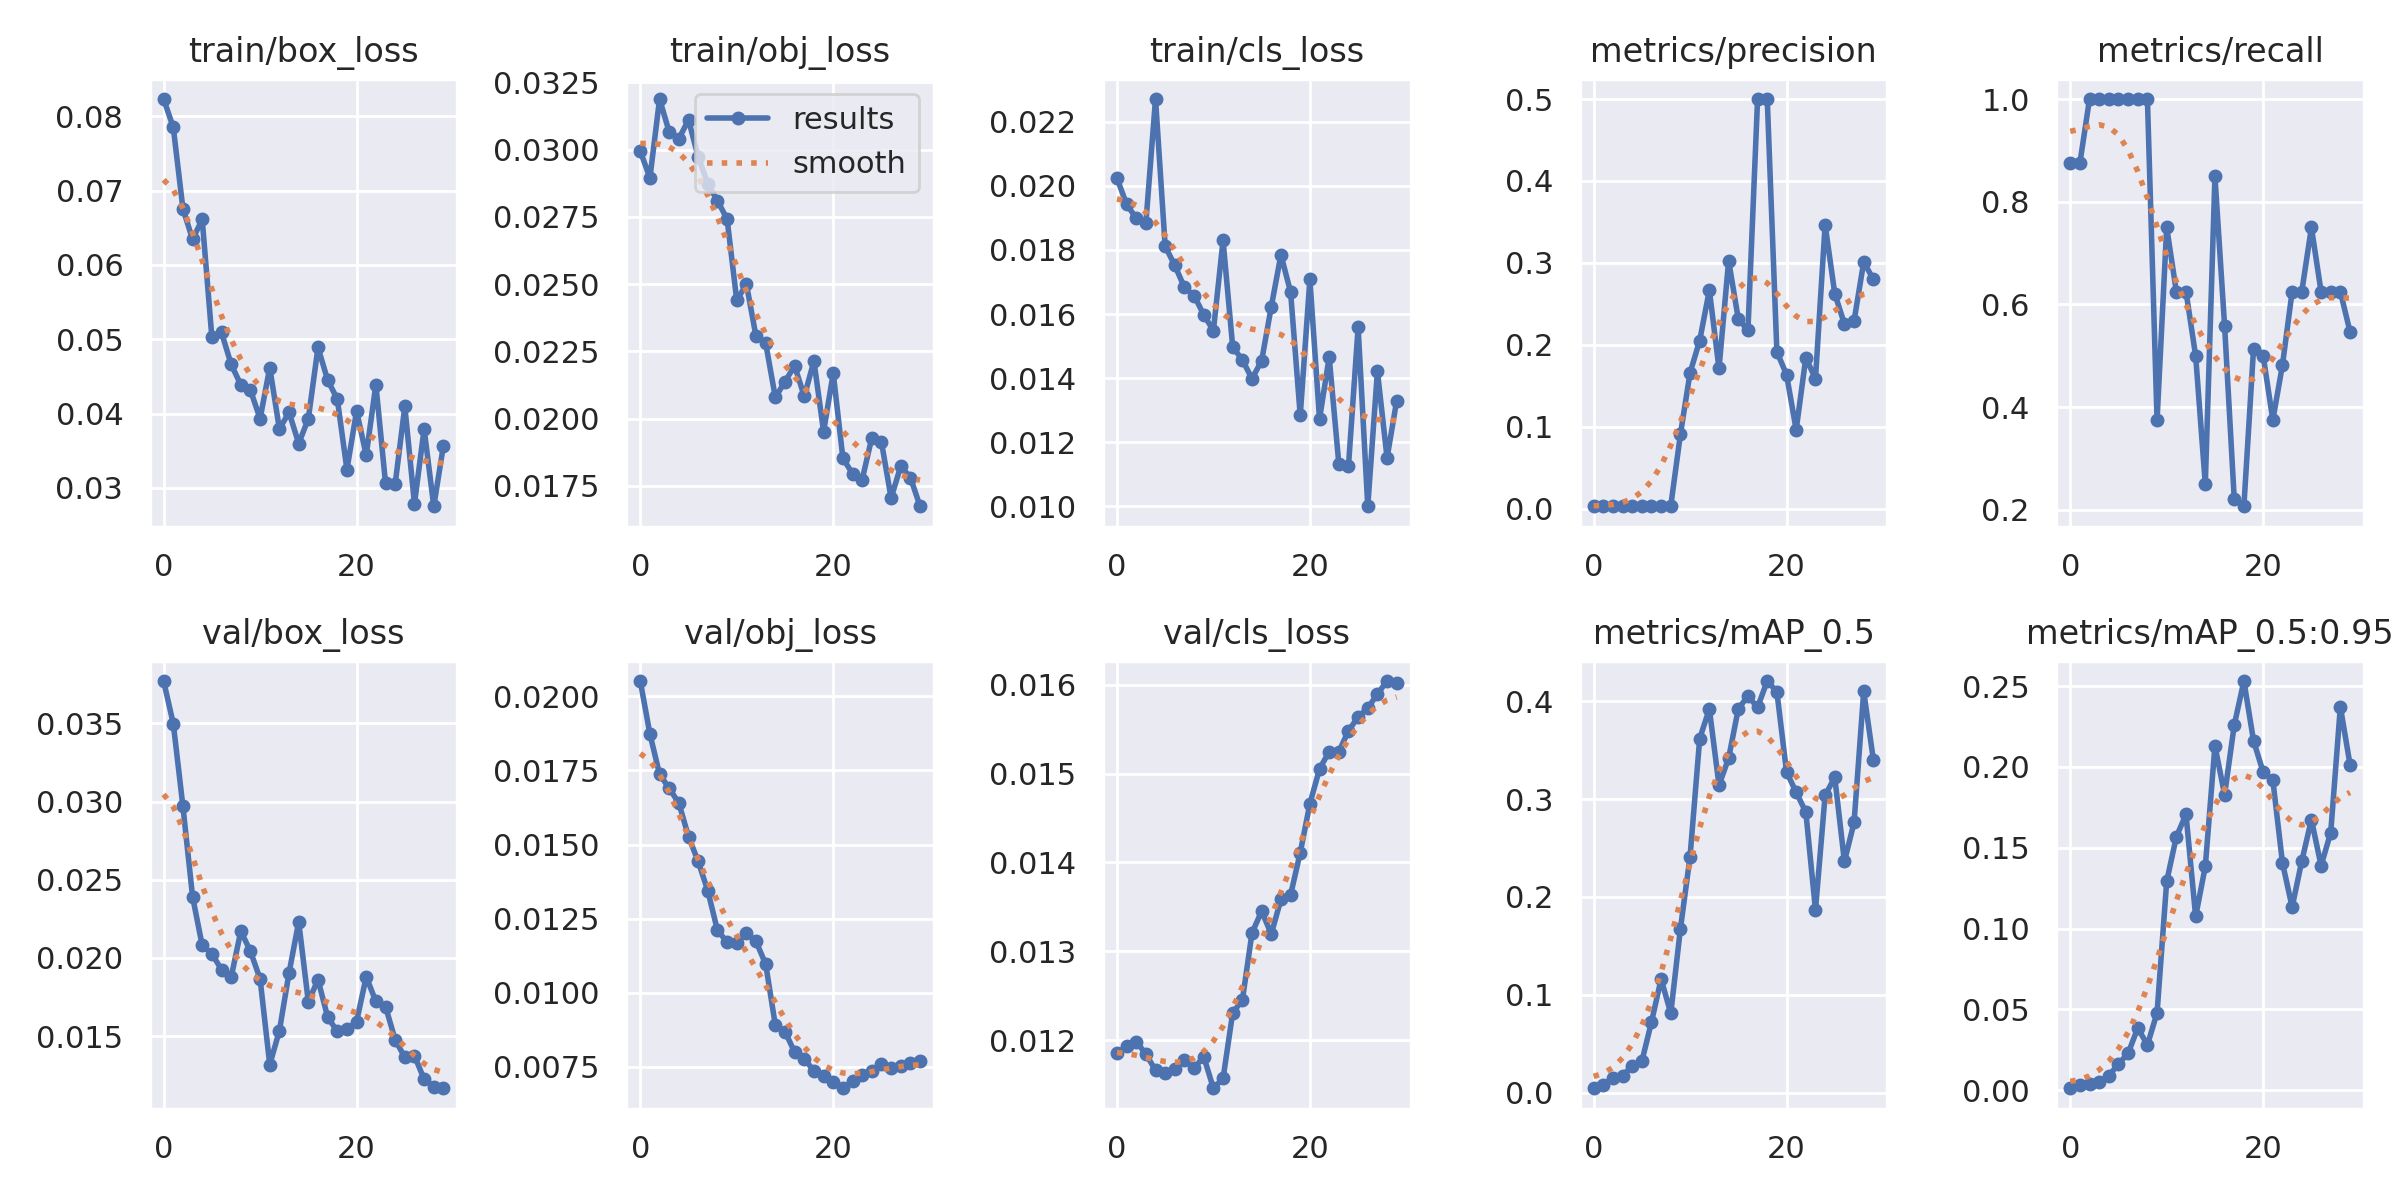


🎯 Matriz de confusão (predições vs verdadeiro)


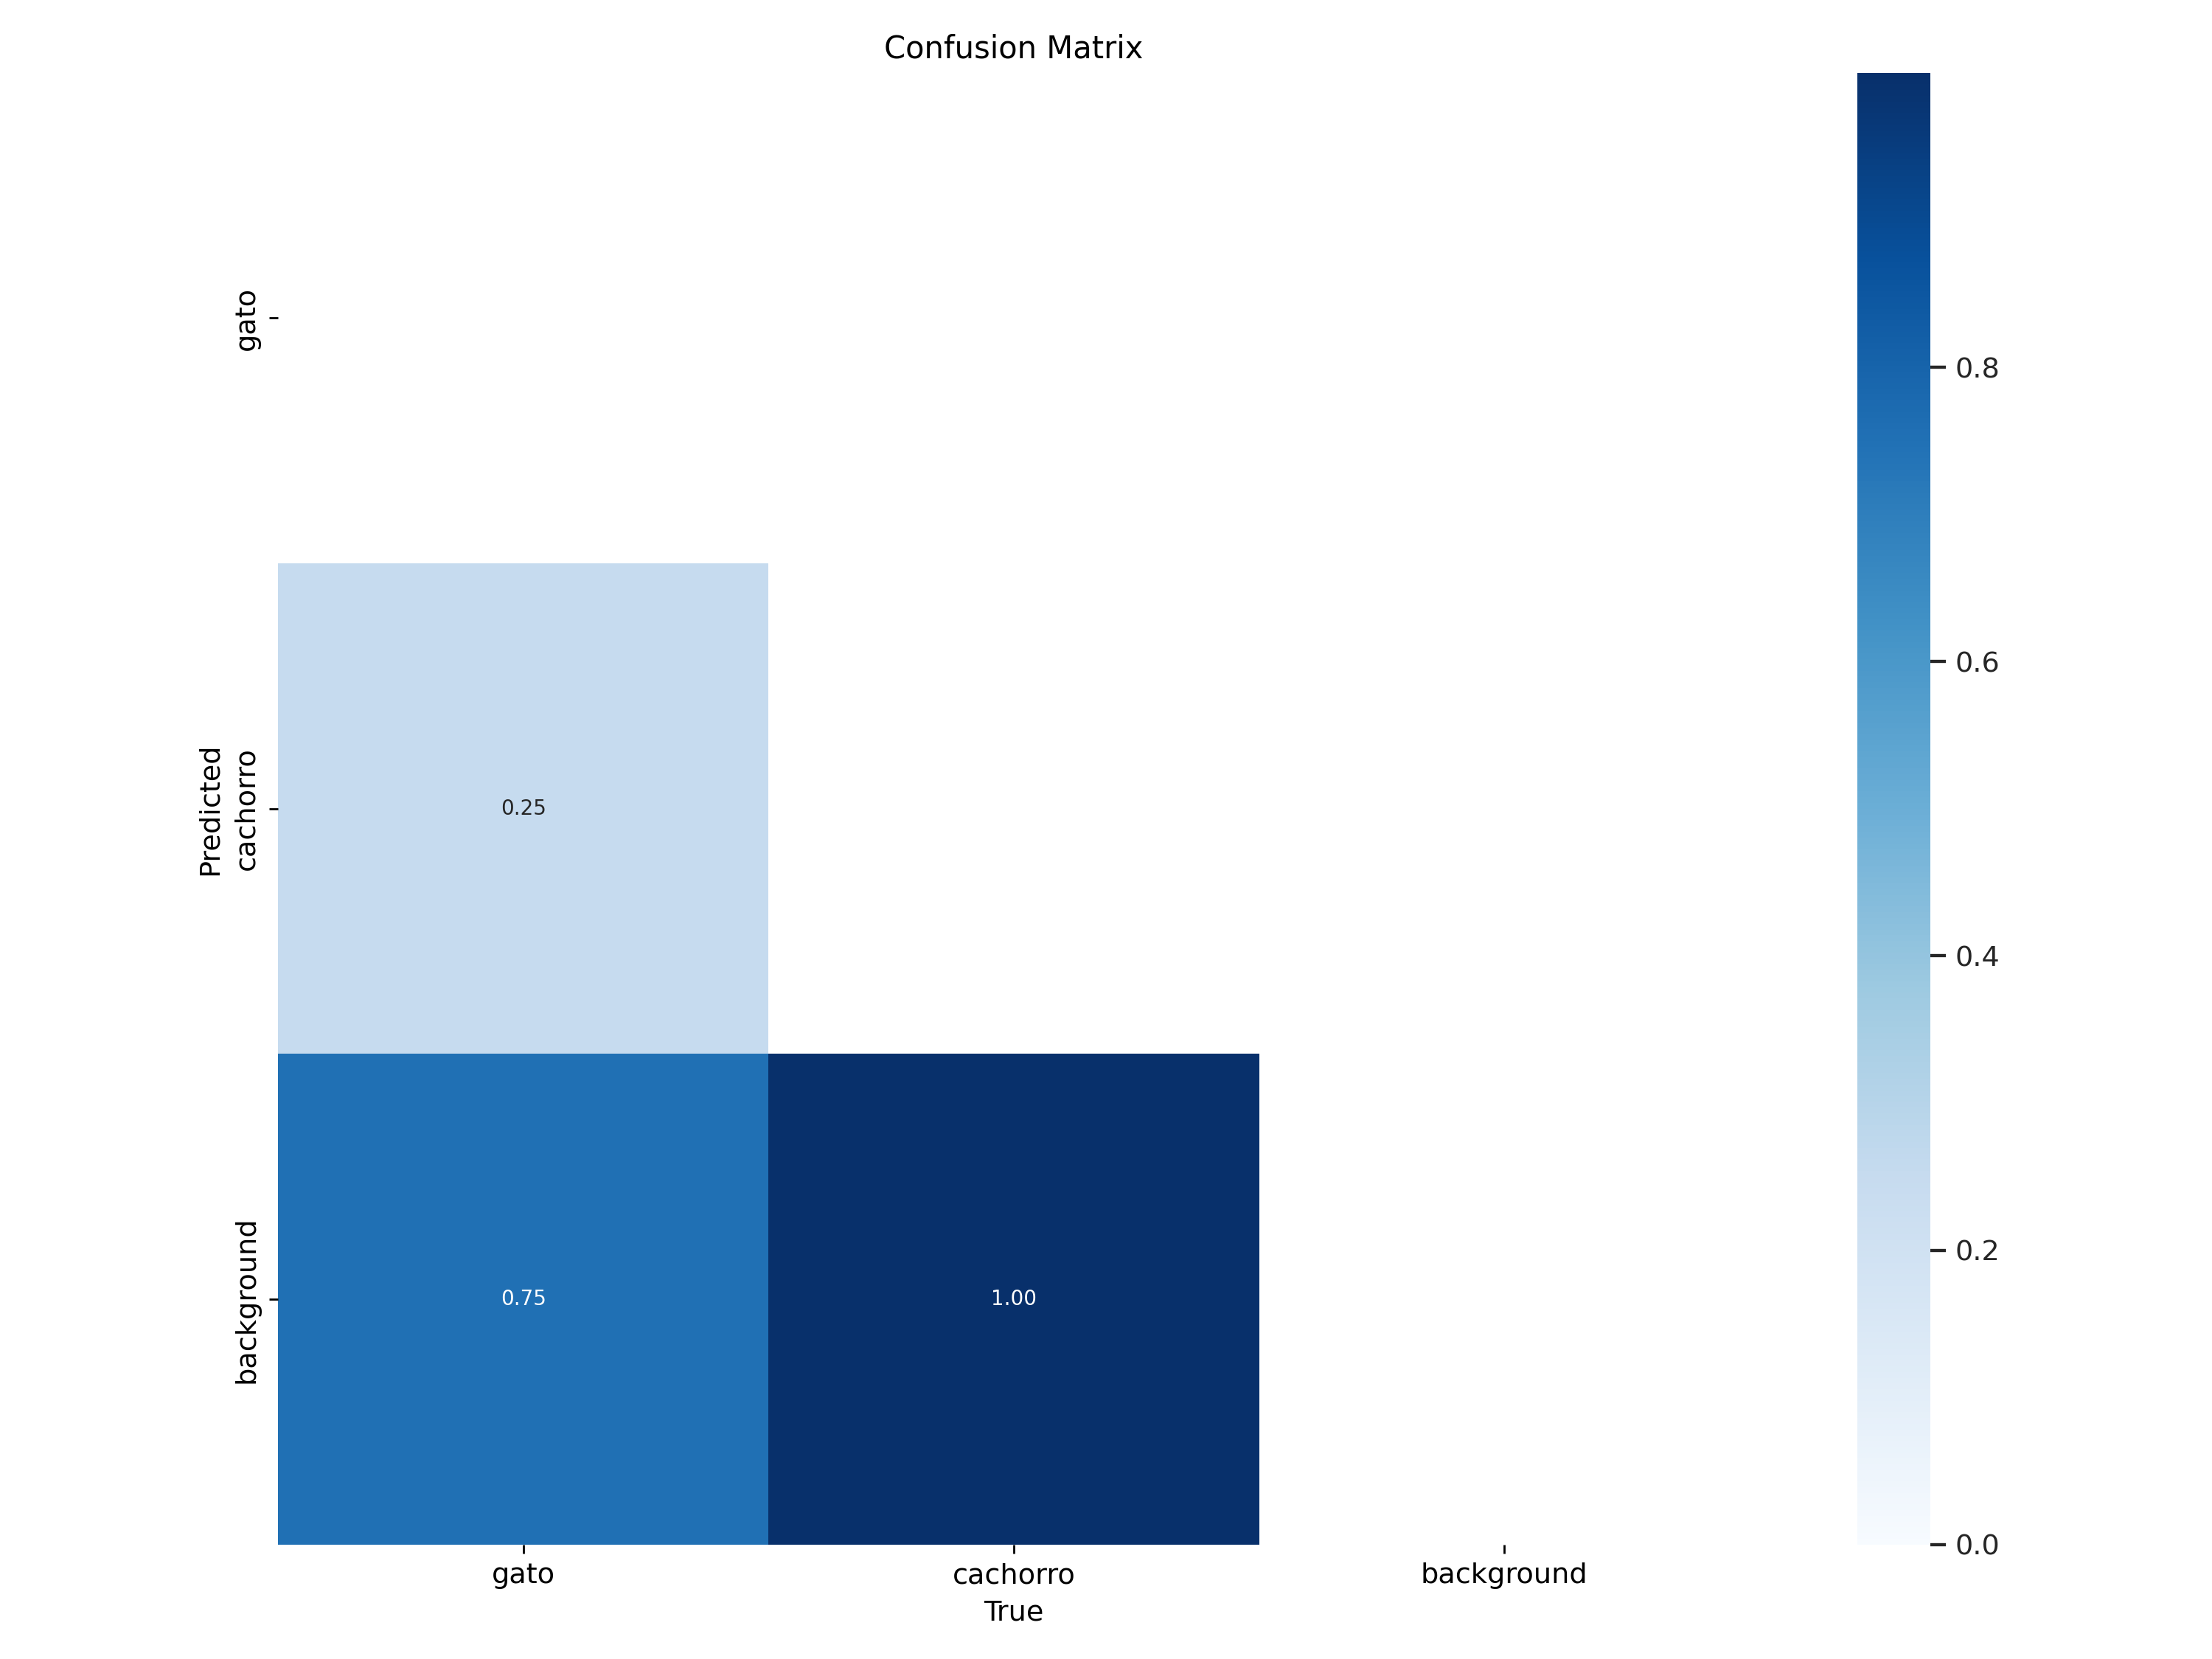


📊 Curva Precision x Recall


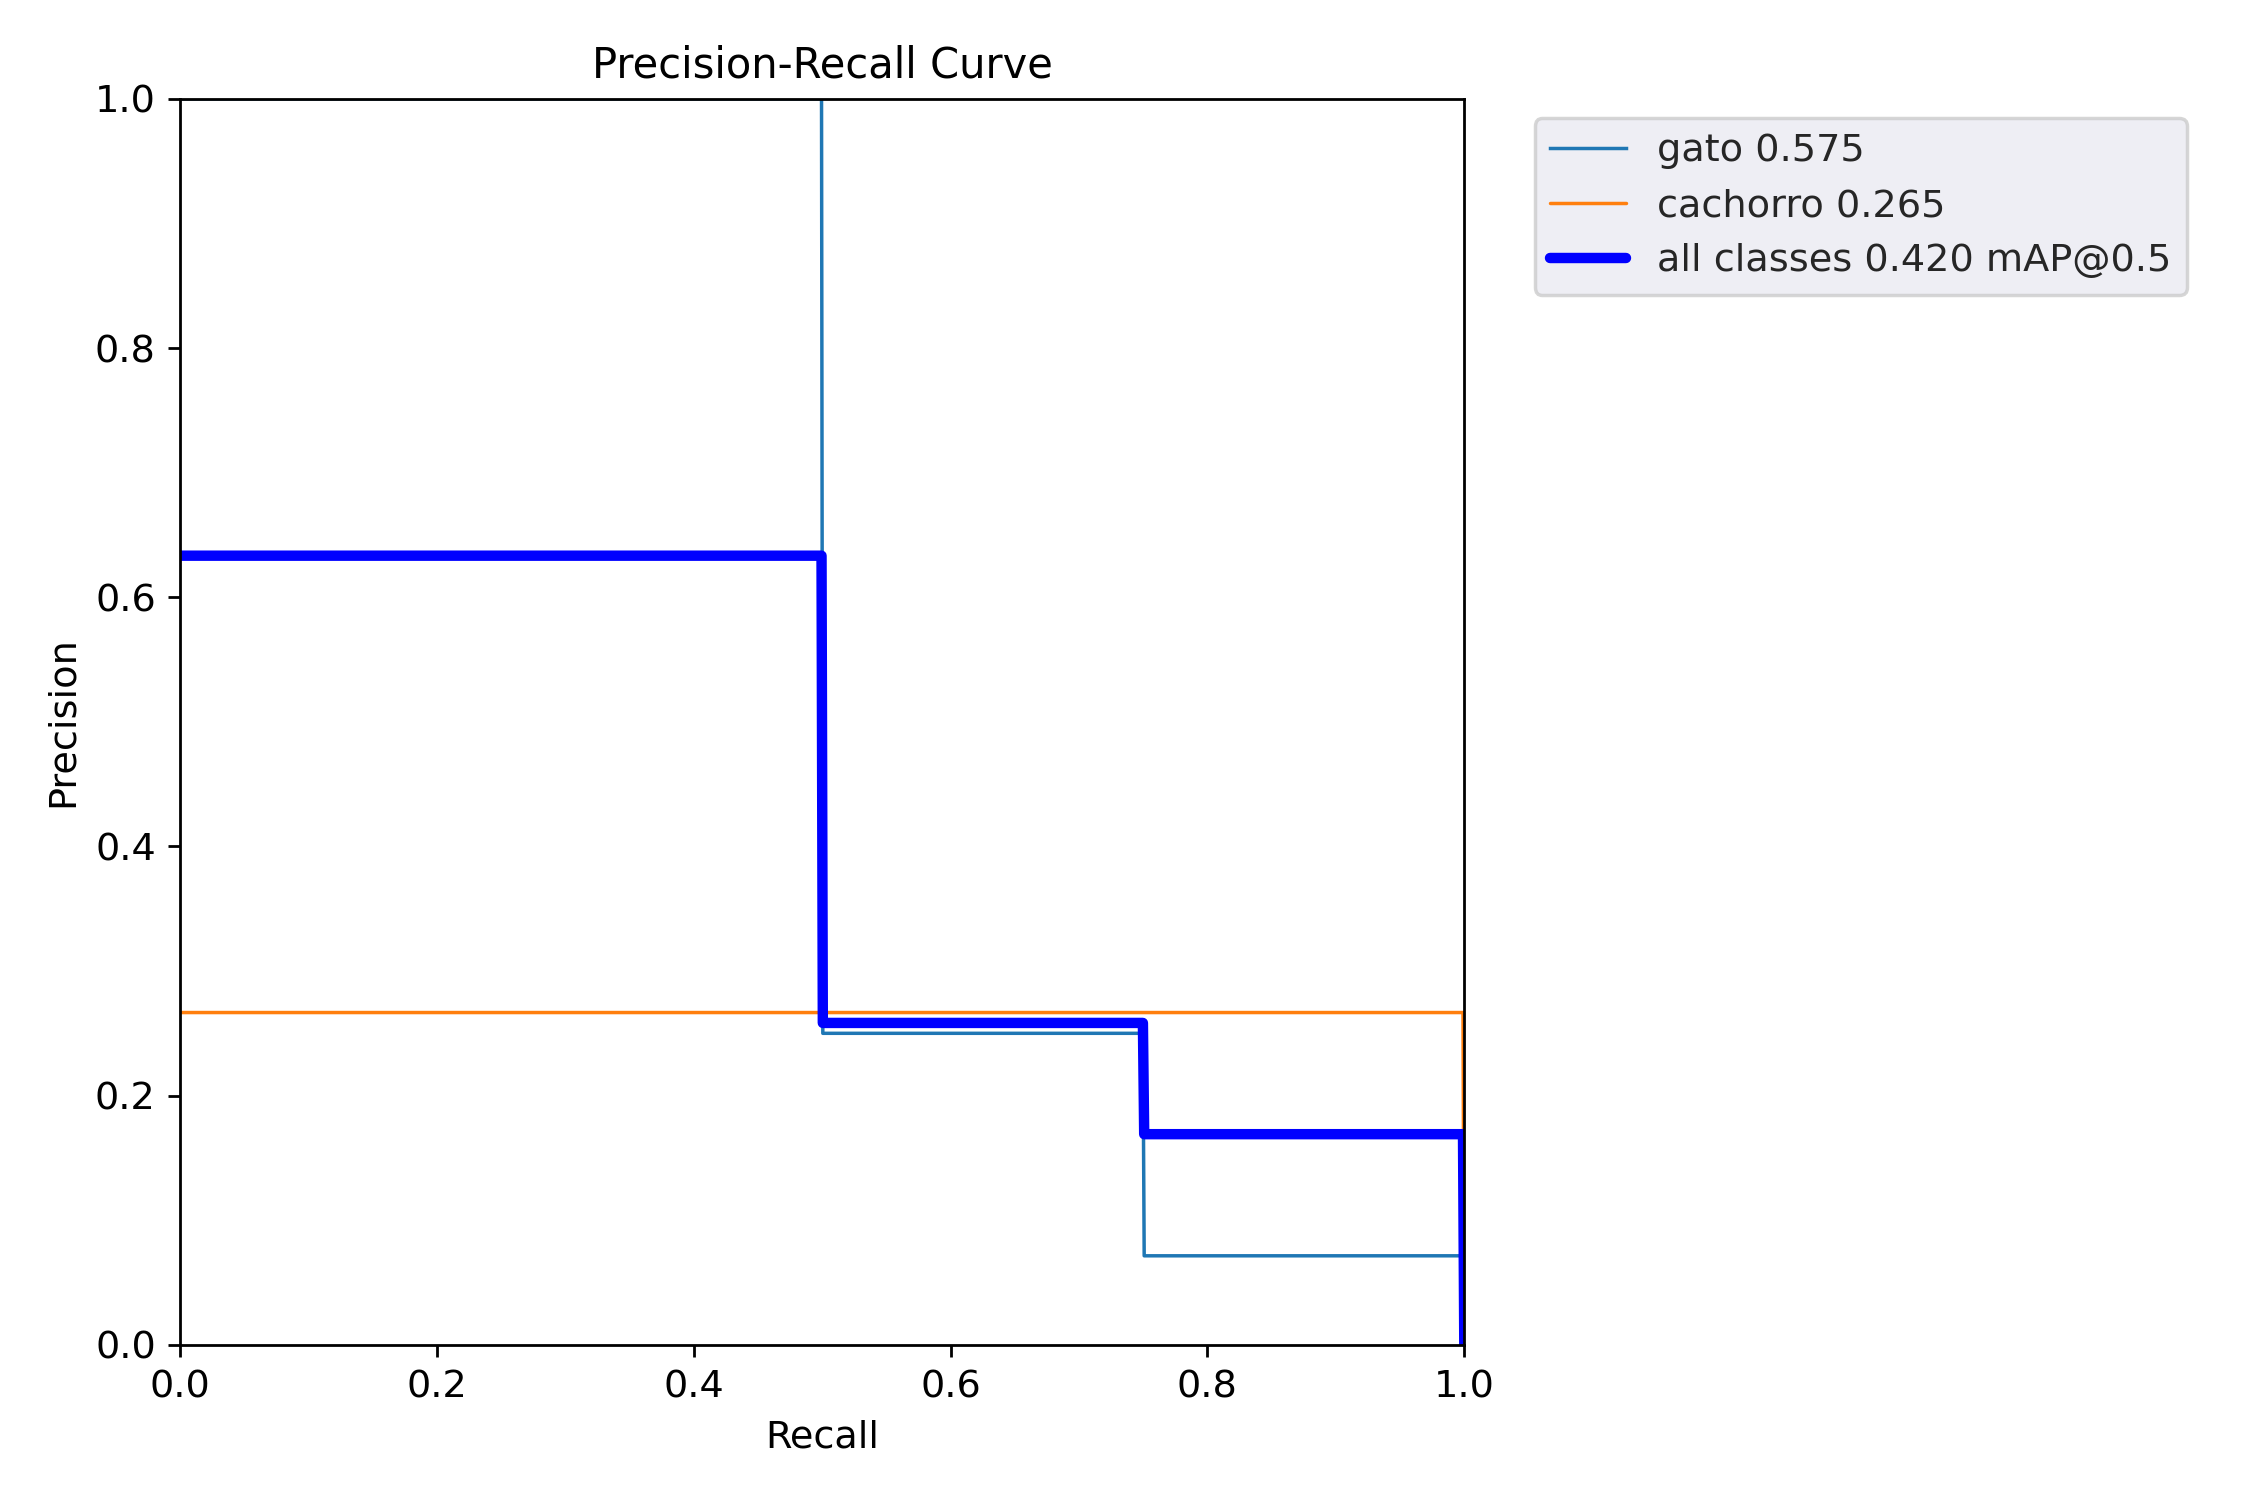


⚖️  Curva F1-Score por threshold


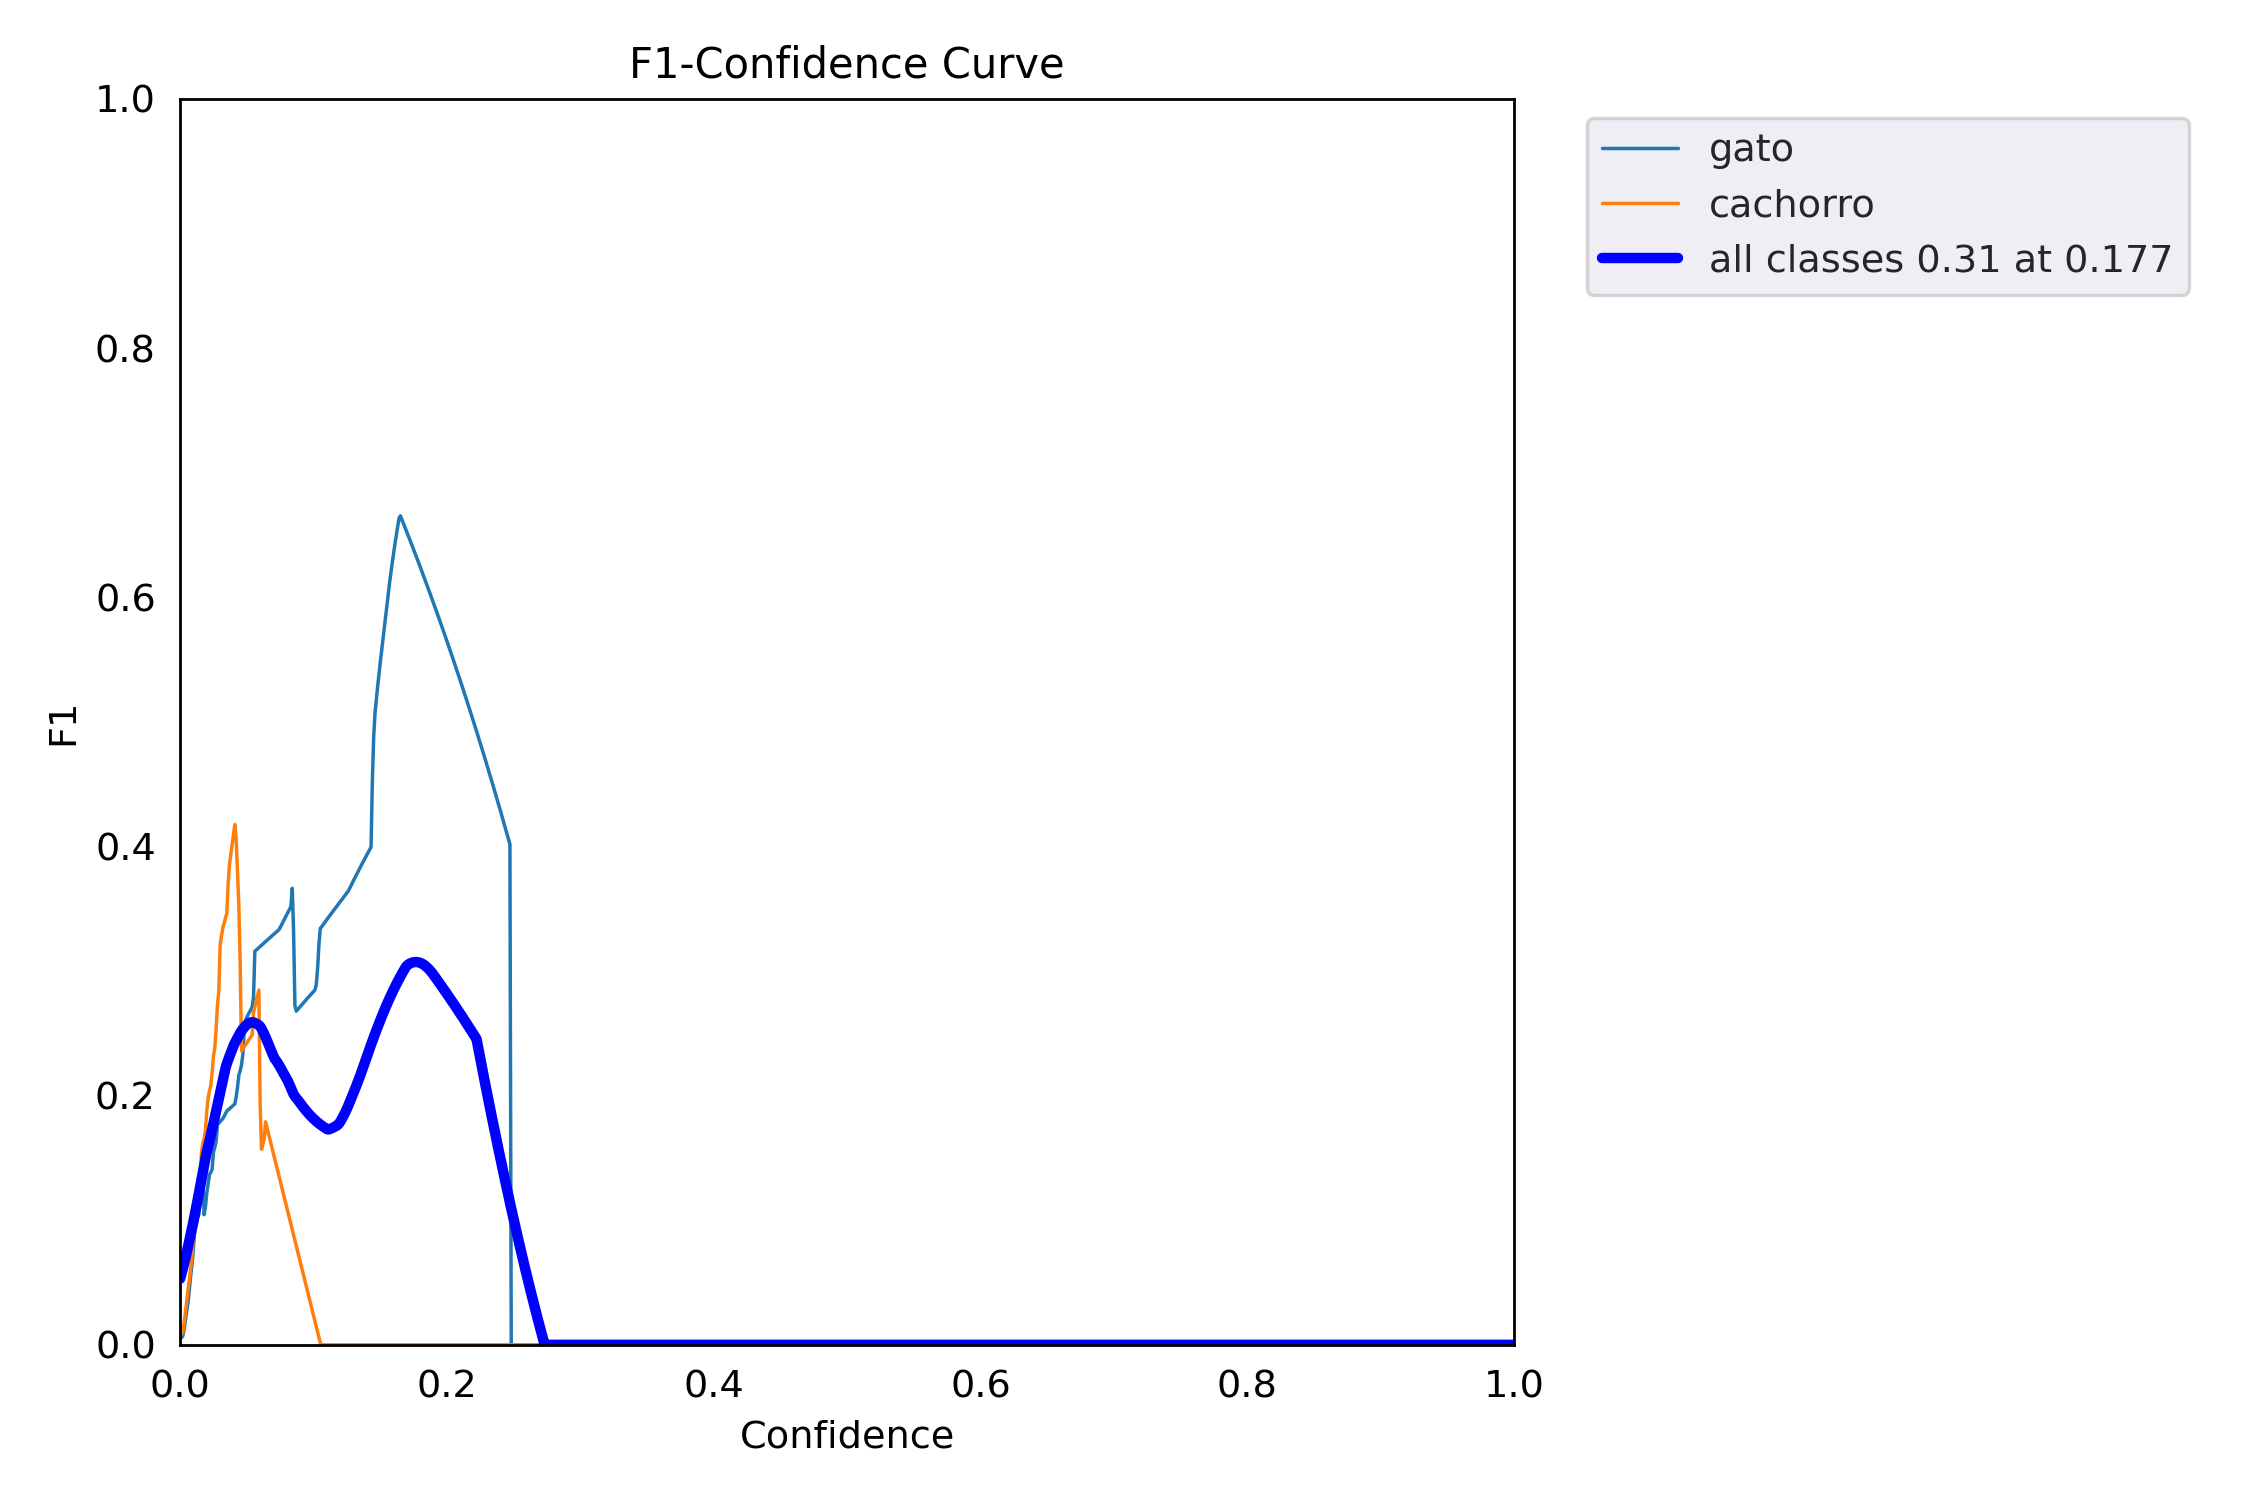


🏷️  Distribuição dos labels no dataset de treino


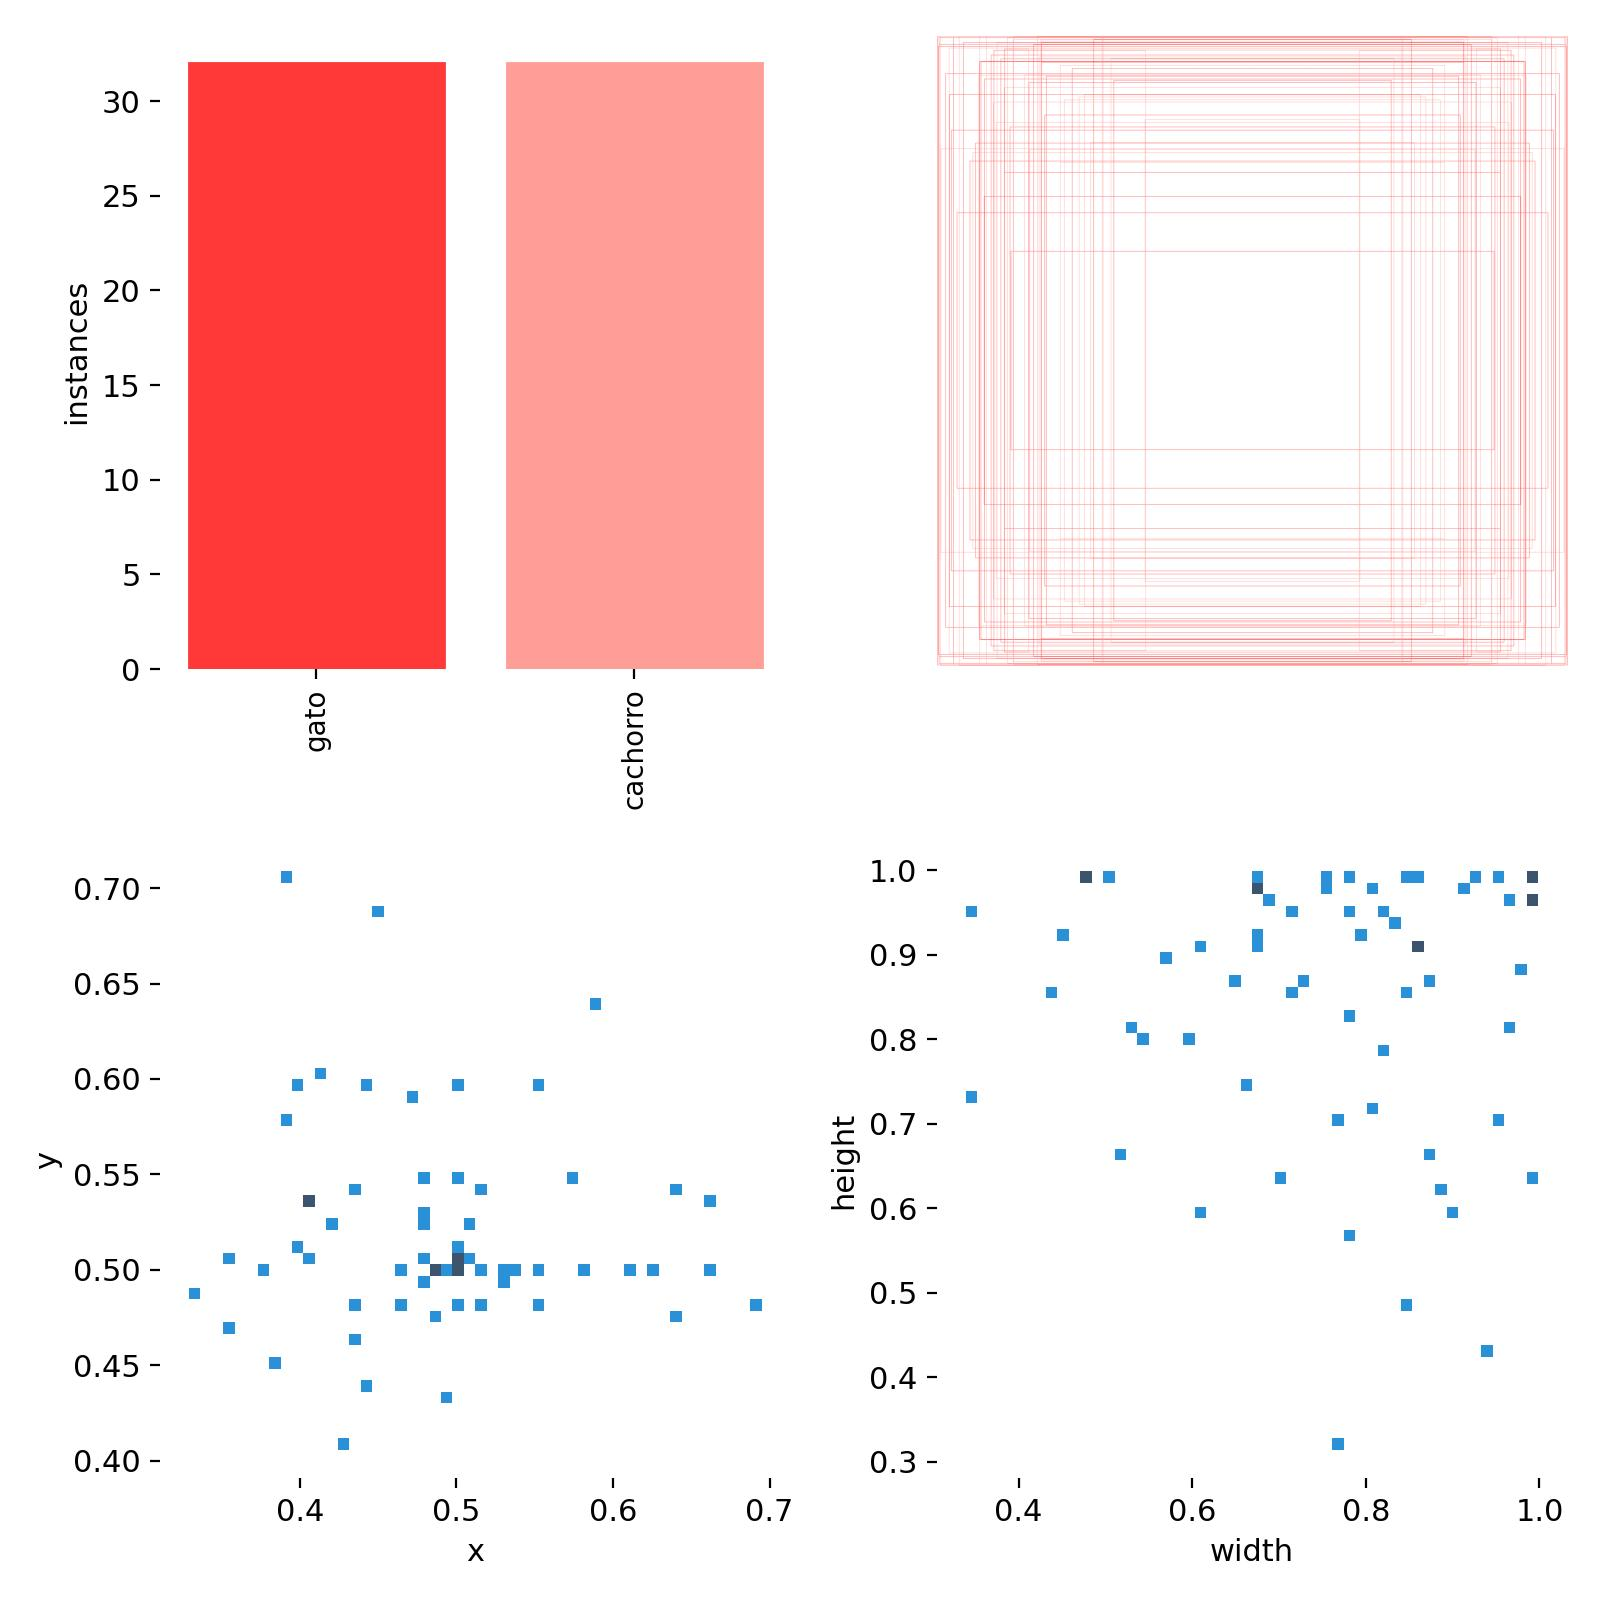


✅ Validação — Ground truth (rótulos verdadeiros)


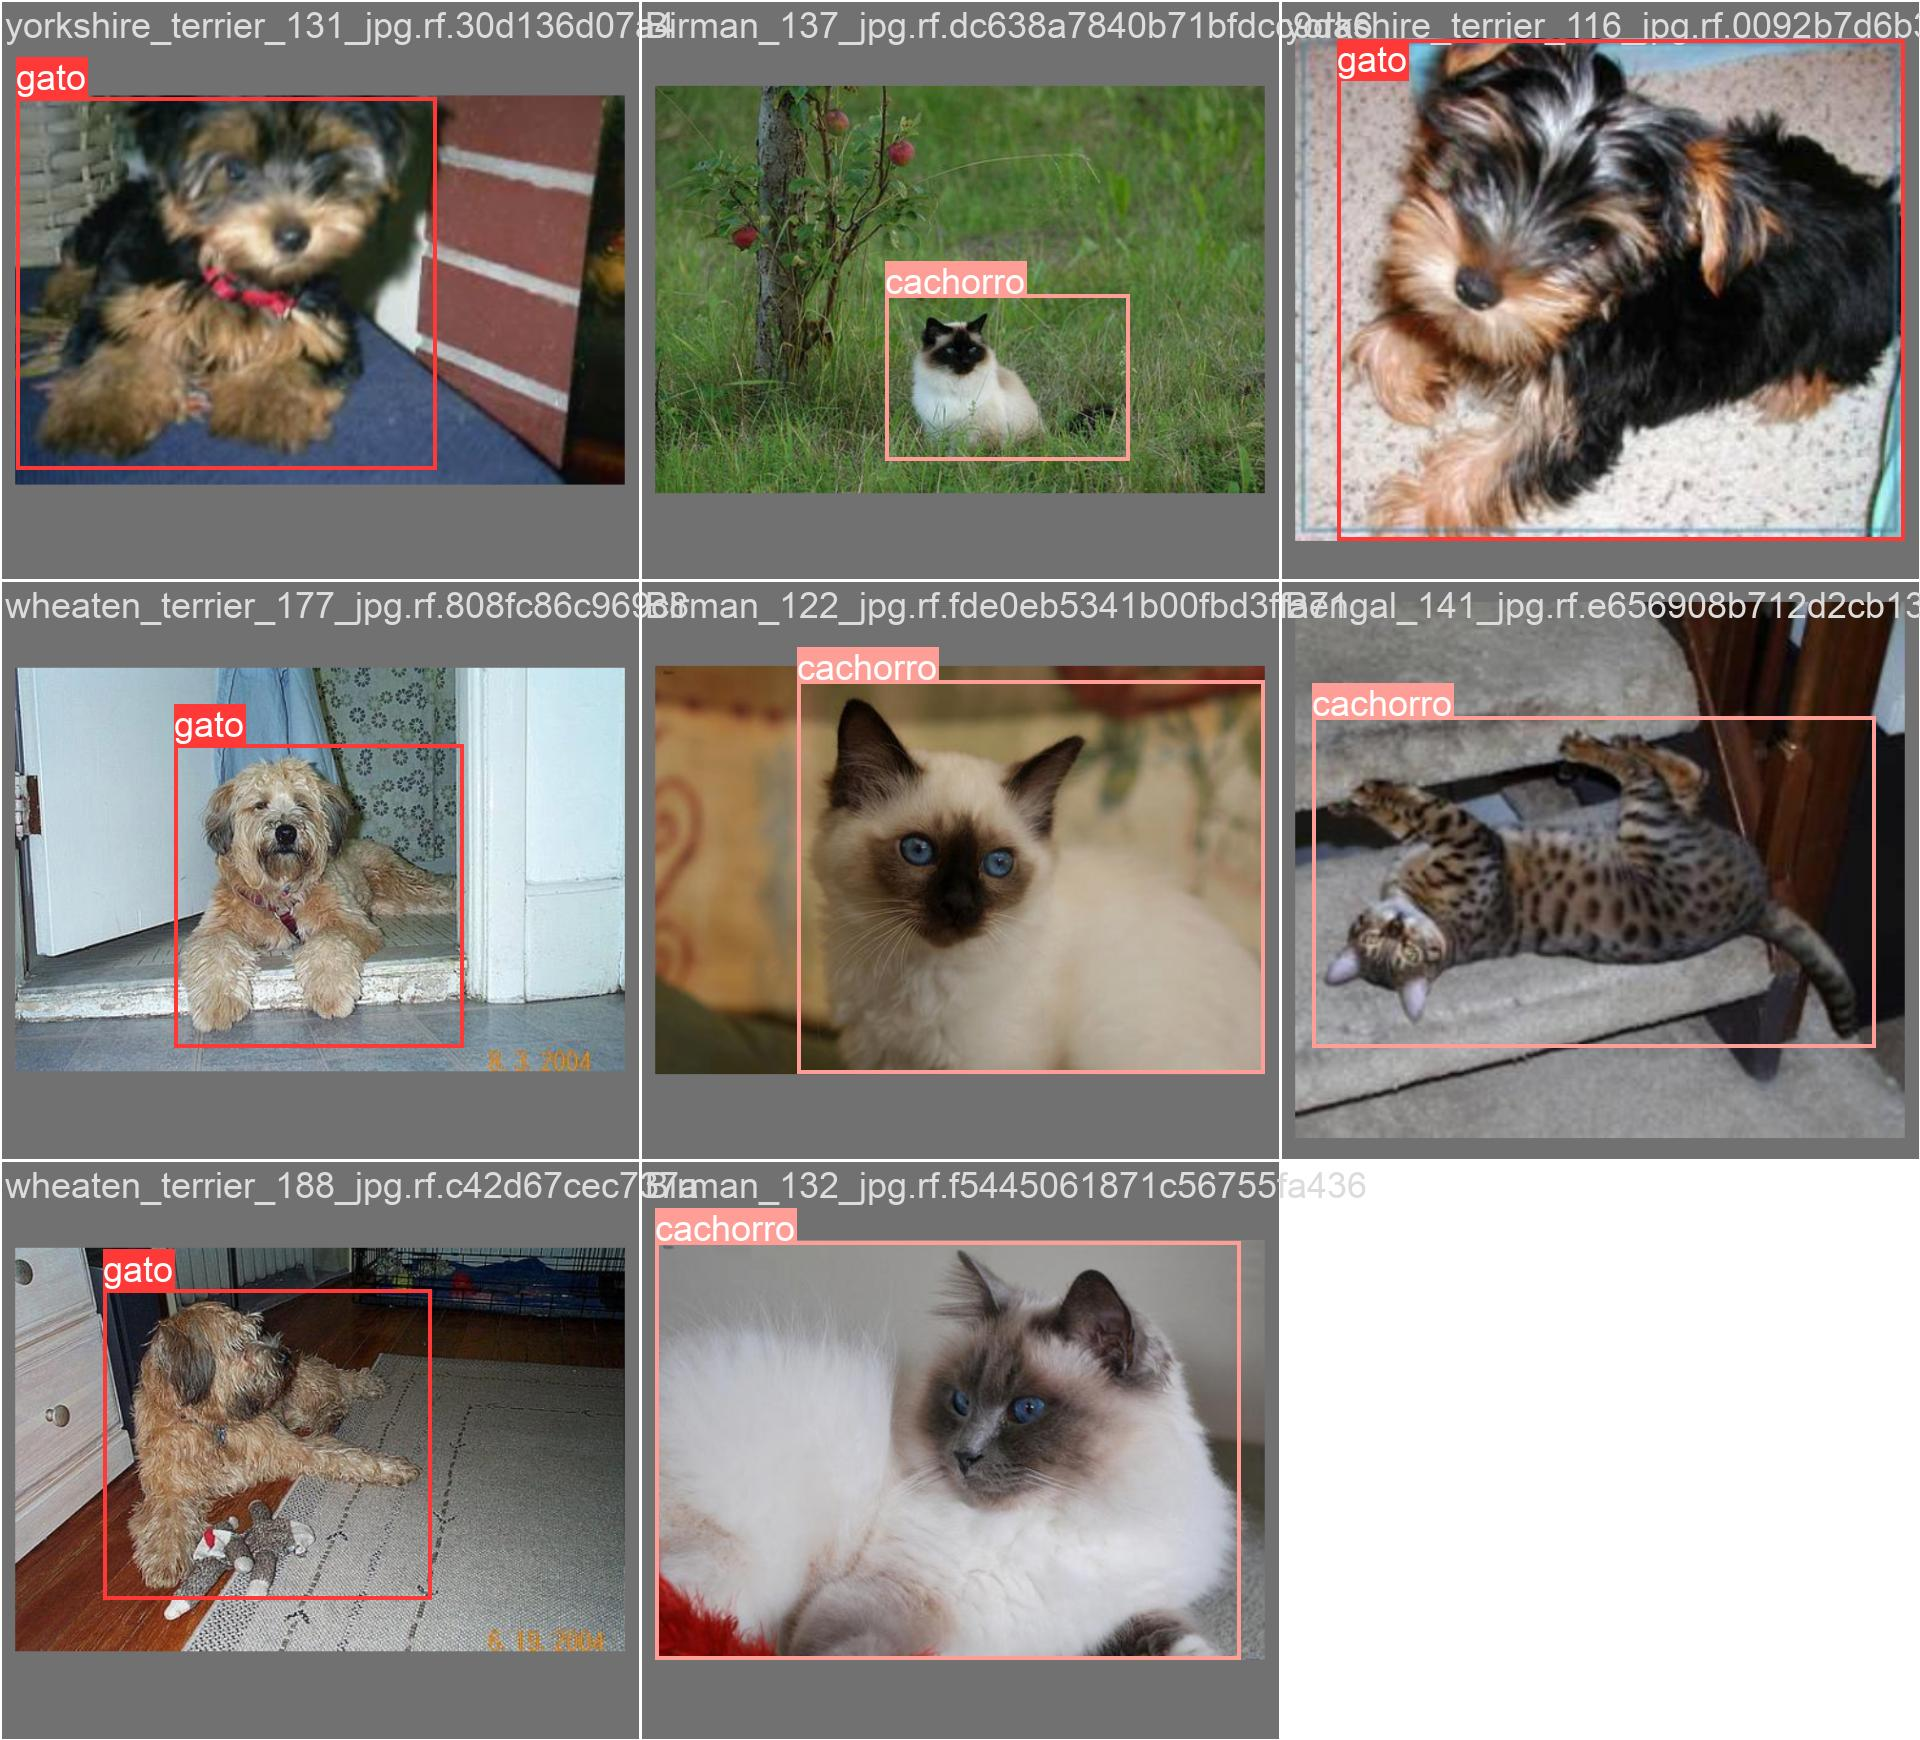


🔍 Validação — Predições do modelo


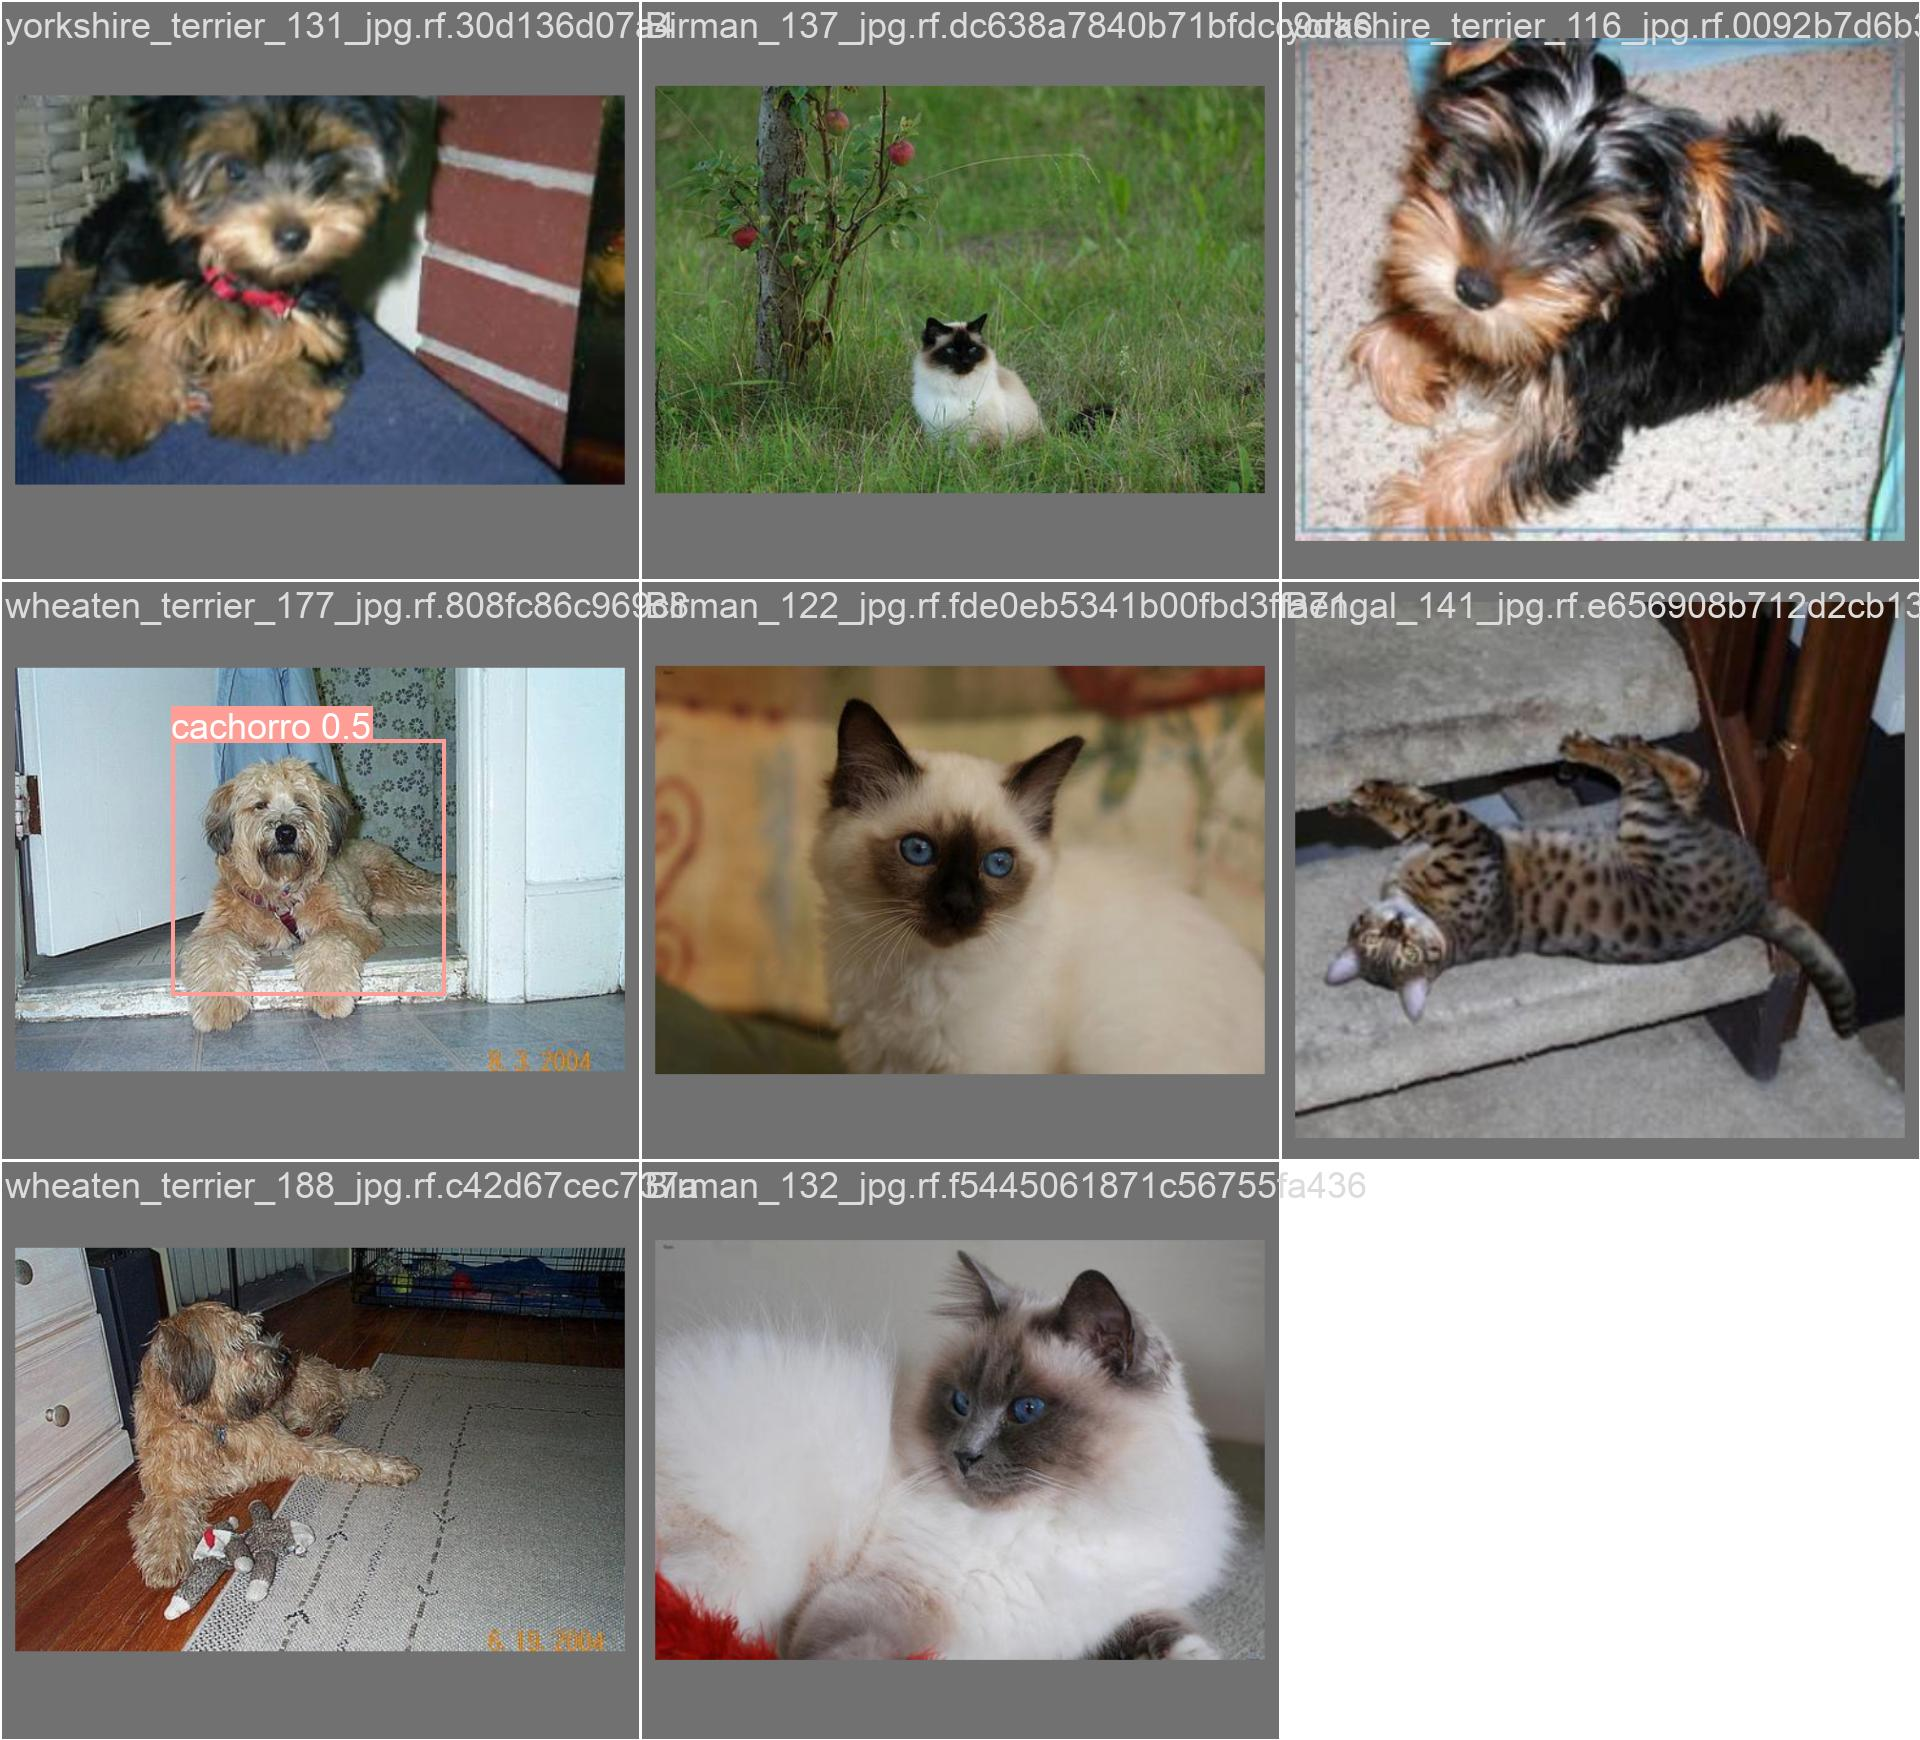

In [ ]:
# Exibe os principais gráficos gerados pelo YOLOv5 durante o treino
from IPython.display import Image, display

EXP_PATH = '/content/yolov5/runs/train/exp_30epochs2'

# Lista de gráficos para exibir, em ordem
graficos = [
    ('results.png',          '📈 Evolução das losses e métricas ao longo das épocas'),
    ('confusion_matrix.png', '🎯 Matriz de confusão (predições vs verdadeiro)'),
    ('PR_curve.png',         '📊 Curva Precision x Recall'),
    ('F1_curve.png',         '⚖️  Curva F1-Score por threshold'),
    ('labels.jpg',           '🏷️  Distribuição dos labels no dataset de treino'),
    ('val_batch0_labels.jpg','✅ Validação — Ground truth (rótulos verdadeiros)'),
    ('val_batch0_pred.jpg',  '🔍 Validação — Predições do modelo'),
]

import os
for arquivo, descricao in graficos:
    caminho = os.path.join(EXP_PATH, arquivo)
    if os.path.exists(caminho):
        print(f"\n{descricao}")
        display(Image(filename=caminho, width=800))
    else:
        print(f"\n⚠️ Arquivo não encontrado: {arquivo}")

## 5. Retreinamento com Dataset Corrigido

Analisando os dados, ficou claro que o problema principal que gerou os resultados ruins deveria estar relacionado com algum erro manual na criação dos rótulos e, de fato, analisando melhor ficou claro que sim: como a rotulagem foi feita no Make Sense em dois momentos diferentes, por um erro operacional, a rotulagem de validação foi feita na ordem inversa dos dados de treinamento e, apesar de os rótulos estarem corretos, terem sido realizado na ordem inversa gerou arquivos .txt com os rótulos errados o que gerou problemas para identificação das imagens.
Após a identificação e correção do problema de inversão de rótulos descrito na seção anterior, o modelo foi treinado novamente sob as mesmas condições do Experimento 1, para que seja possível atribuir qualquer mudança nos resultados exclusivamente à correção dos dados — e não a alterações de hiperparâmetros.

### Parâmetros mantidos idênticos ao Experimento 1

| Parâmetro | Valor |
|-----------|-------|
| Modelo base | yolov5s.pt (transfer learning) |
| Épocas | 30 |
| Batch size | 16 |
| Tamanho da imagem | 640x640 |
| Otimizador | SGD |
| Learning rate inicial | 0.01 |
| Dataset | 64 treino / 8 validação |

### O que mudou

- Os 8 arquivos `.txt` da pasta `labels/val/` foram regenerados no Make Sense AI com a ordem correta de classes (`gato` como índice 0, `cachorro` como índice 1).
- Os caches `train.cache` e `val.cache` foram apagados para forçar a releitura dos arquivos.
- O experimento foi salvo na pasta `runs/train/exp_30epochs_corrigido/` para preservar os artefatos do experimento original e permitir comparação direta.

A seguir, executamos o treinamento novamente.

In [ ]:
# Retreino com 30 épocas após correção dos labels de validação
%cd /content/yolov5

!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 30 \
  --data /content/yolov5/data/petshop.yaml \
  --weights yolov5s.pt \
  --name exp_30epochs_corrigido \
  --project runs/train

/content/yolov5
2026-04-27 14:53:35.227570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777301615.253135   18615 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777301615.260455   18615 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777301615.280676   18615 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777301615.280761   18615 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777301615.280765   18615 computation_placer.cc:177] comput

## 5.1: Relatório final da Etapa - Identificação e correção de problema nos labels

Ao analisar os resultados do Experimento 1, observamos métricas anômalas:

- A classe **cachorro** apresentou Precision = 0 e Recall = 0
- A classe **gato** teve Precision = 1.0 mas Recall baixo (0.41)
- O `mAP@0.5` geral ficou em apenas 0.42

Resultados tão discrepantes entre classes em um dataset balanceado (32+32 imagens
de treino, 4+4 de validação) indicaram a possibilidade de um problema sistemático,
e não apenas limitação do modelo.

### Hipótese levantada

Examinamos manualmente alguns arquivos `.txt` de rotulação:

| Arquivo | Animal real | Índice no .txt | Esperado |
|---------|-------------|----------------|----------|
| `Abyssinian_15.txt` (treino) | Gato | 0 | 0 ✅ |
| `american_bulldog_126.txt` (treino) | Cachorro | 1 | 1 ✅ |
| `Bengal_141.txt` (val) | Gato | **1** ❌ | 0 |
| `yorkshire_terrier.txt` (val) | Cachorro | **0** ❌ | 1 |

**Conclusão:** os labels da validação estavam com a ordem das classes invertida
em relação aos labels do treino.

### Causa raiz

O Make Sense AI define o índice numérico das classes pela **ordem em que os labels
são criados** na interface:

- 1º label criado → índice 0
- 2º label criado → índice 1

Como a rotulação foi feita em duas sessões separadas (treino e validação) e o
Make Sense não persiste configurações entre sessões, na sessão de validação a
ordem foi invertida sem que isso fosse percebido. O modelo, então, era treinado
com `gato=0, cachorro=1` mas avaliado contra rótulos onde `gato=1, cachorro=0`.

### Correção aplicada

Foi feita nova rotulação das 8 imagens de validação no Make Sense, desta vez
respeitando a ordem `gato` (1º) e `cachorro` (2º) — idêntica à do treino.
Os caches `train.cache` e `val.cache` do YOLOv5 foram apagados para forçar a
releitura dos arquivos de label corrigidos.

### Impacto da correção

| Métrica | Antes (labels invertidos) | Depois (corrigidos) |
|---------|---------------------------|---------------------|
| Precision (all) | 0.500 | **0.752** |
| Recall (all) | 0.206 | **0.741** |
| mAP@0.5 (all) | 0.420 | **0.901** |
| mAP@0.5:0.95 (all) | 0.253 | **0.511** |
| Cachorro — Precision | 0.000 | **1.000** |
| Cachorro — mAP@0.5 | 0.265 | **0.995** |

### Lições aprendidas

1. **Métricas anômalas merecem investigação antes de retreinar** — aumentar épocas, mudar arquitetura ou alterar hiperparâmetros não resolveria este problema, que estava nos próprios dados.
2. **Consistência entre conjuntos de dados é crítica** — treino, validação e teste precisam usar exatamente a mesma convenção de rotulação.
3. **Ferramentas web sem persistência exigem cuidado redobrado** — em sessões separadas, sempre conferir a ordem dos labels antes de iniciar a rotulação.
4. **Caches podem mascarar correções** — após editar labels, sempre limpar caches do YOLO antes de retreinar.


📈 Evolução das losses e métricas ao longo das épocas


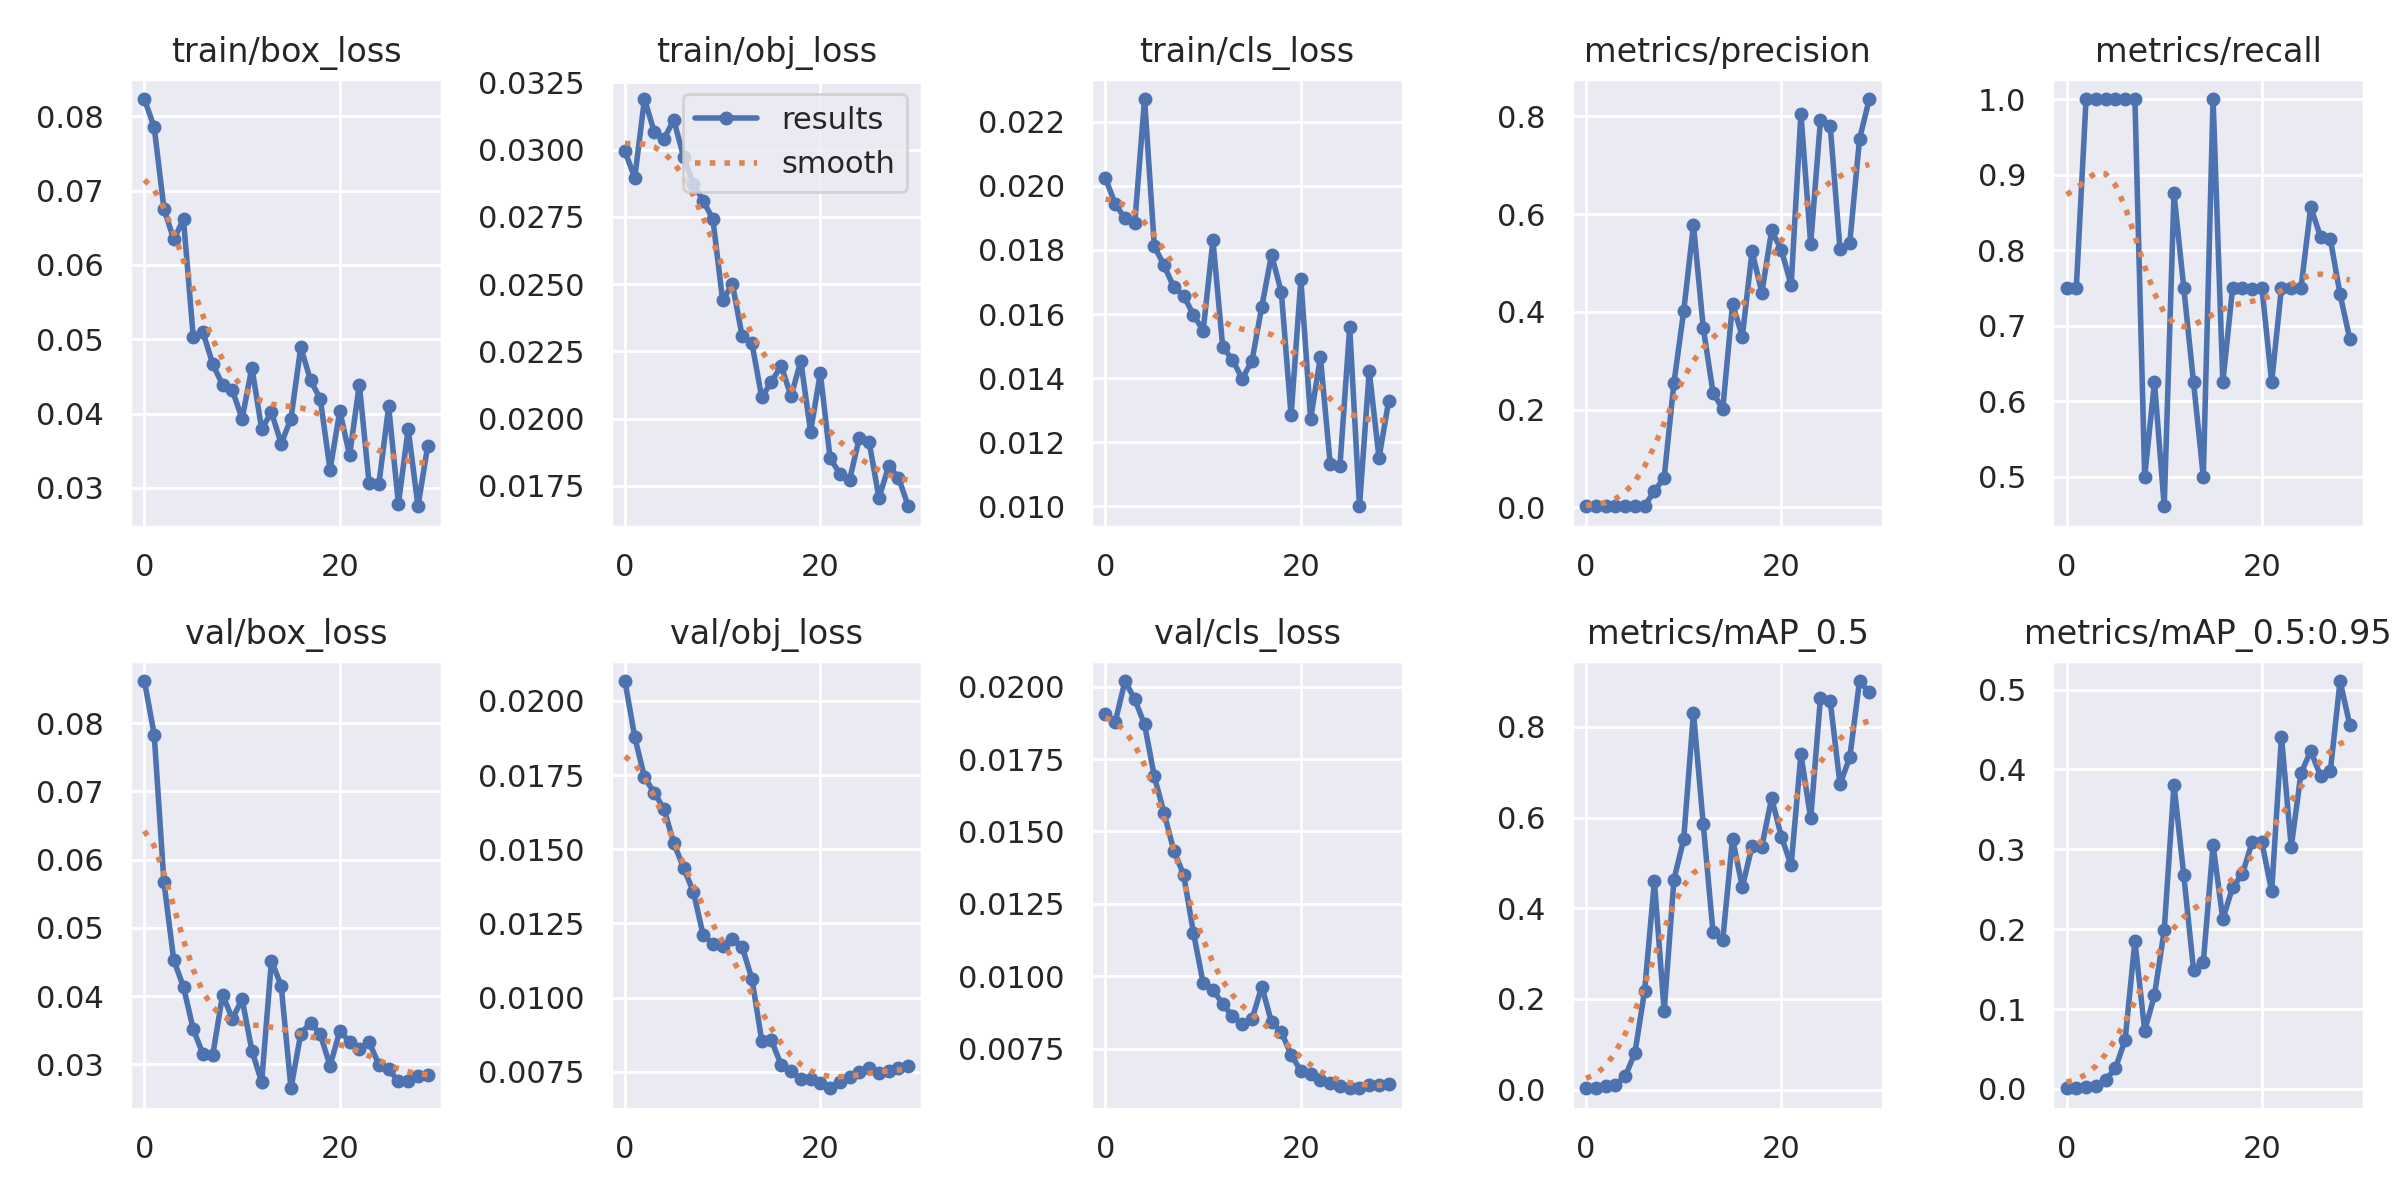


🎯 Matriz de confusão (predições vs verdadeiro)


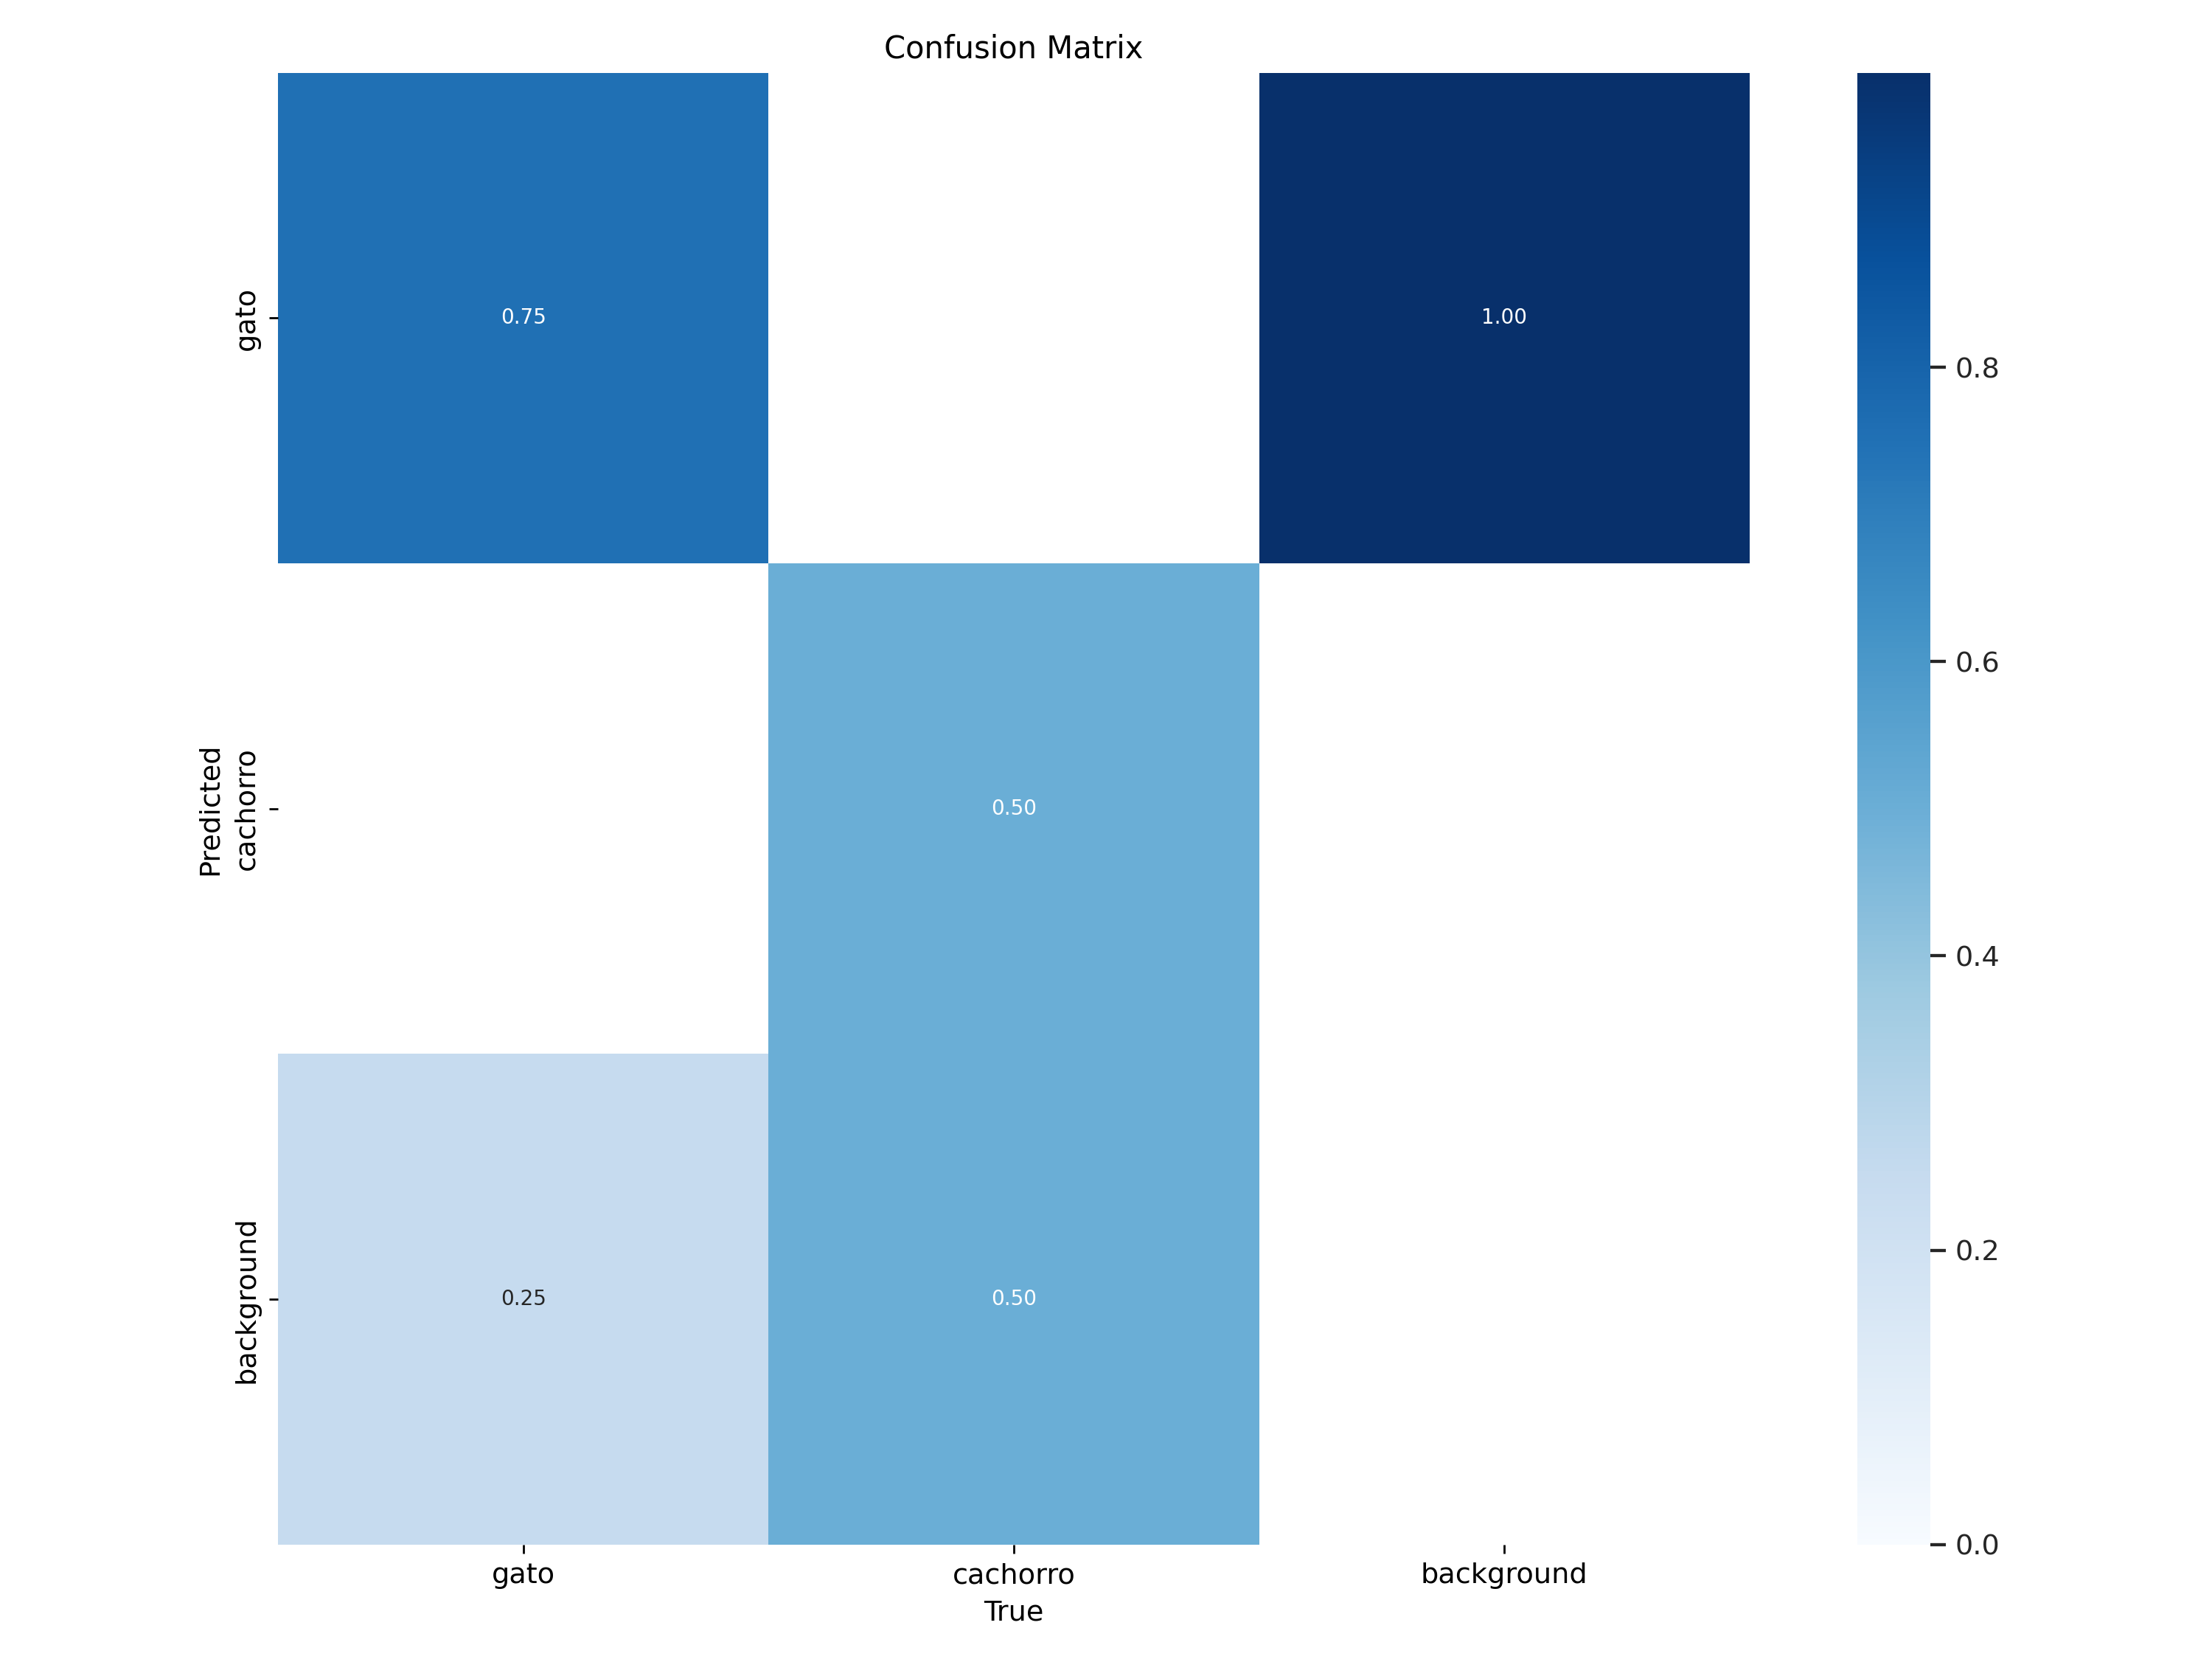


📊 Curva Precision x Recall


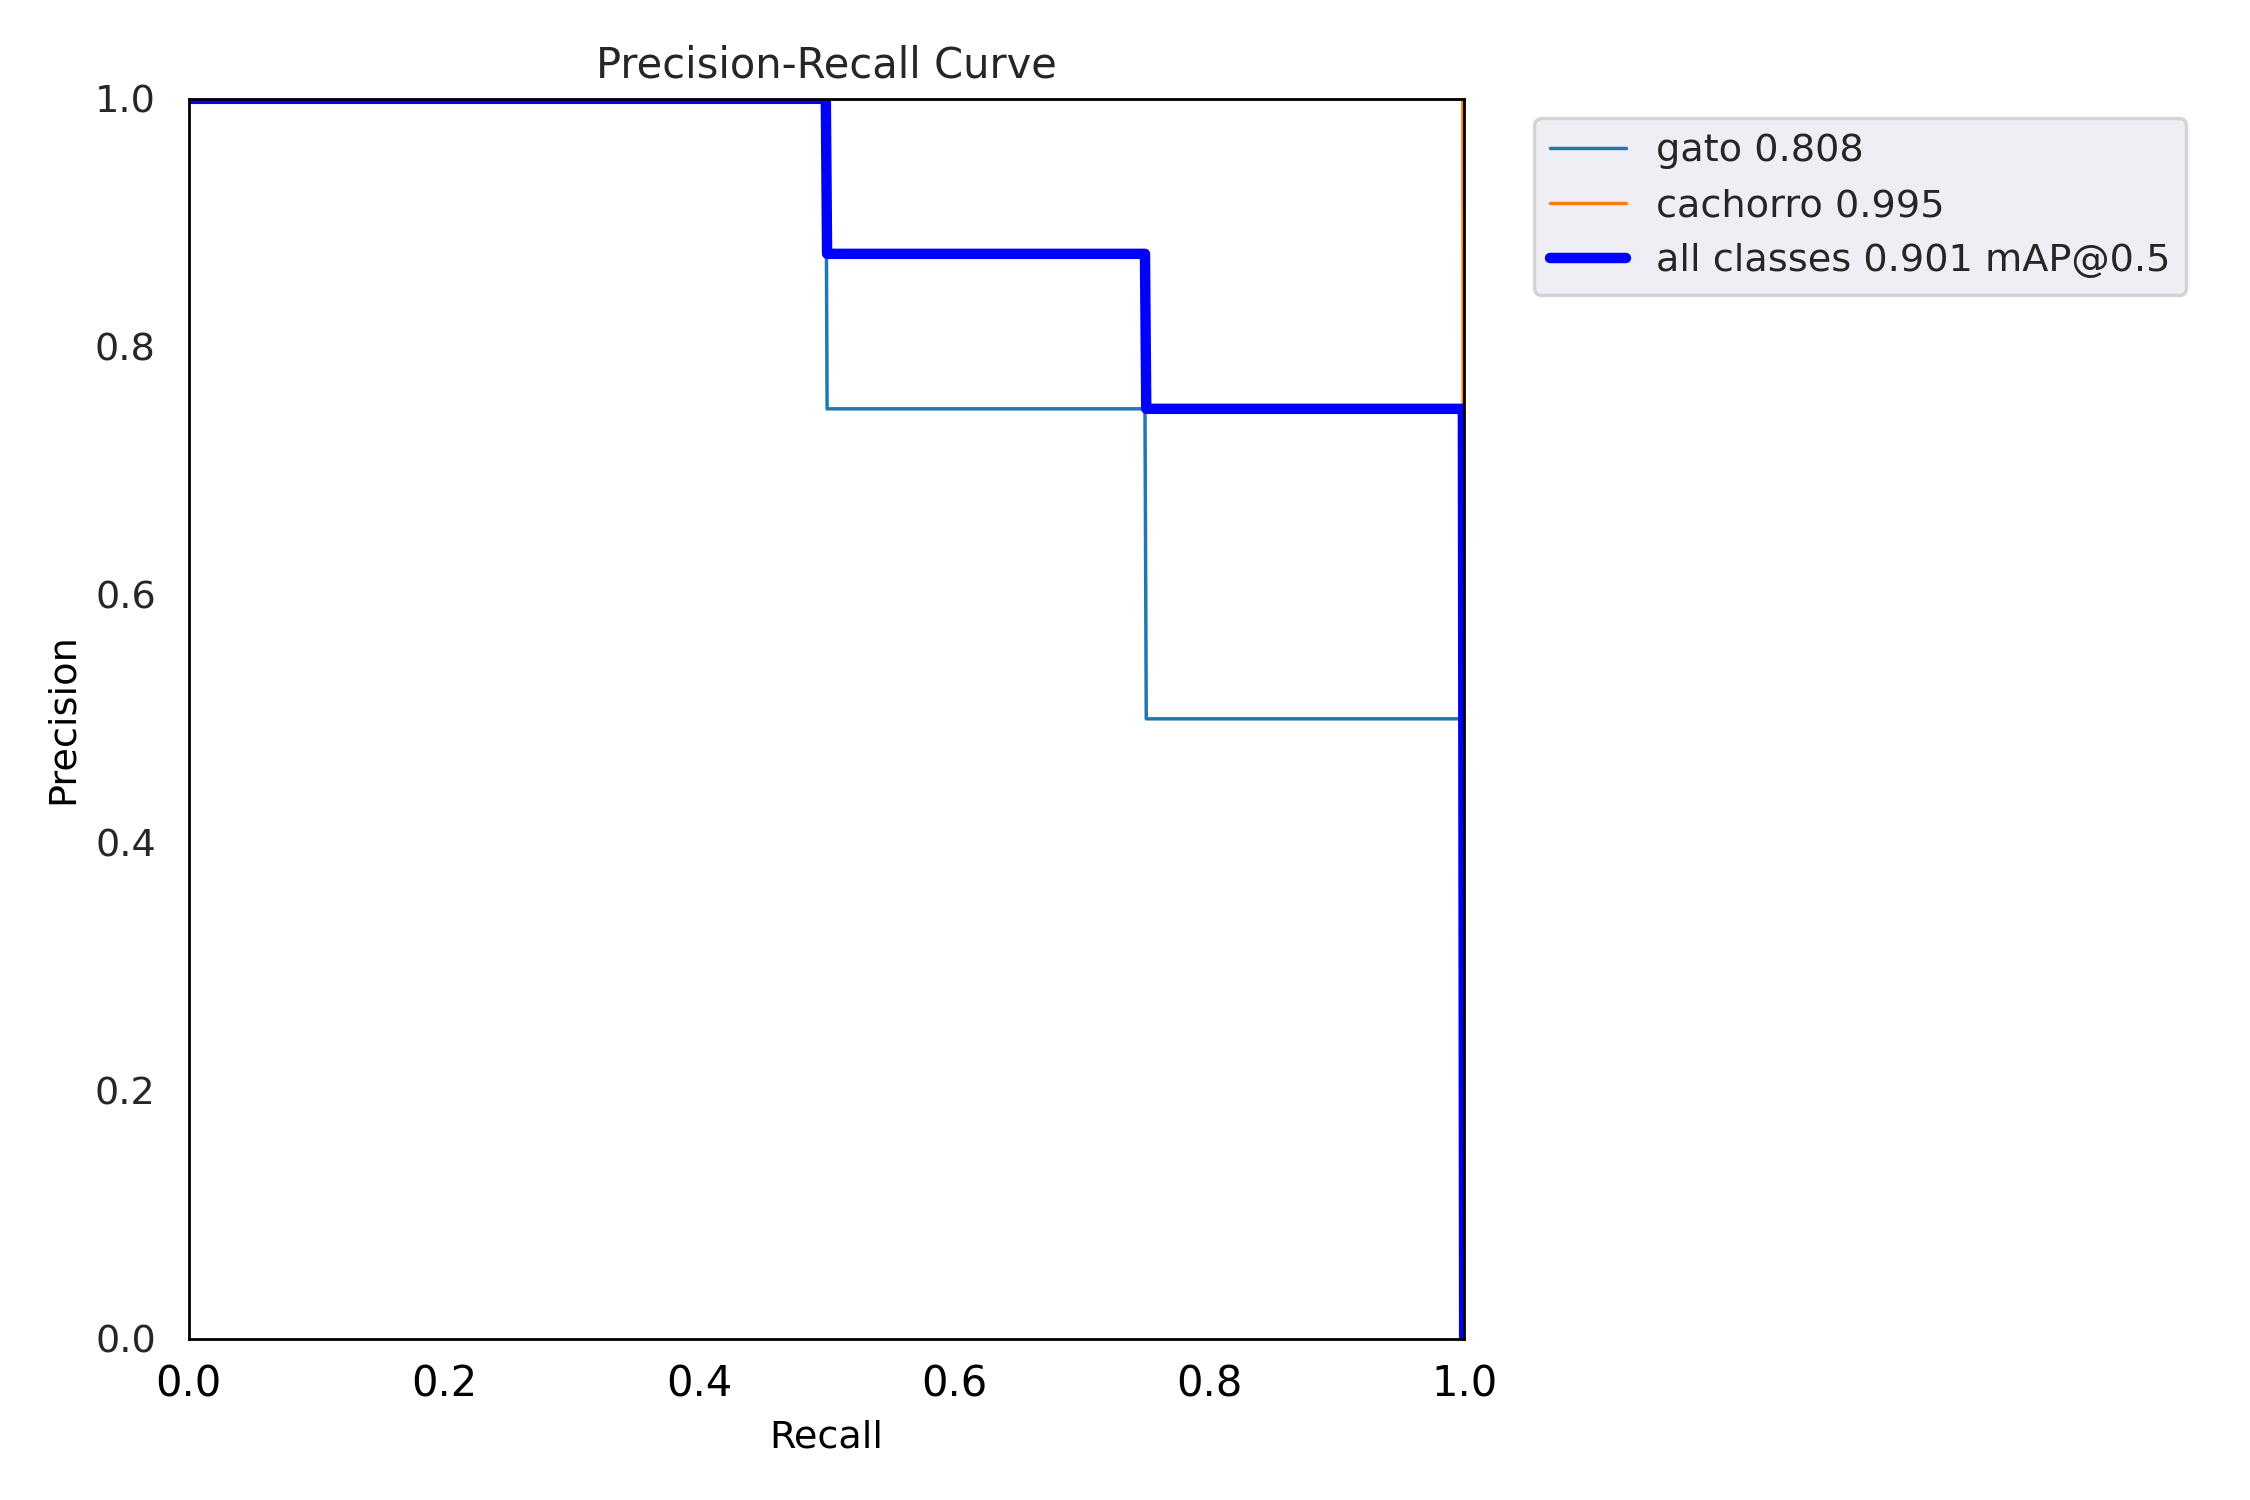


⚖️  Curva F1-Score por threshold


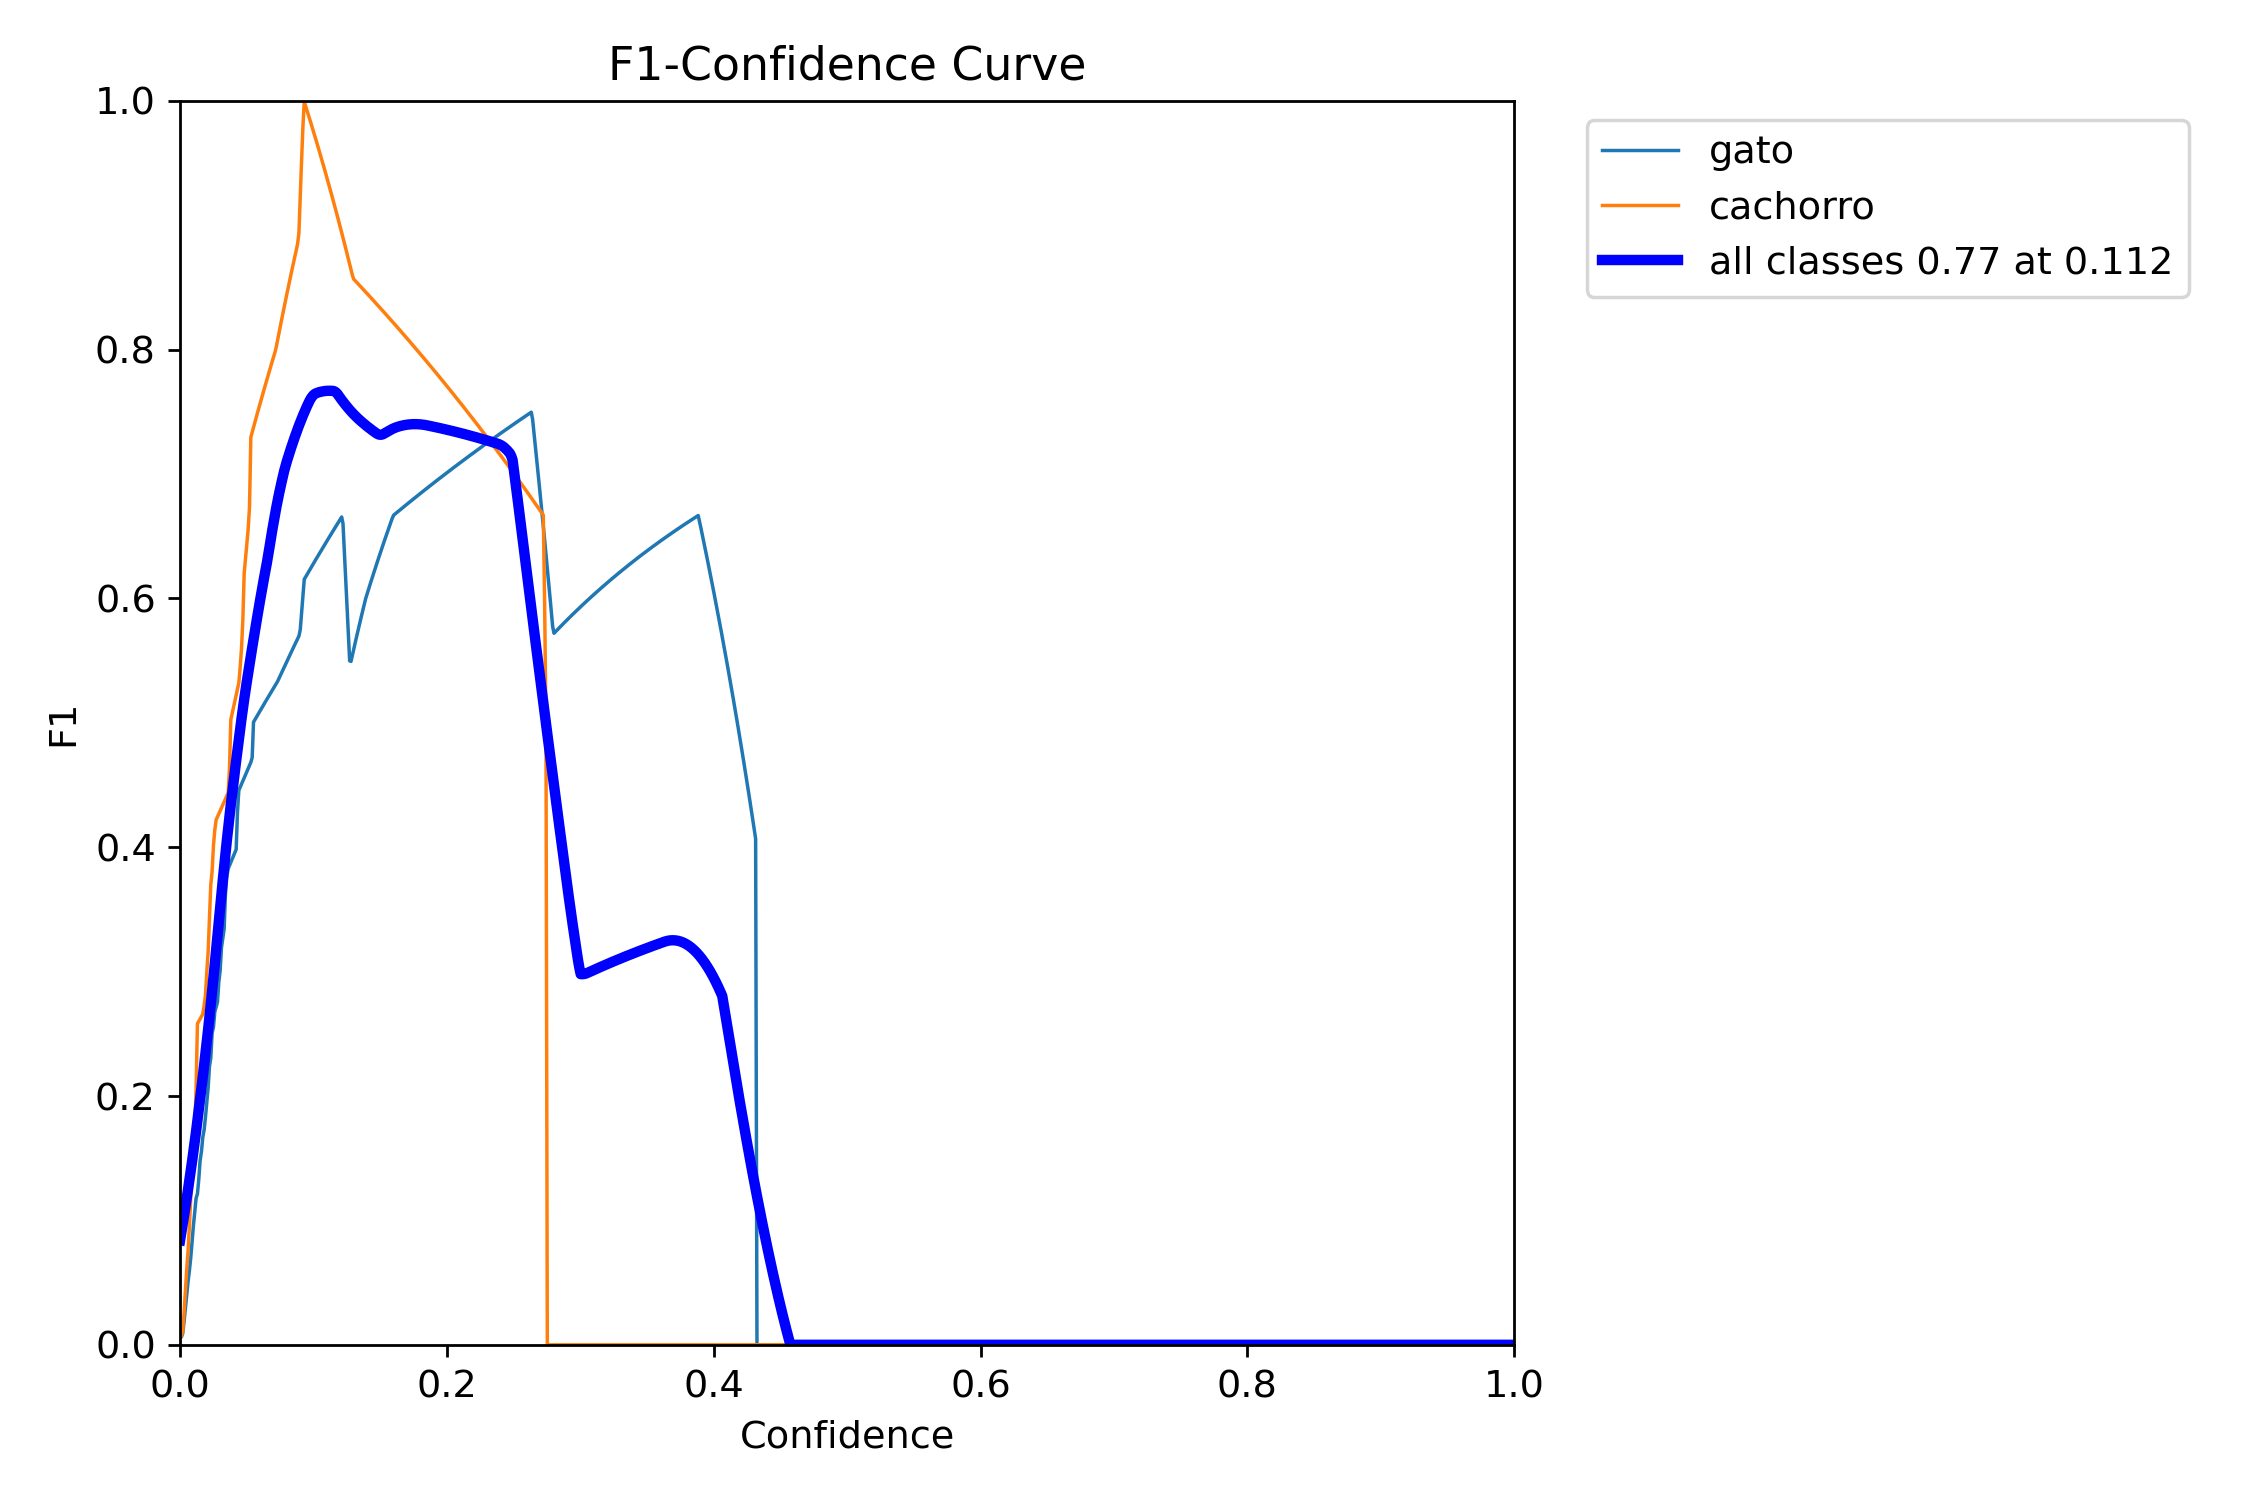


🏷️  Distribuição dos labels no dataset de treino


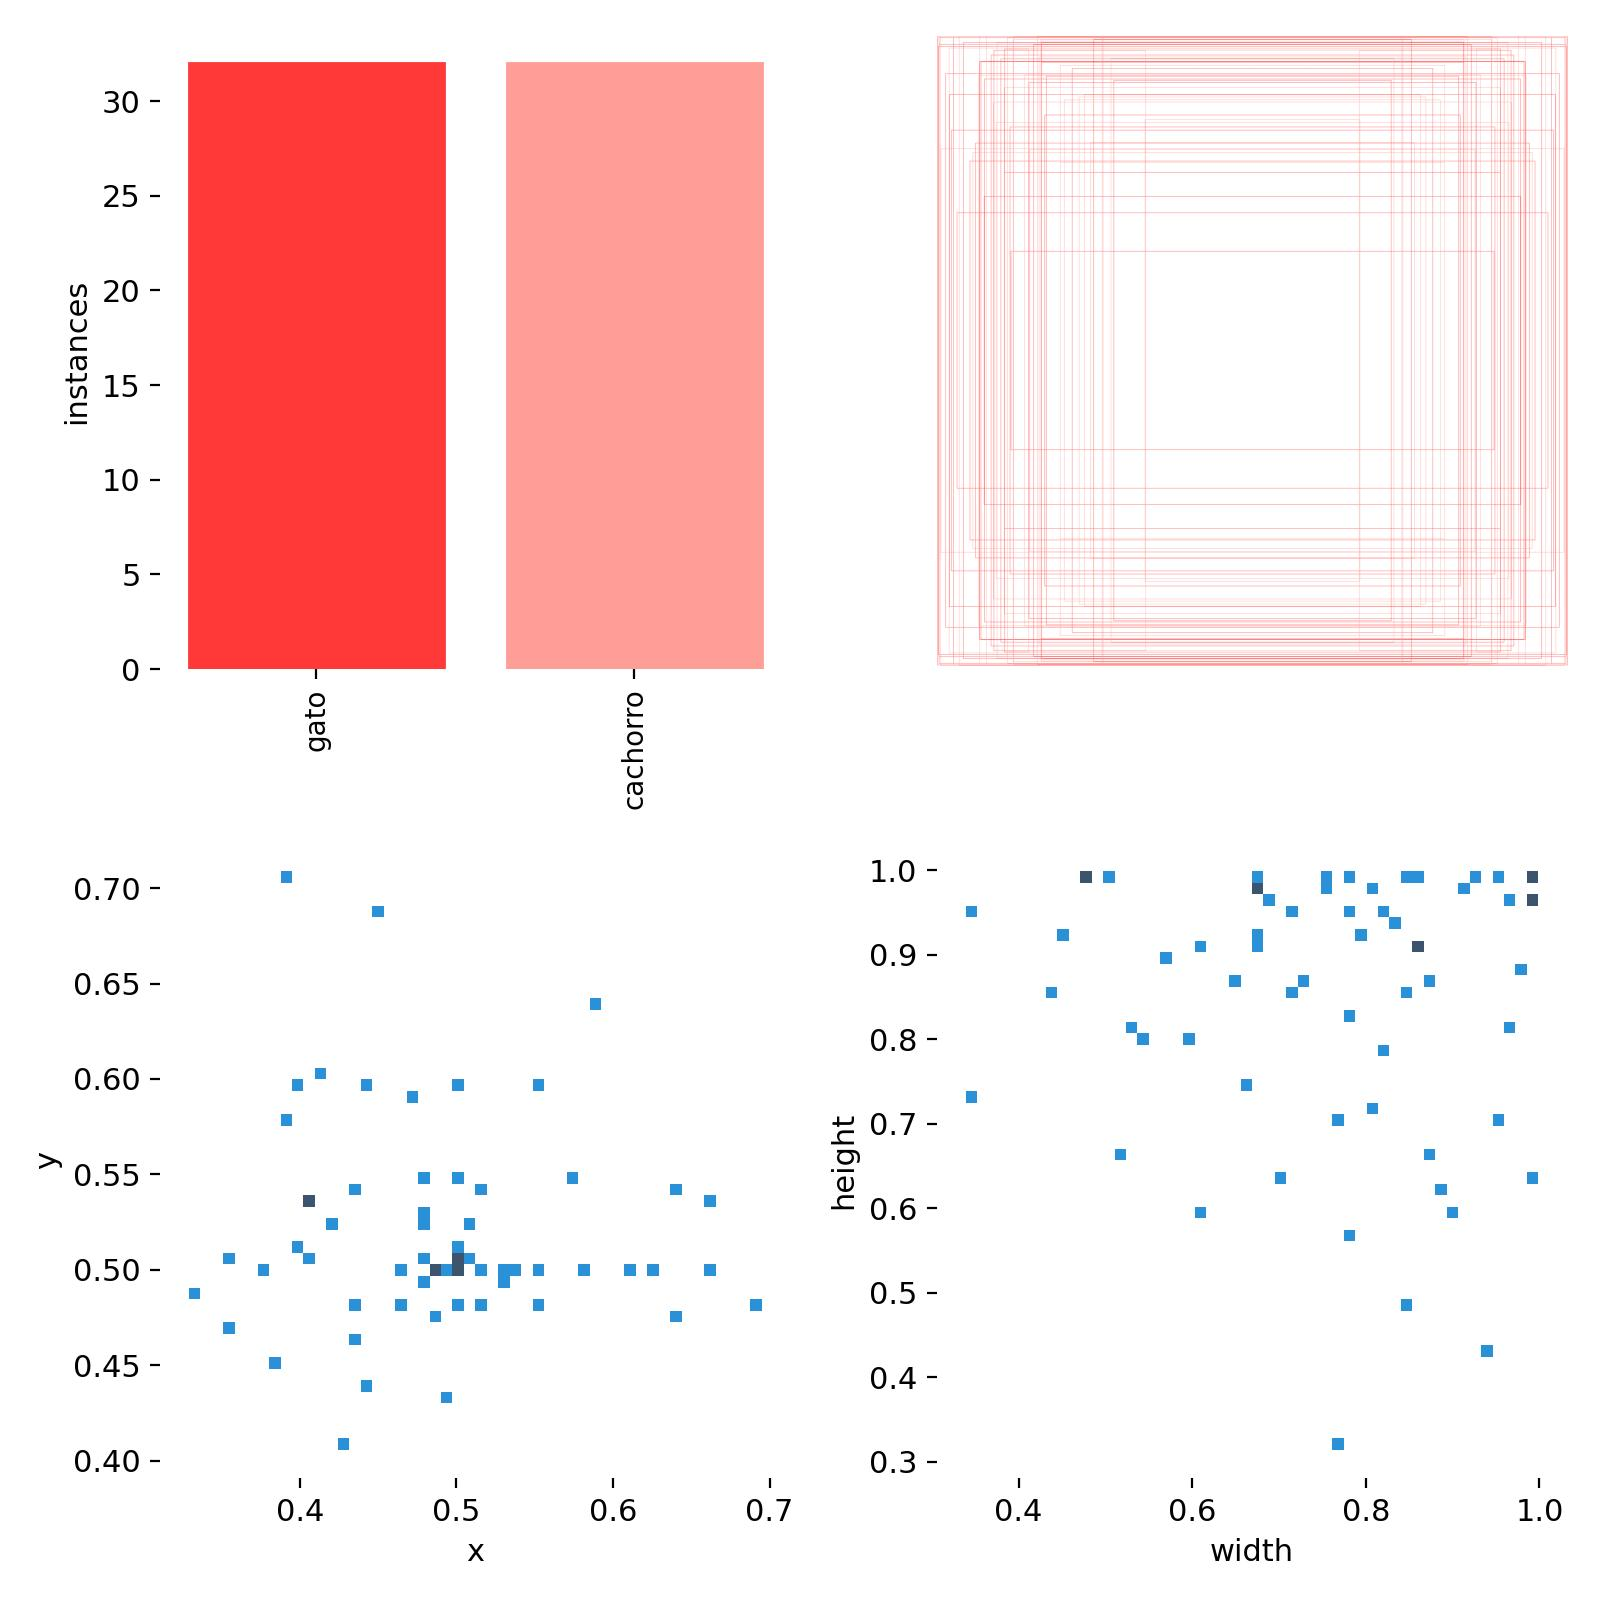


✅ Validação — Ground truth (rótulos verdadeiros)


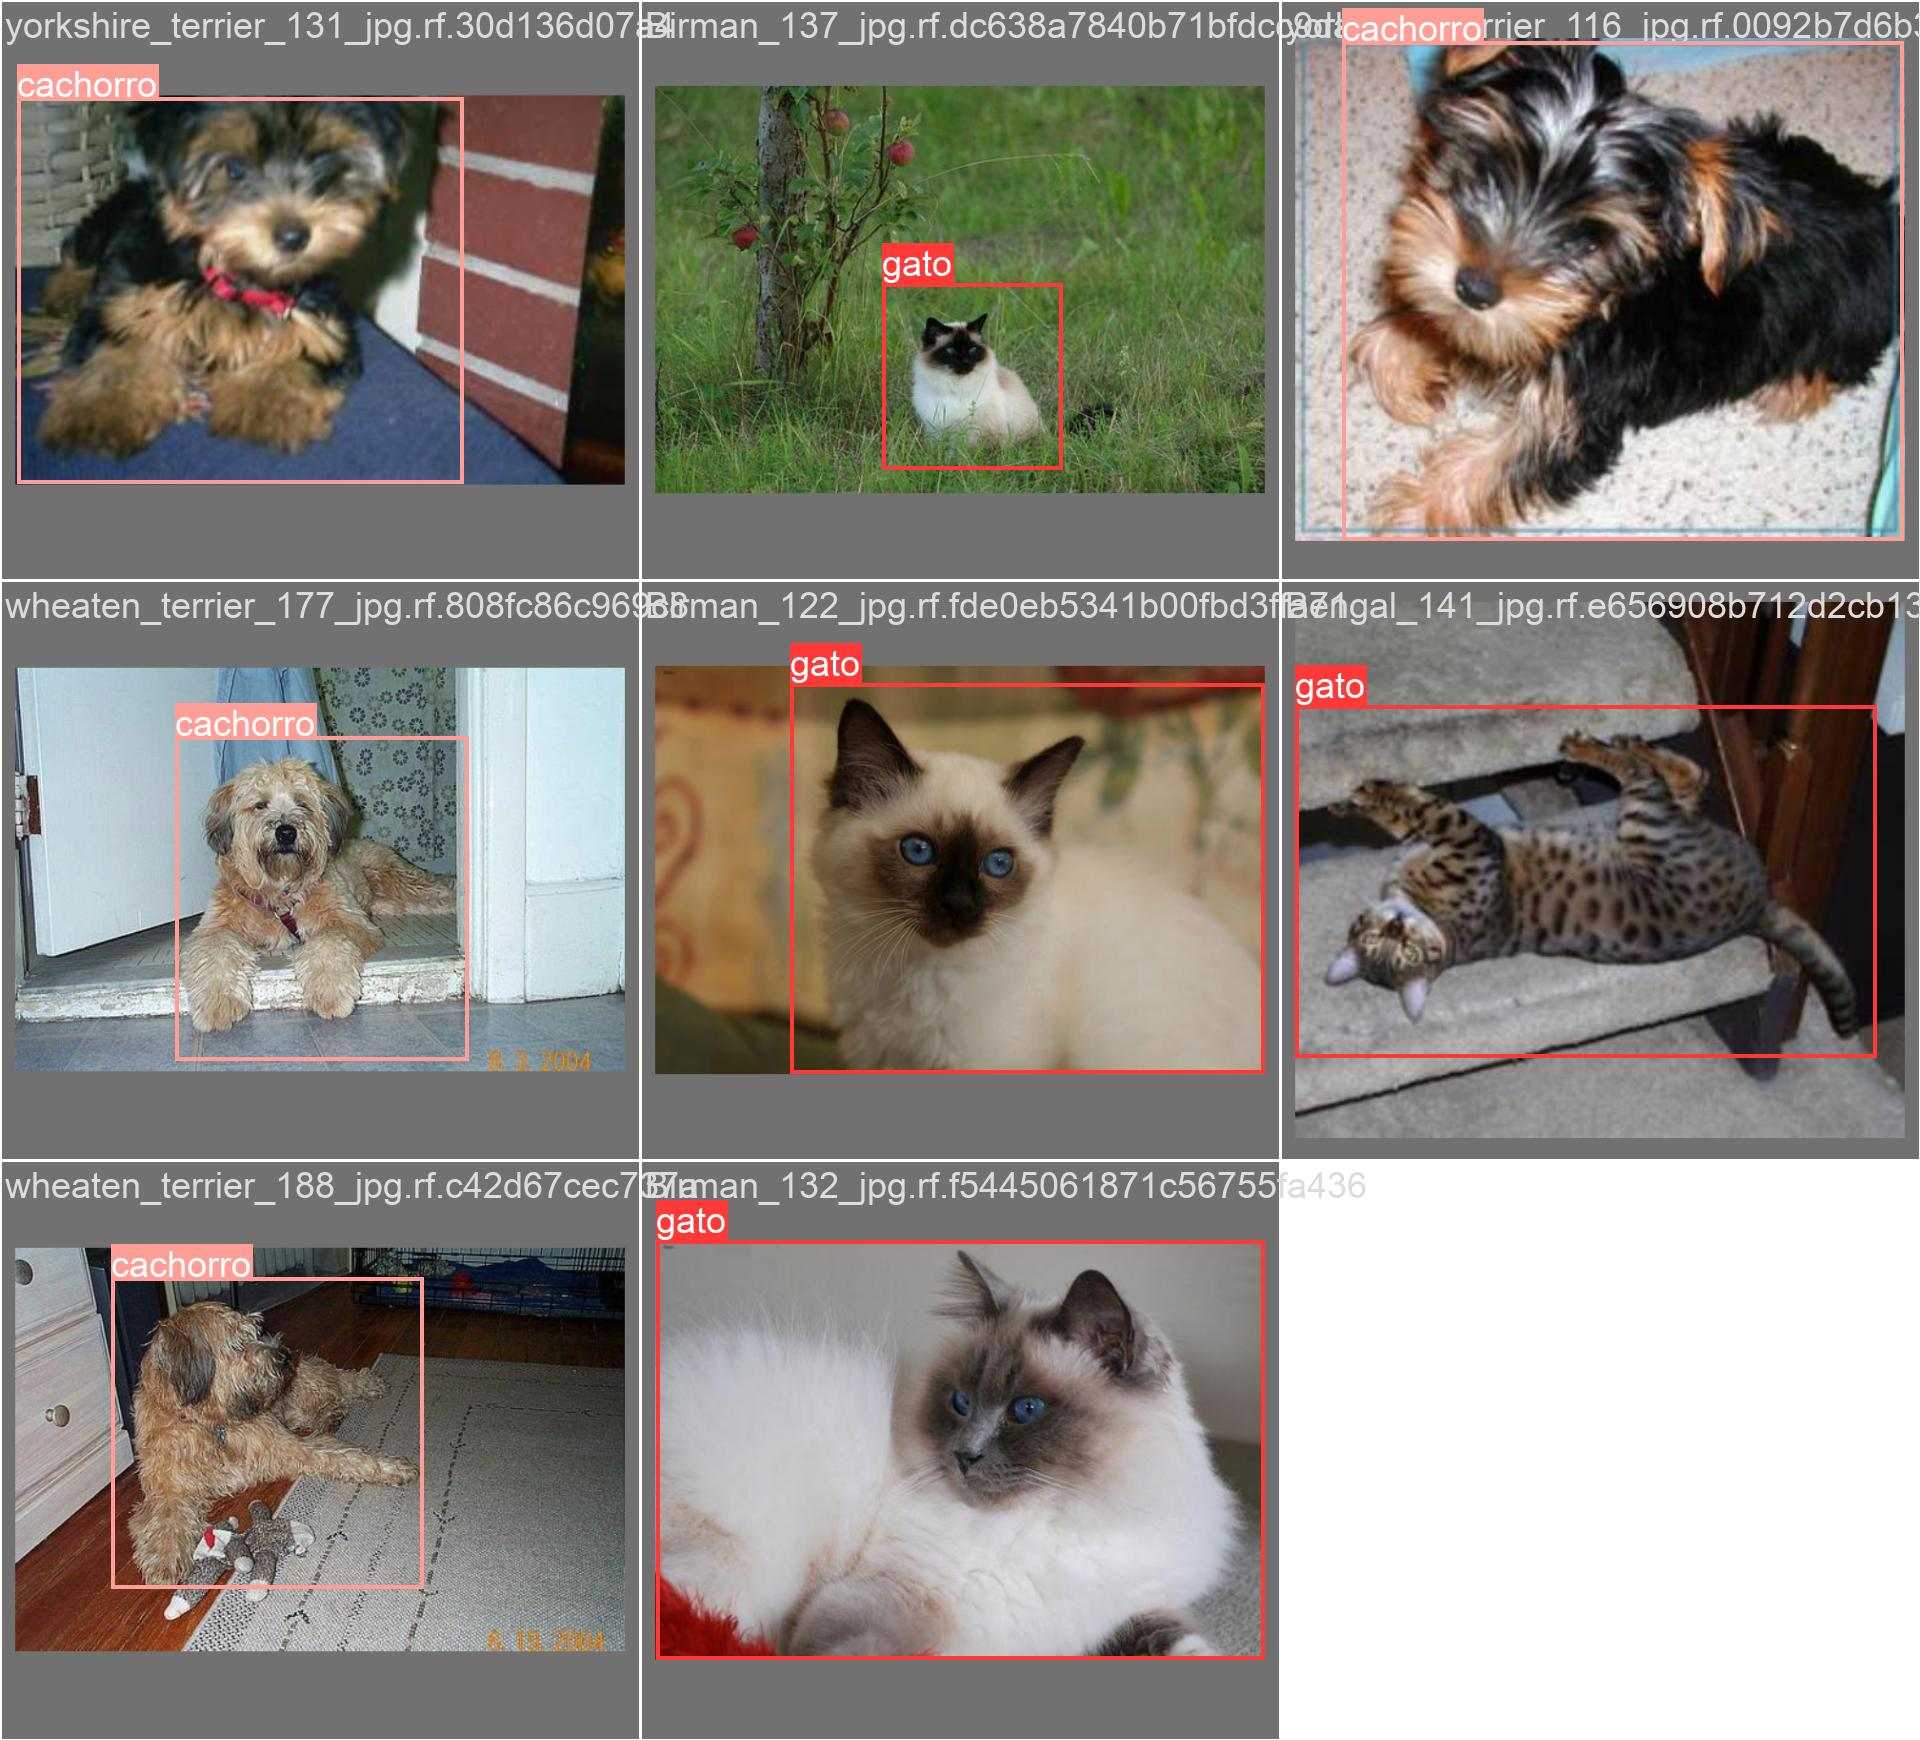


🔍 Validação — Predições do modelo


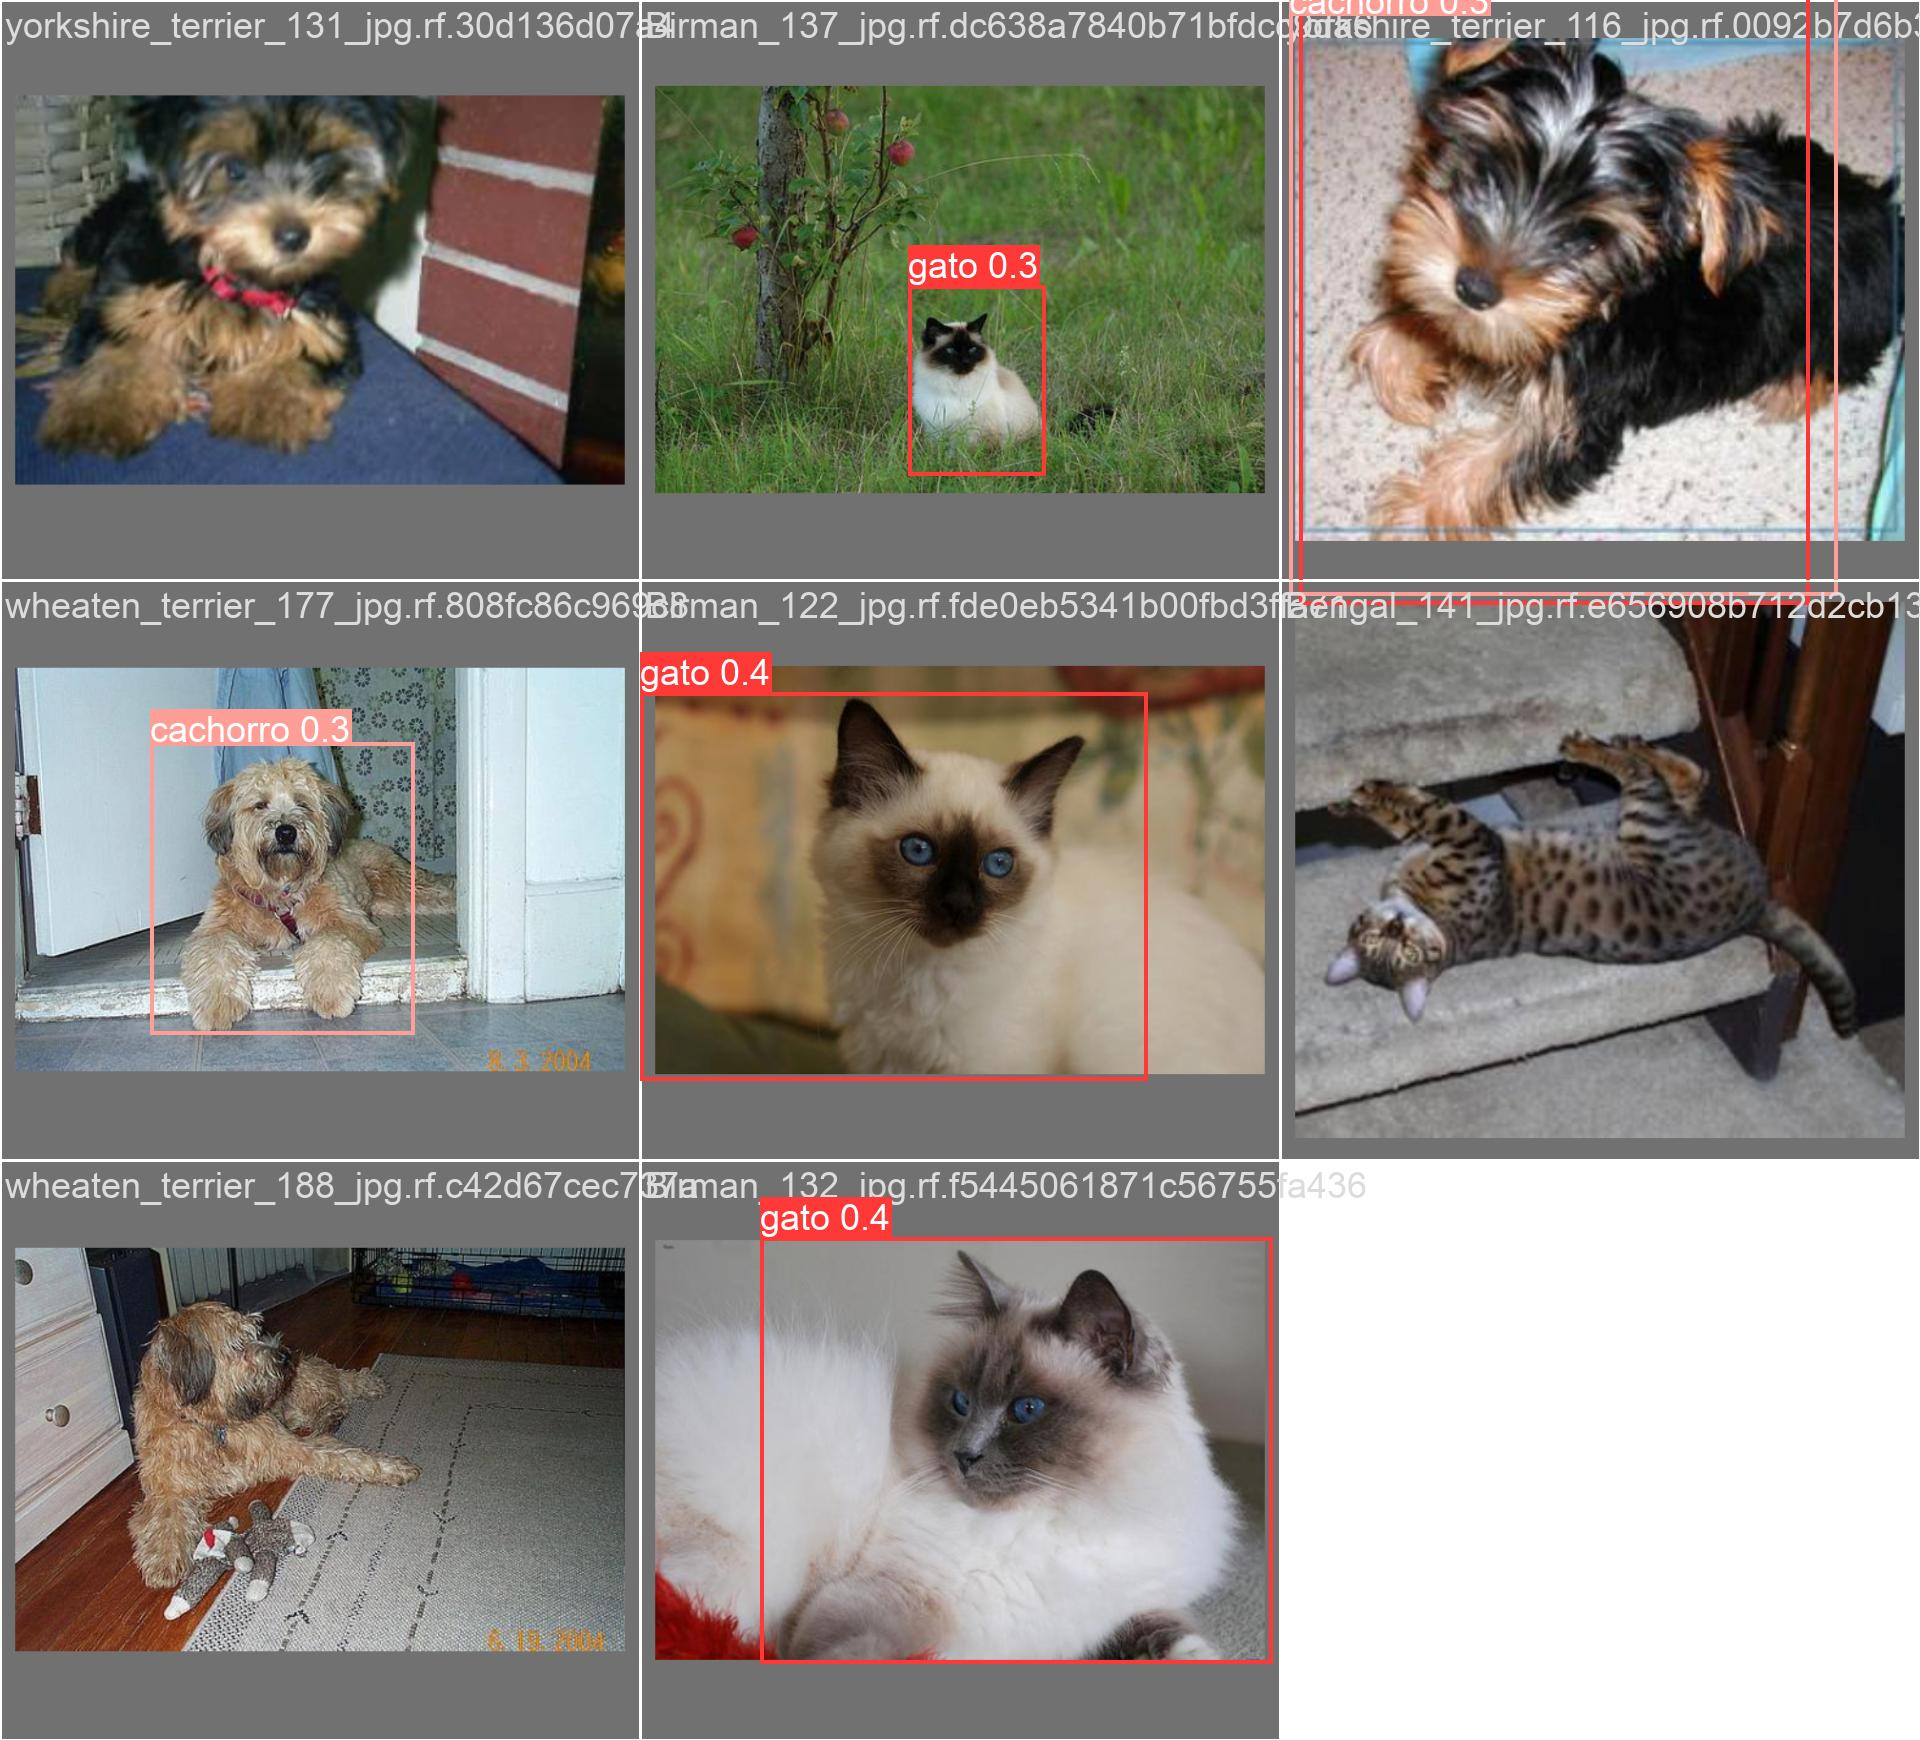

In [ ]:
# Exibe os gráficos gerados pelo YOLOv5 no treino corrigido (30 épocas, dataset OK)
from IPython.display import Image, display
import os

EXP_PATH = '/content/yolov5/runs/train/exp_30epochs_corrigido'

graficos = [
    ('results.png',           '📈 Evolução das losses e métricas ao longo das épocas'),
    ('confusion_matrix.png',  '🎯 Matriz de confusão (predições vs verdadeiro)'),
    ('PR_curve.png',          '📊 Curva Precision x Recall'),
    ('F1_curve.png',          '⚖️  Curva F1-Score por threshold'),
    ('labels.jpg',            '🏷️  Distribuição dos labels no dataset de treino'),
    ('val_batch0_labels.jpg', '✅ Validação — Ground truth (rótulos verdadeiros)'),
    ('val_batch0_pred.jpg',   '🔍 Validação — Predições do modelo'),
]

for arquivo, descricao in graficos:
    caminho = os.path.join(EXP_PATH, arquivo)
    if os.path.exists(caminho):
        print(f"\n{descricao}")
        display(Image(filename=caminho, width=800))
    else:
        print(f"\n⚠️ Arquivo não encontrado: {arquivo}")

### 5.2 Análise dos resultados — Treino corrigido (30 épocas)

Após a correção dos rótulos de validação, observamos uma melhora drástica em todas as métricas.

#### Métricas finais

| Classe | Imagens | Instâncias | Precision | Recall | mAP@0.5 | mAP@0.5:0.95 |
|--------|---------|------------|-----------|--------|---------|--------------|
| **all** | 8 | 8 | 0.752 | 0.741 | **0.901** | **0.511** |
| gato | 8 | 4 | 0.505 | 0.750 | 0.808 | 0.421 |
| cachorro | 8 | 4 | **1.000** | 0.732 | **0.995** | 0.601 |

#### Evolução das losses e métricas

Observando o gráfico `results.png`:

- **train/box_loss** caiu consistentemente de ~0.08 para ~0.03, mostrando que o modelo aprendeu a localizar bem os objetos.
- **train/obj_loss** e **train/cls_loss** também caíram suavemente, confirmando bom aprendizado.
- **val/box_loss**, **val/obj_loss** e **val/cls_loss** mostram tendência decrescente sem sinais fortes de overfitting (não houve subida significativa após estabilização).
- **mAP@0.5** subiu progressivamente até atingir cerca de 0.90 nas últimas épocas, com pico em torno da época 24-28.
- **mAP@0.5:0.95** atingiu ~0.51 — métrica mais rigorosa, indicando boa qualidade na localização.

#### Matriz de confusão

A matriz mostra que:
- **Cachorro** foi predito corretamente em 50% das instâncias e classificado como `background` (não detectado) em 50%.
- **Gato** foi predito corretamente em 75% das instâncias e classificado como `background` em 25%.
- **Não houve confusão entre as duas classes** — quando o modelo detecta, ele acerta a classe.
- O principal modo de falha é o "missed detection" (deixar de detectar), e não a classificação errada.

#### Curva Precision-Recall

A área sob a curva (AP) é alta para ambas as classes:
- `cachorro: 0.995` (praticamente perfeita)
- `gato: 0.808`
- `mAP geral: 0.901`

O cachorro teve performance excelente, enquanto o gato apresentou queda de Precision em valores altos de Recall — o modelo precisa ser menos exigente na confiança para detectar todos os gatos, mas isso introduz alguns falsos positivos.

#### Curva F1-Confidence

O F1-score máximo (`0.77`) é atingido com threshold de confiança em `0.112`. Esse é um valor relativamente baixo, indicando que o modelo poderia se beneficiar de mais épocas ou mais dados para gerar predições com maior confiança.

#### Predições visuais (val_batch0_pred.jpg)

Inspecionando as predições:
- O modelo detectou corretamente várias imagens de gato (Birman, Bengal, Ragdoll) com confiança entre 0.3 e 0.4.
- Detectou cachorros (Wheaten Terrier) também corretamente.
- Algumas imagens não tiveram detecção (Yorkshire Terrier, por exemplo) — explicando o "background" da matriz de confusão.
- As classificações foram coerentes: o modelo distingue gato de cachorro mesmo em poses e contextos variados.

### 5.2 Considerações parciais

Com 30 épocas e o dataset corrigido, o modelo já apresenta excelente performance, especialmente para a classe **cachorro**. A classe **gato** poderia se beneficiar de mais épocas de treinamento ou de threshold de confiança ajustado. Isso será investigado no próximo experimento, com 60 épocas.

## 6. Experimento 2 — Treino com 60 épocas

Conforme exigido pelo enunciado do projeto, realizamos uma segunda simulação com
um número significativamente diferente de épocas, para avaliar o impacto desse
hiperparâmetro nos resultados.

### Hipótese

Aumentando as épocas de **30 para 60**, esperamos:

- Possível **melhora nas métricas**, pois o modelo terá mais oportunidades de ajustar seus pesos.
- Possível **aparecimento de overfitting**, uma vez que nosso dataset é pequeno (64 imagens de treino) — o modelo pode "memorizar" o treino em vez de generalizar.

A comparação dos resultados nos permitirá entender se 30 épocas são suficientes
para essa tarefa, ou se mais tempo de treinamento traz ganhos reais.

### Parâmetros

Todos os hiperparâmetros são mantidos idênticos ao Experimento 1, exceto o número
de épocas:

| Parâmetro | Valor |
|-----------|-------|
| Modelo base | yolov5s.pt (transfer learning) |
| **Épocas** | **60** ⬅ alterado |
| Batch size | 16 |
| Tamanho da imagem | 640x640 |
| Otimizador | SGD |
| Learning rate inicial | 0.01 |
| Dataset | 64 treino / 8 validação |

In [ ]:
# Experimento 2 — Treinamento com 60 épocas
%cd /content/yolov5

!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 60 \
  --data /content/yolov5/data/petshop.yaml \
  --weights yolov5s.pt \
  --name exp_60epochs \
  --project runs/train

/content/yolov5
2026-04-27 15:10:33.030433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777302633.052100   23034 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777302633.059169   23034 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777302633.078045   23034 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777302633.078097   23034 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777302633.078102   23034 computation_placer.cc:177] comput


📈 Evolução das losses e métricas — 60 épocas


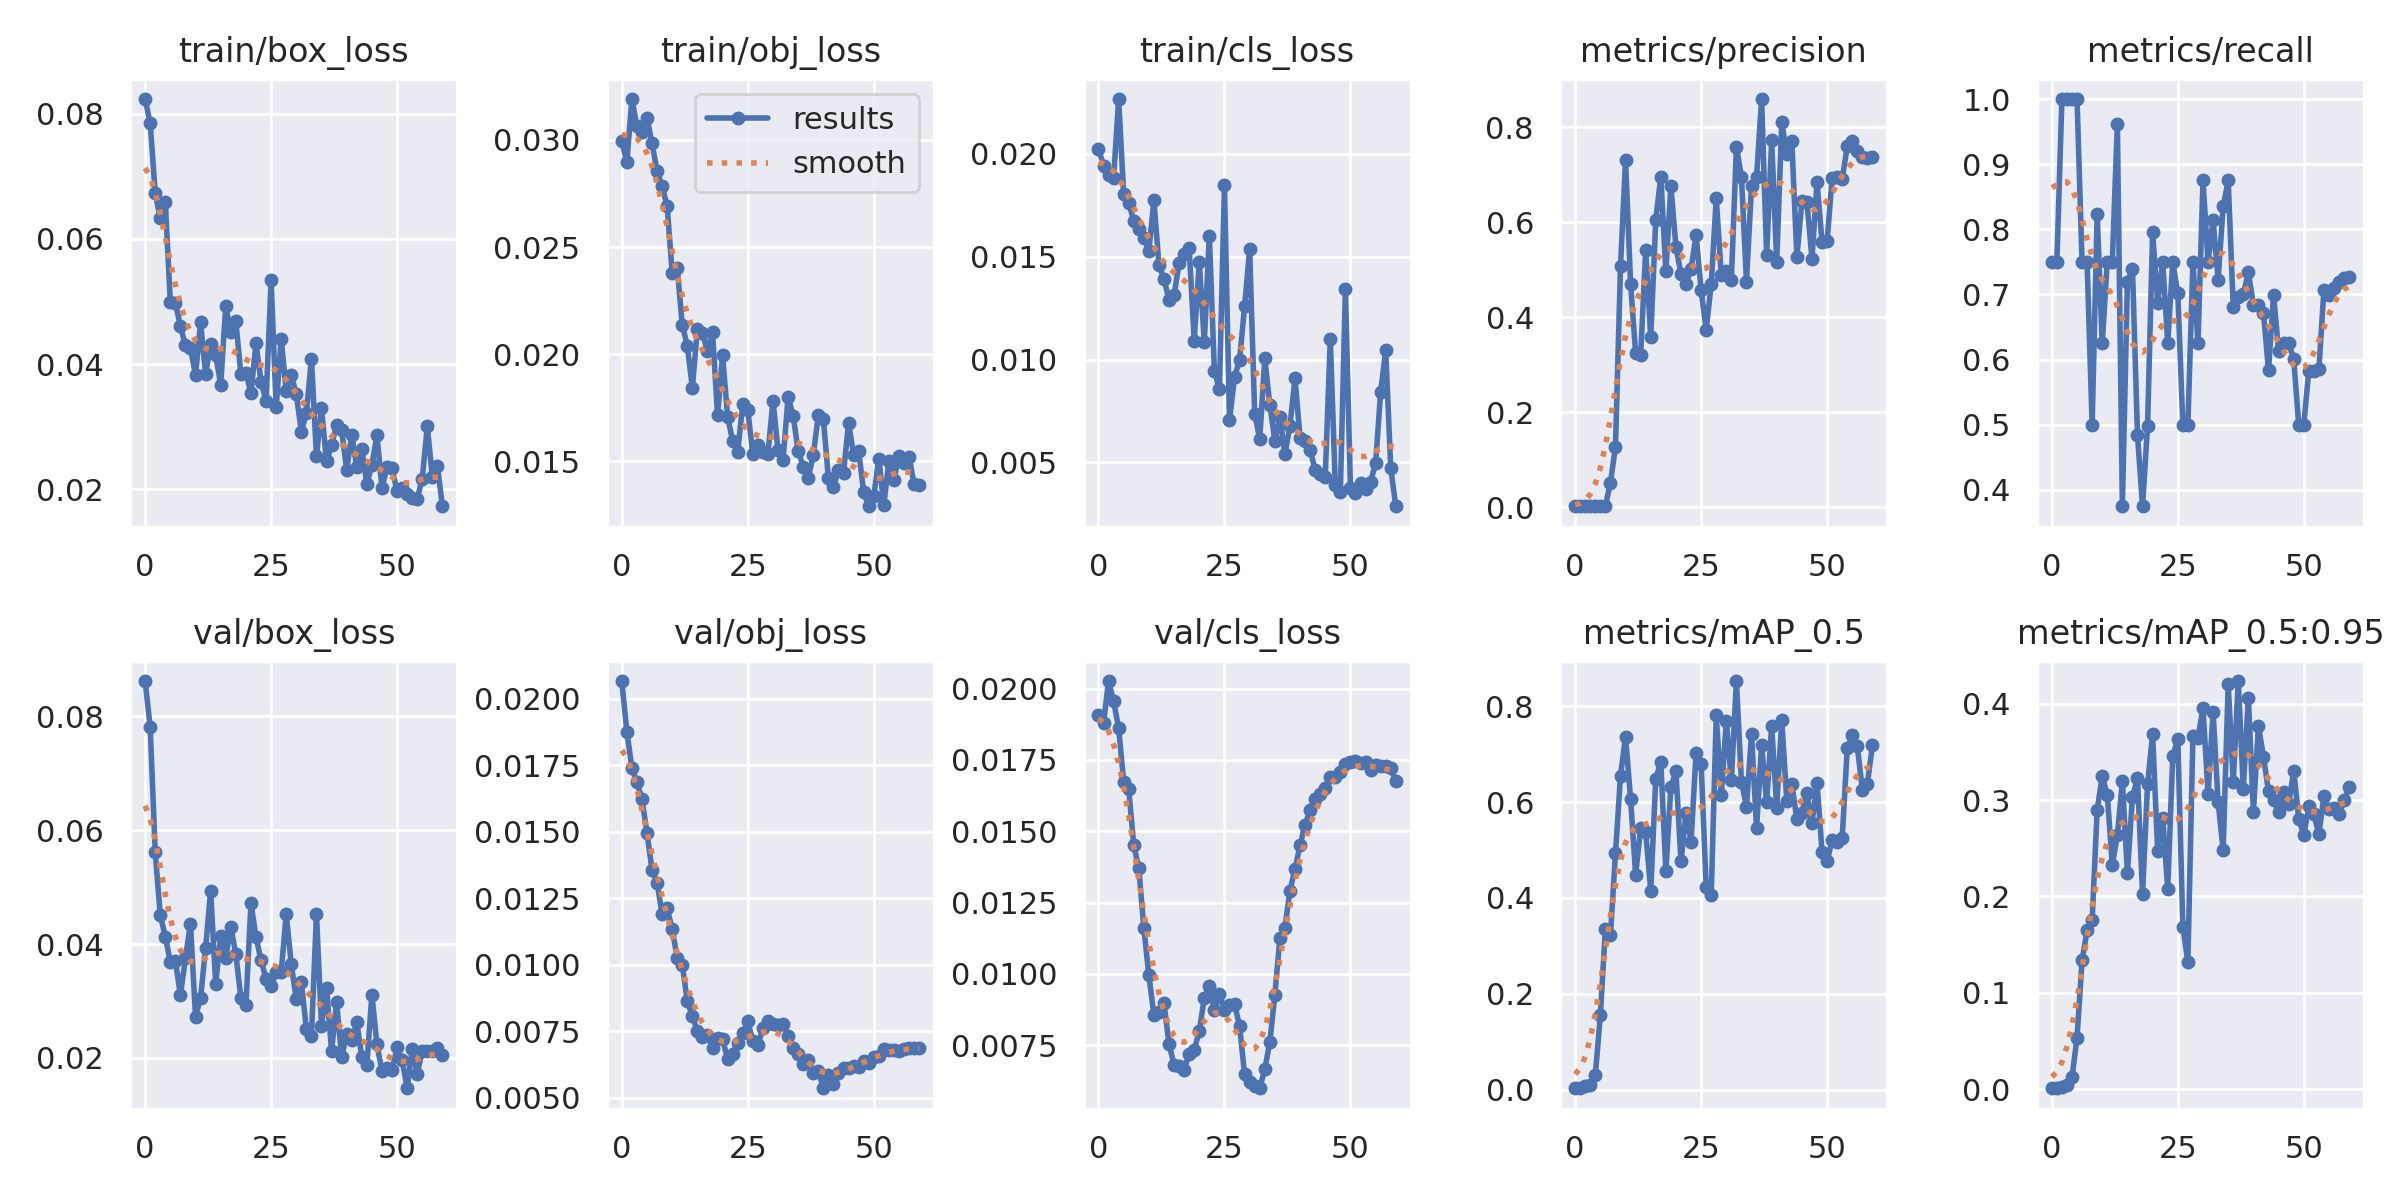


🎯 Matriz de confusão — 60 épocas


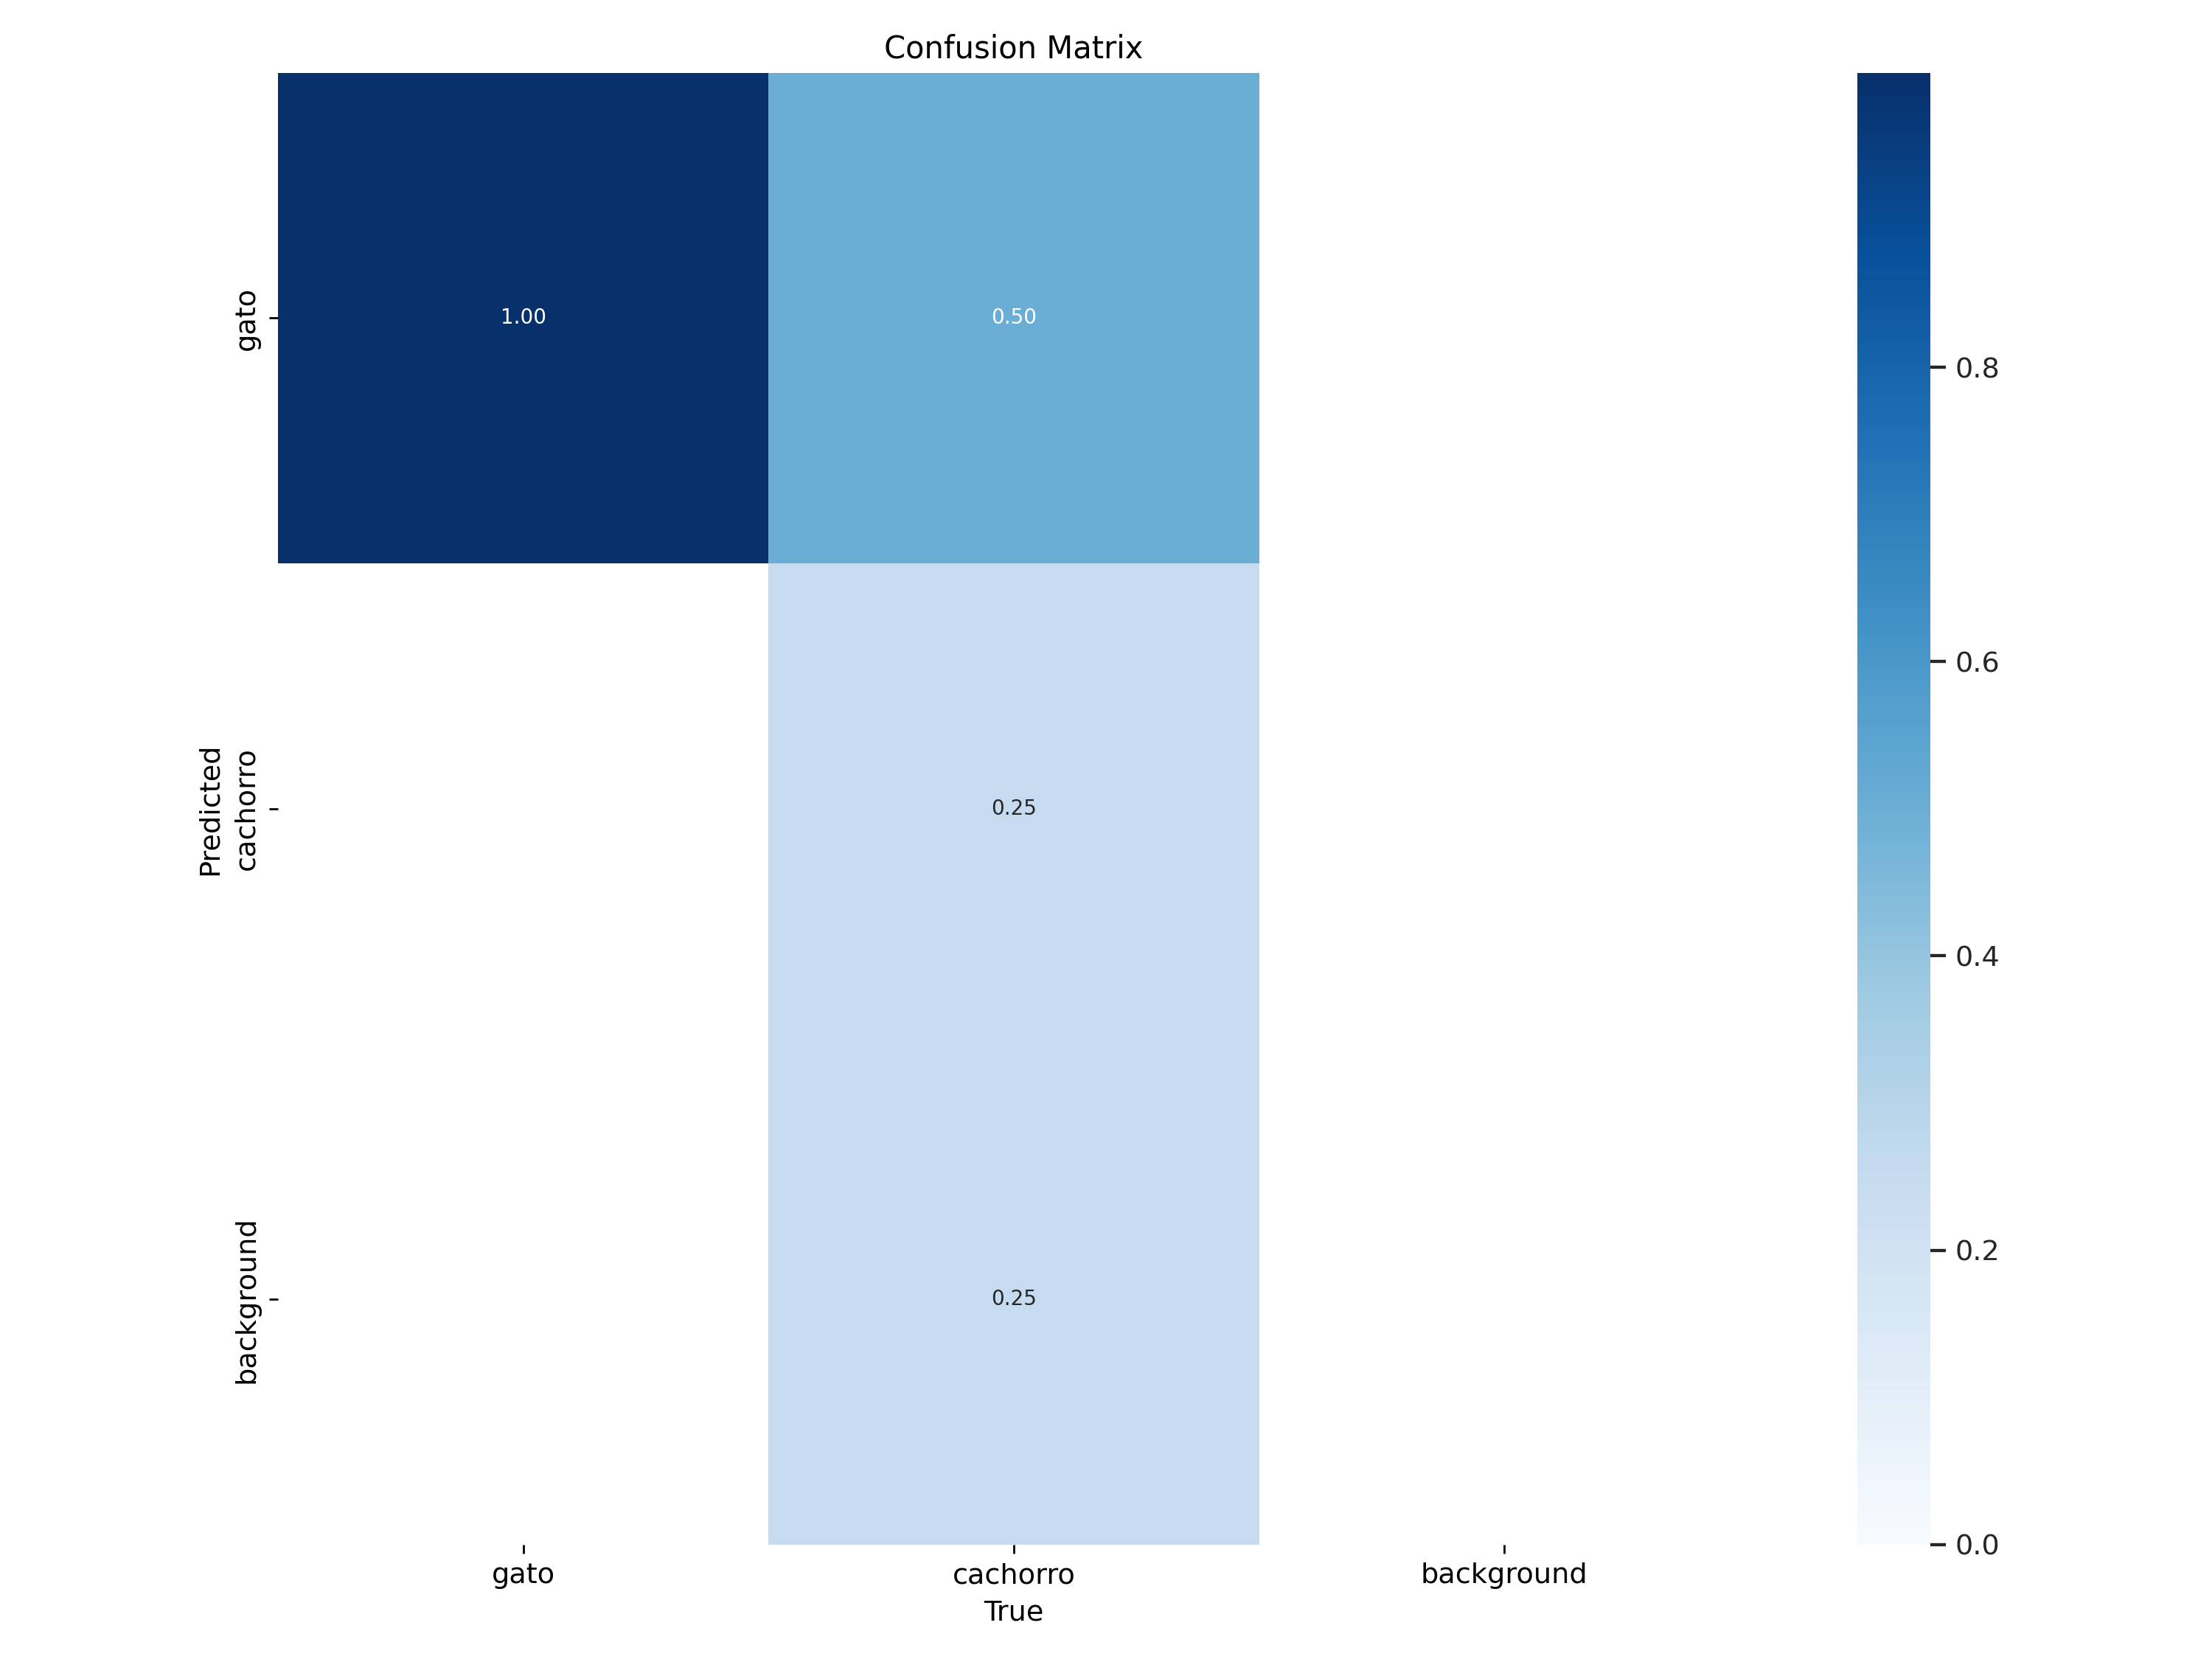


📊 Curva Precision x Recall — 60 épocas


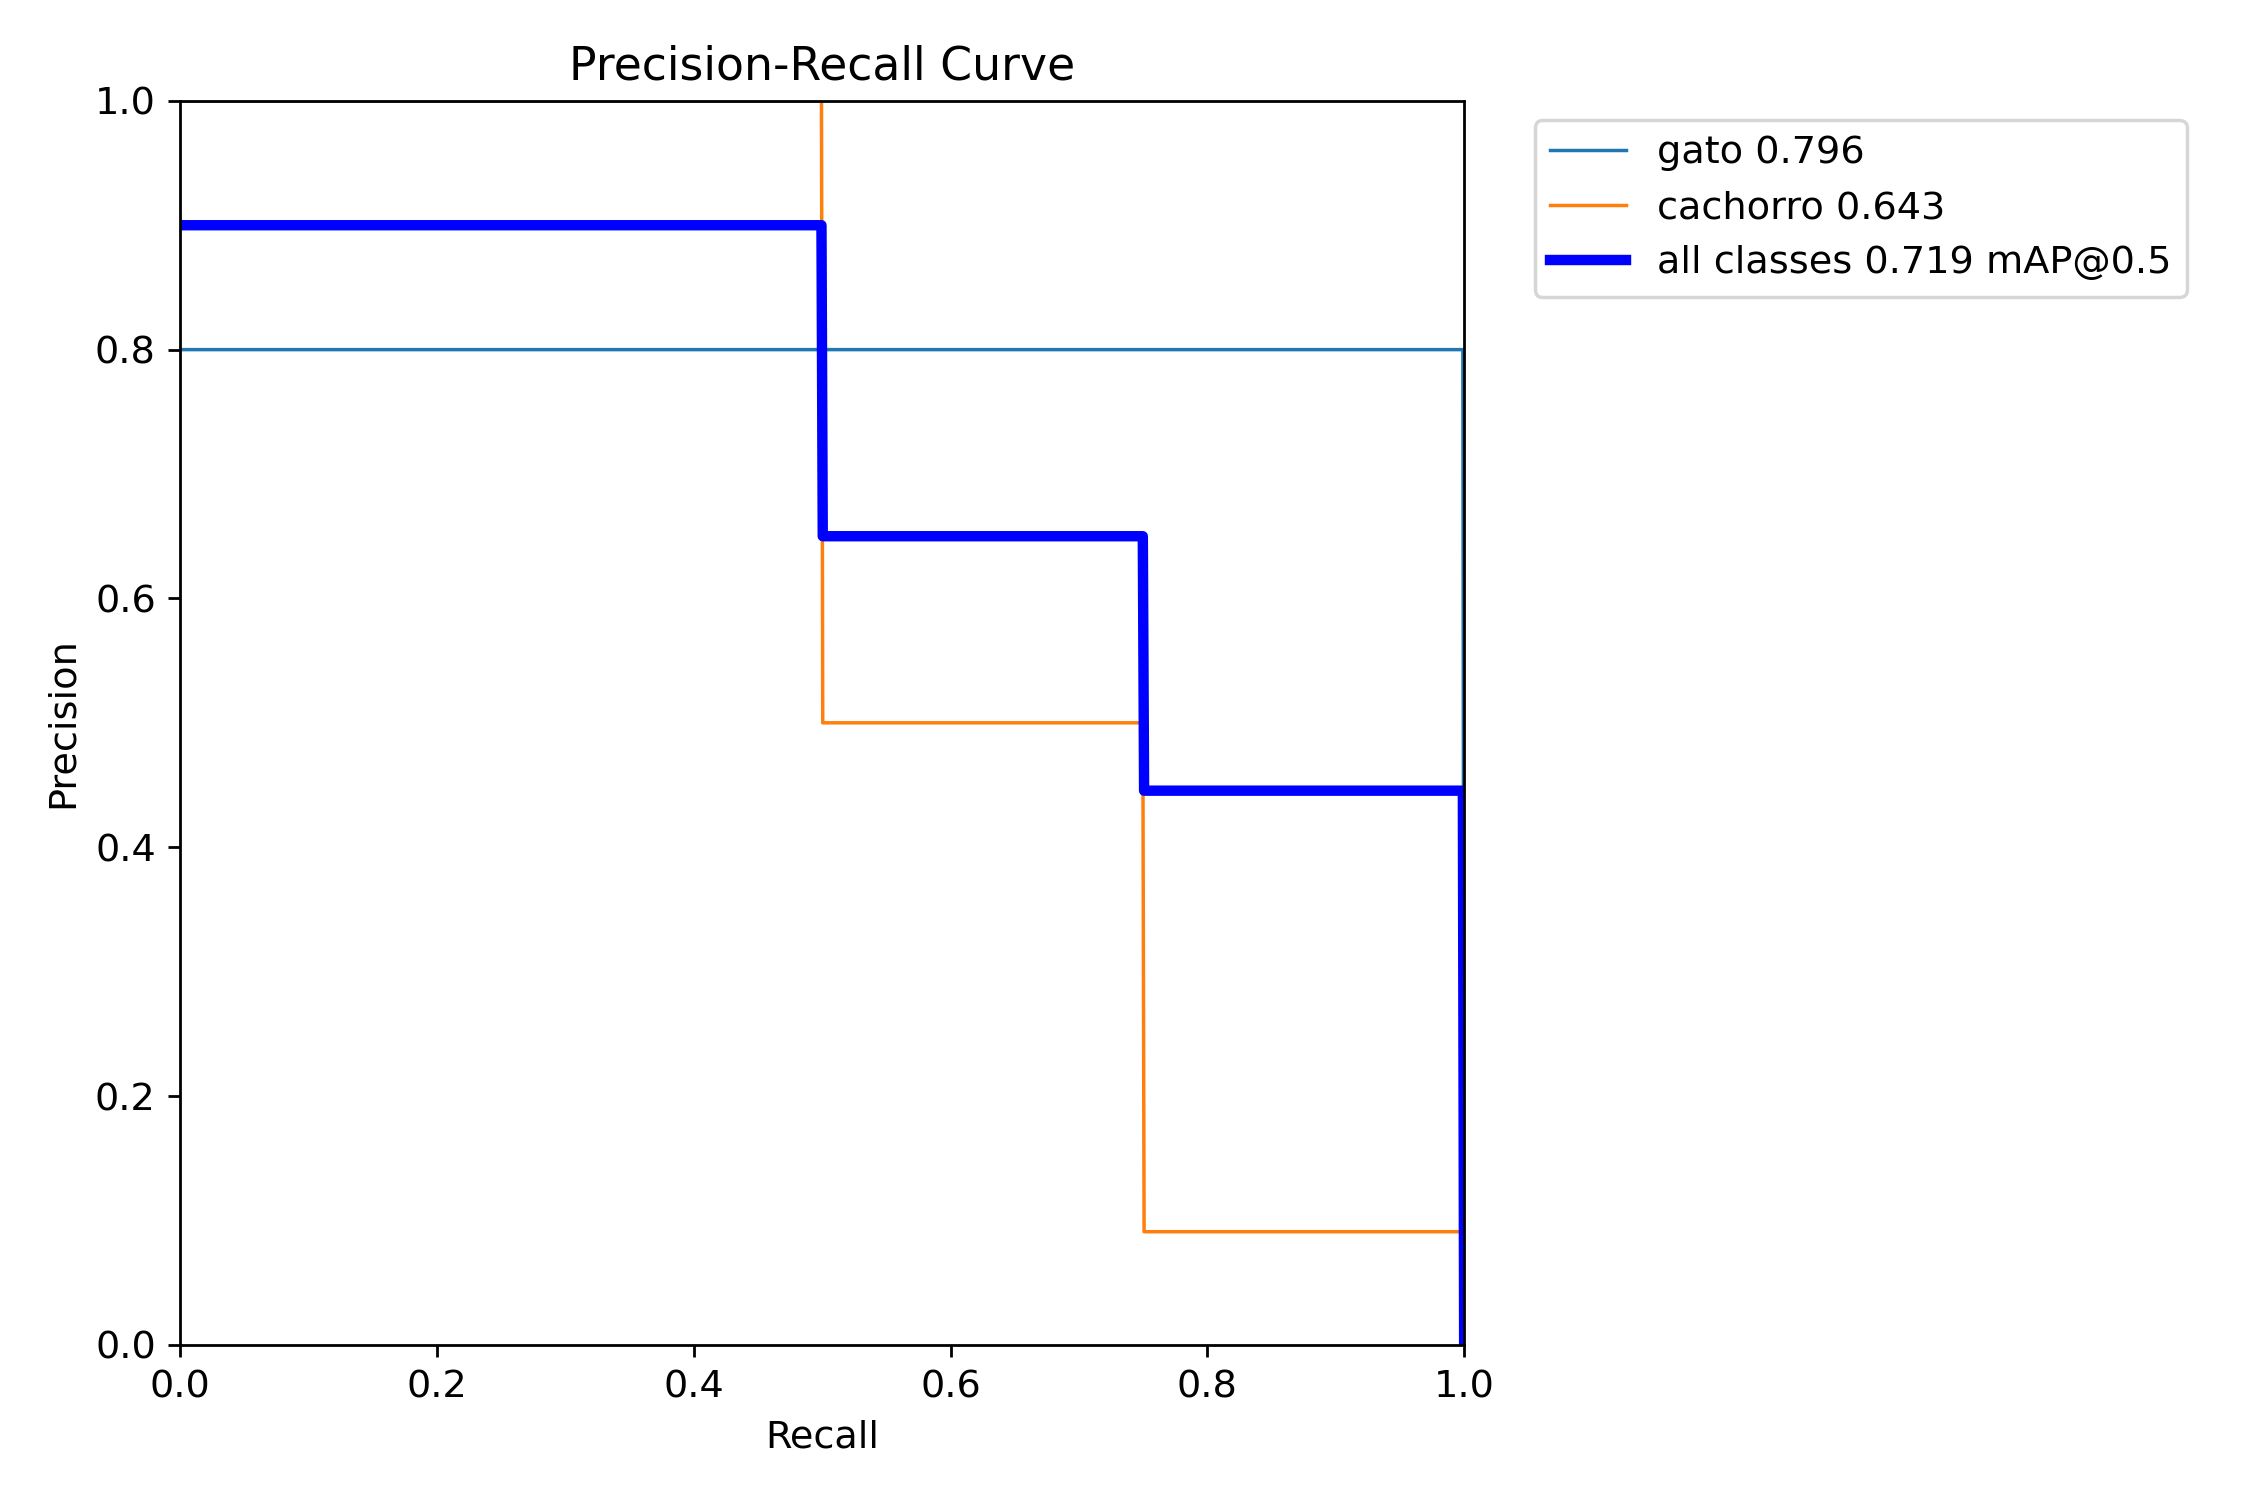


⚖️  Curva F1-Score por threshold — 60 épocas


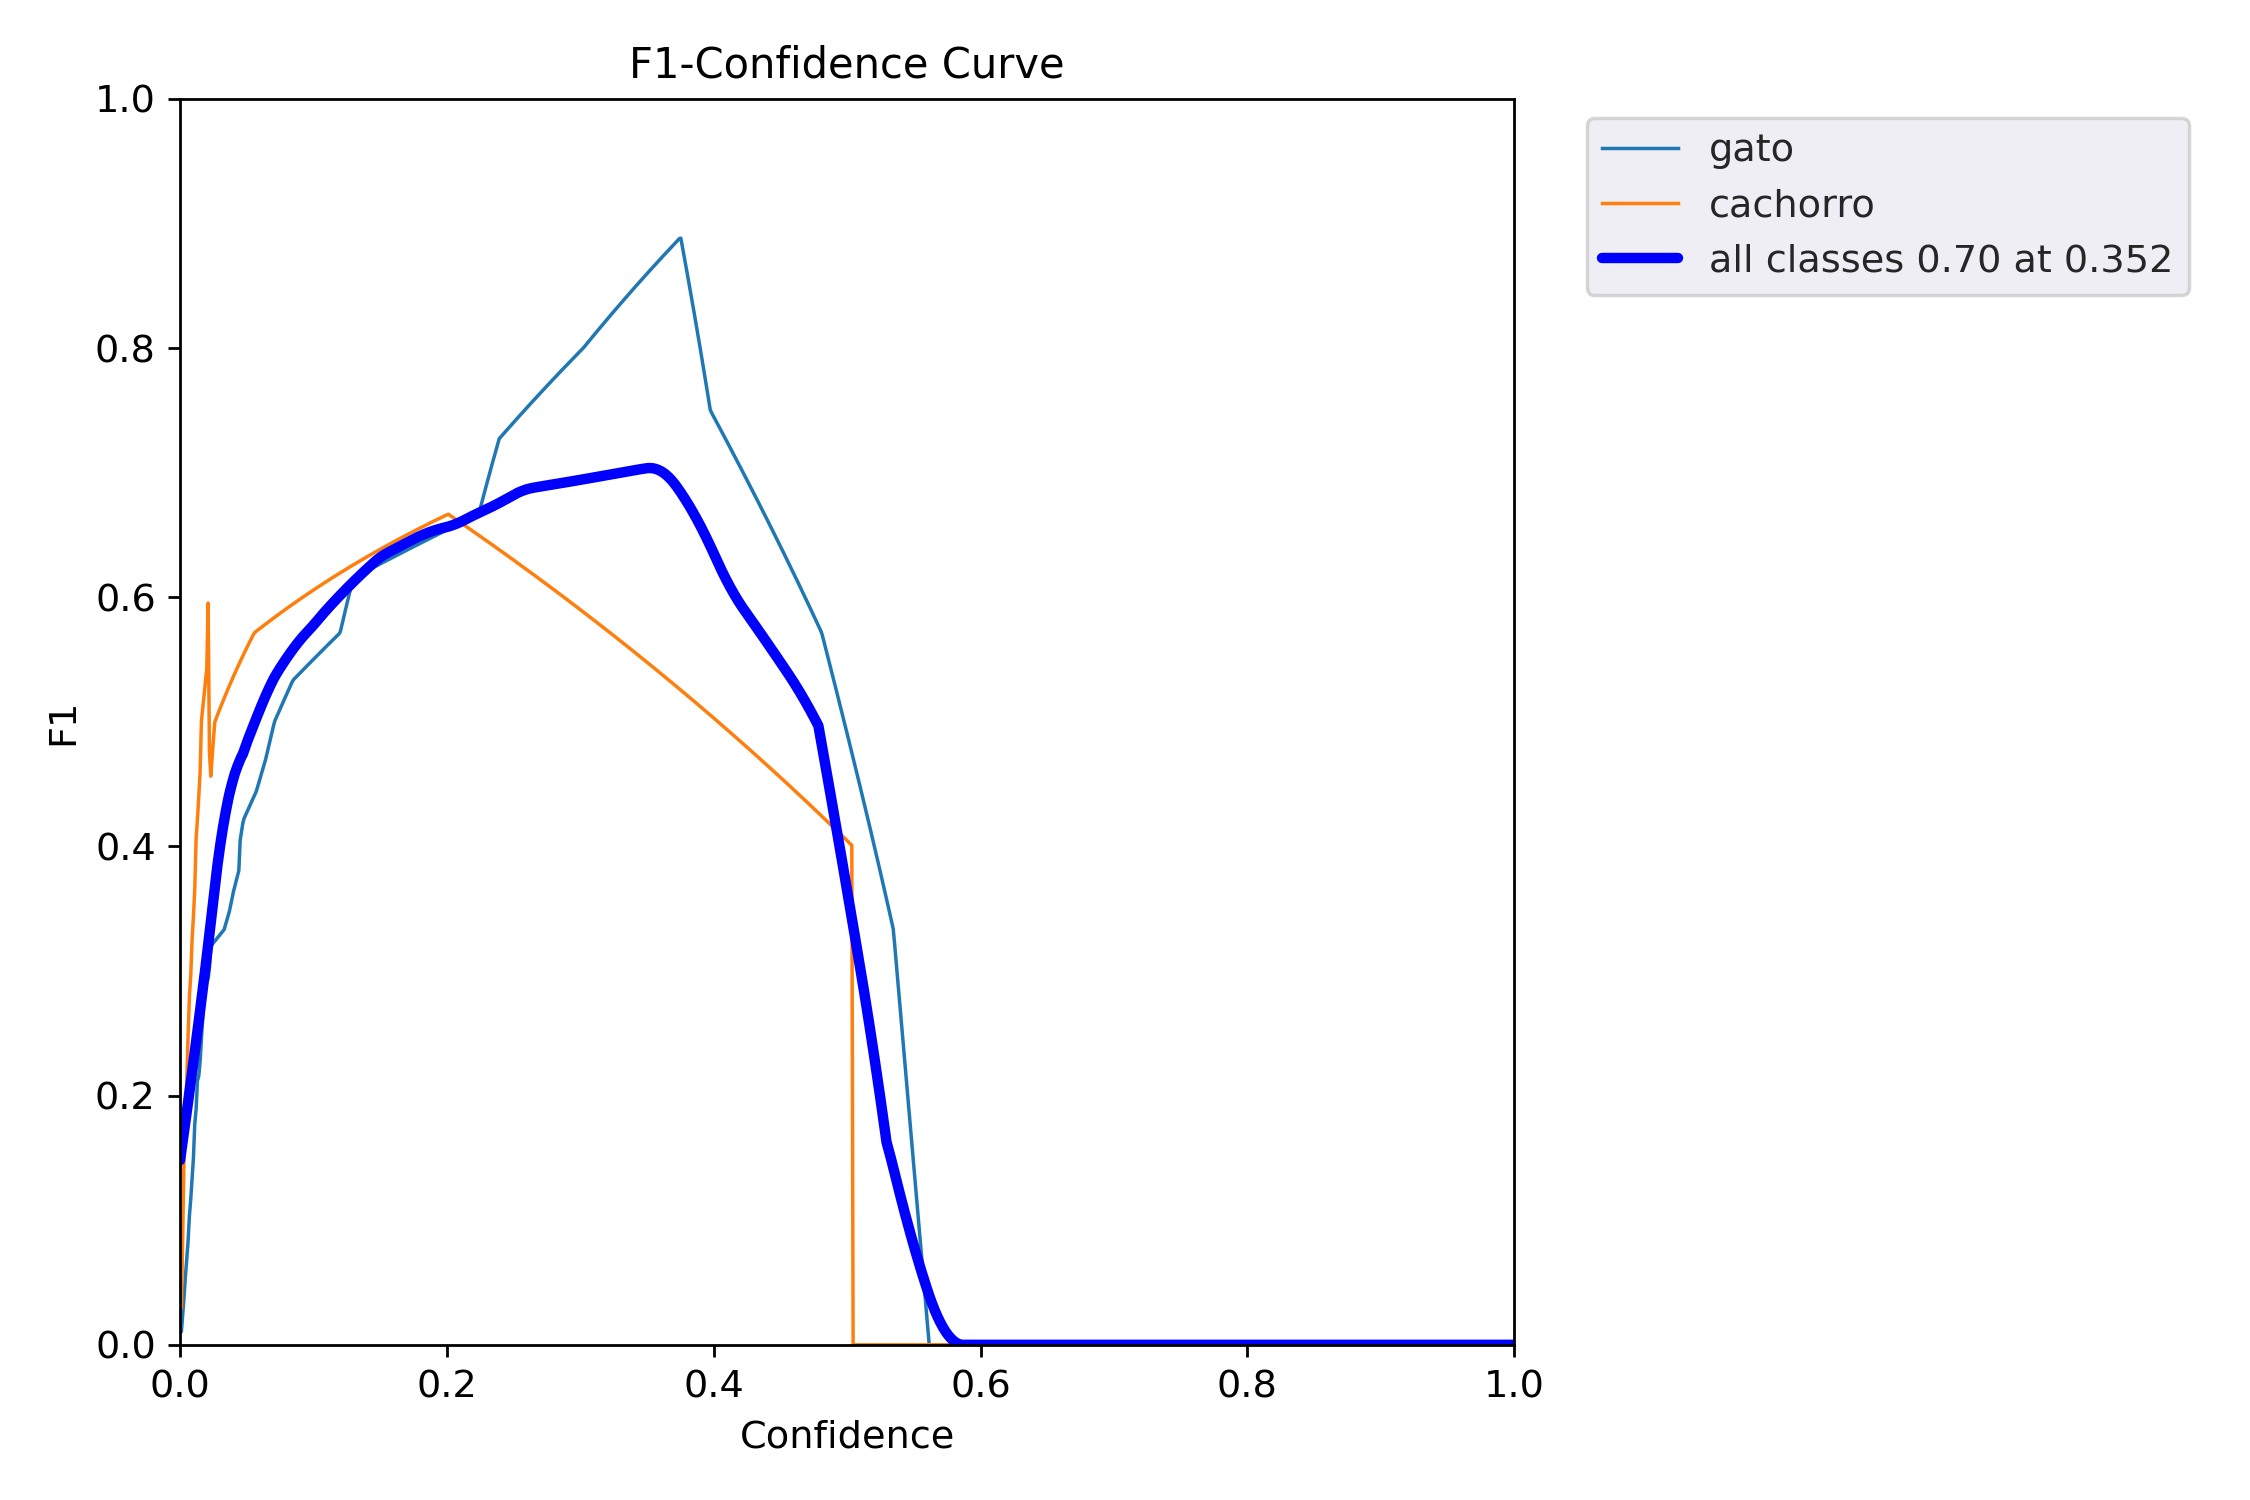


✅ Validação — Ground truth


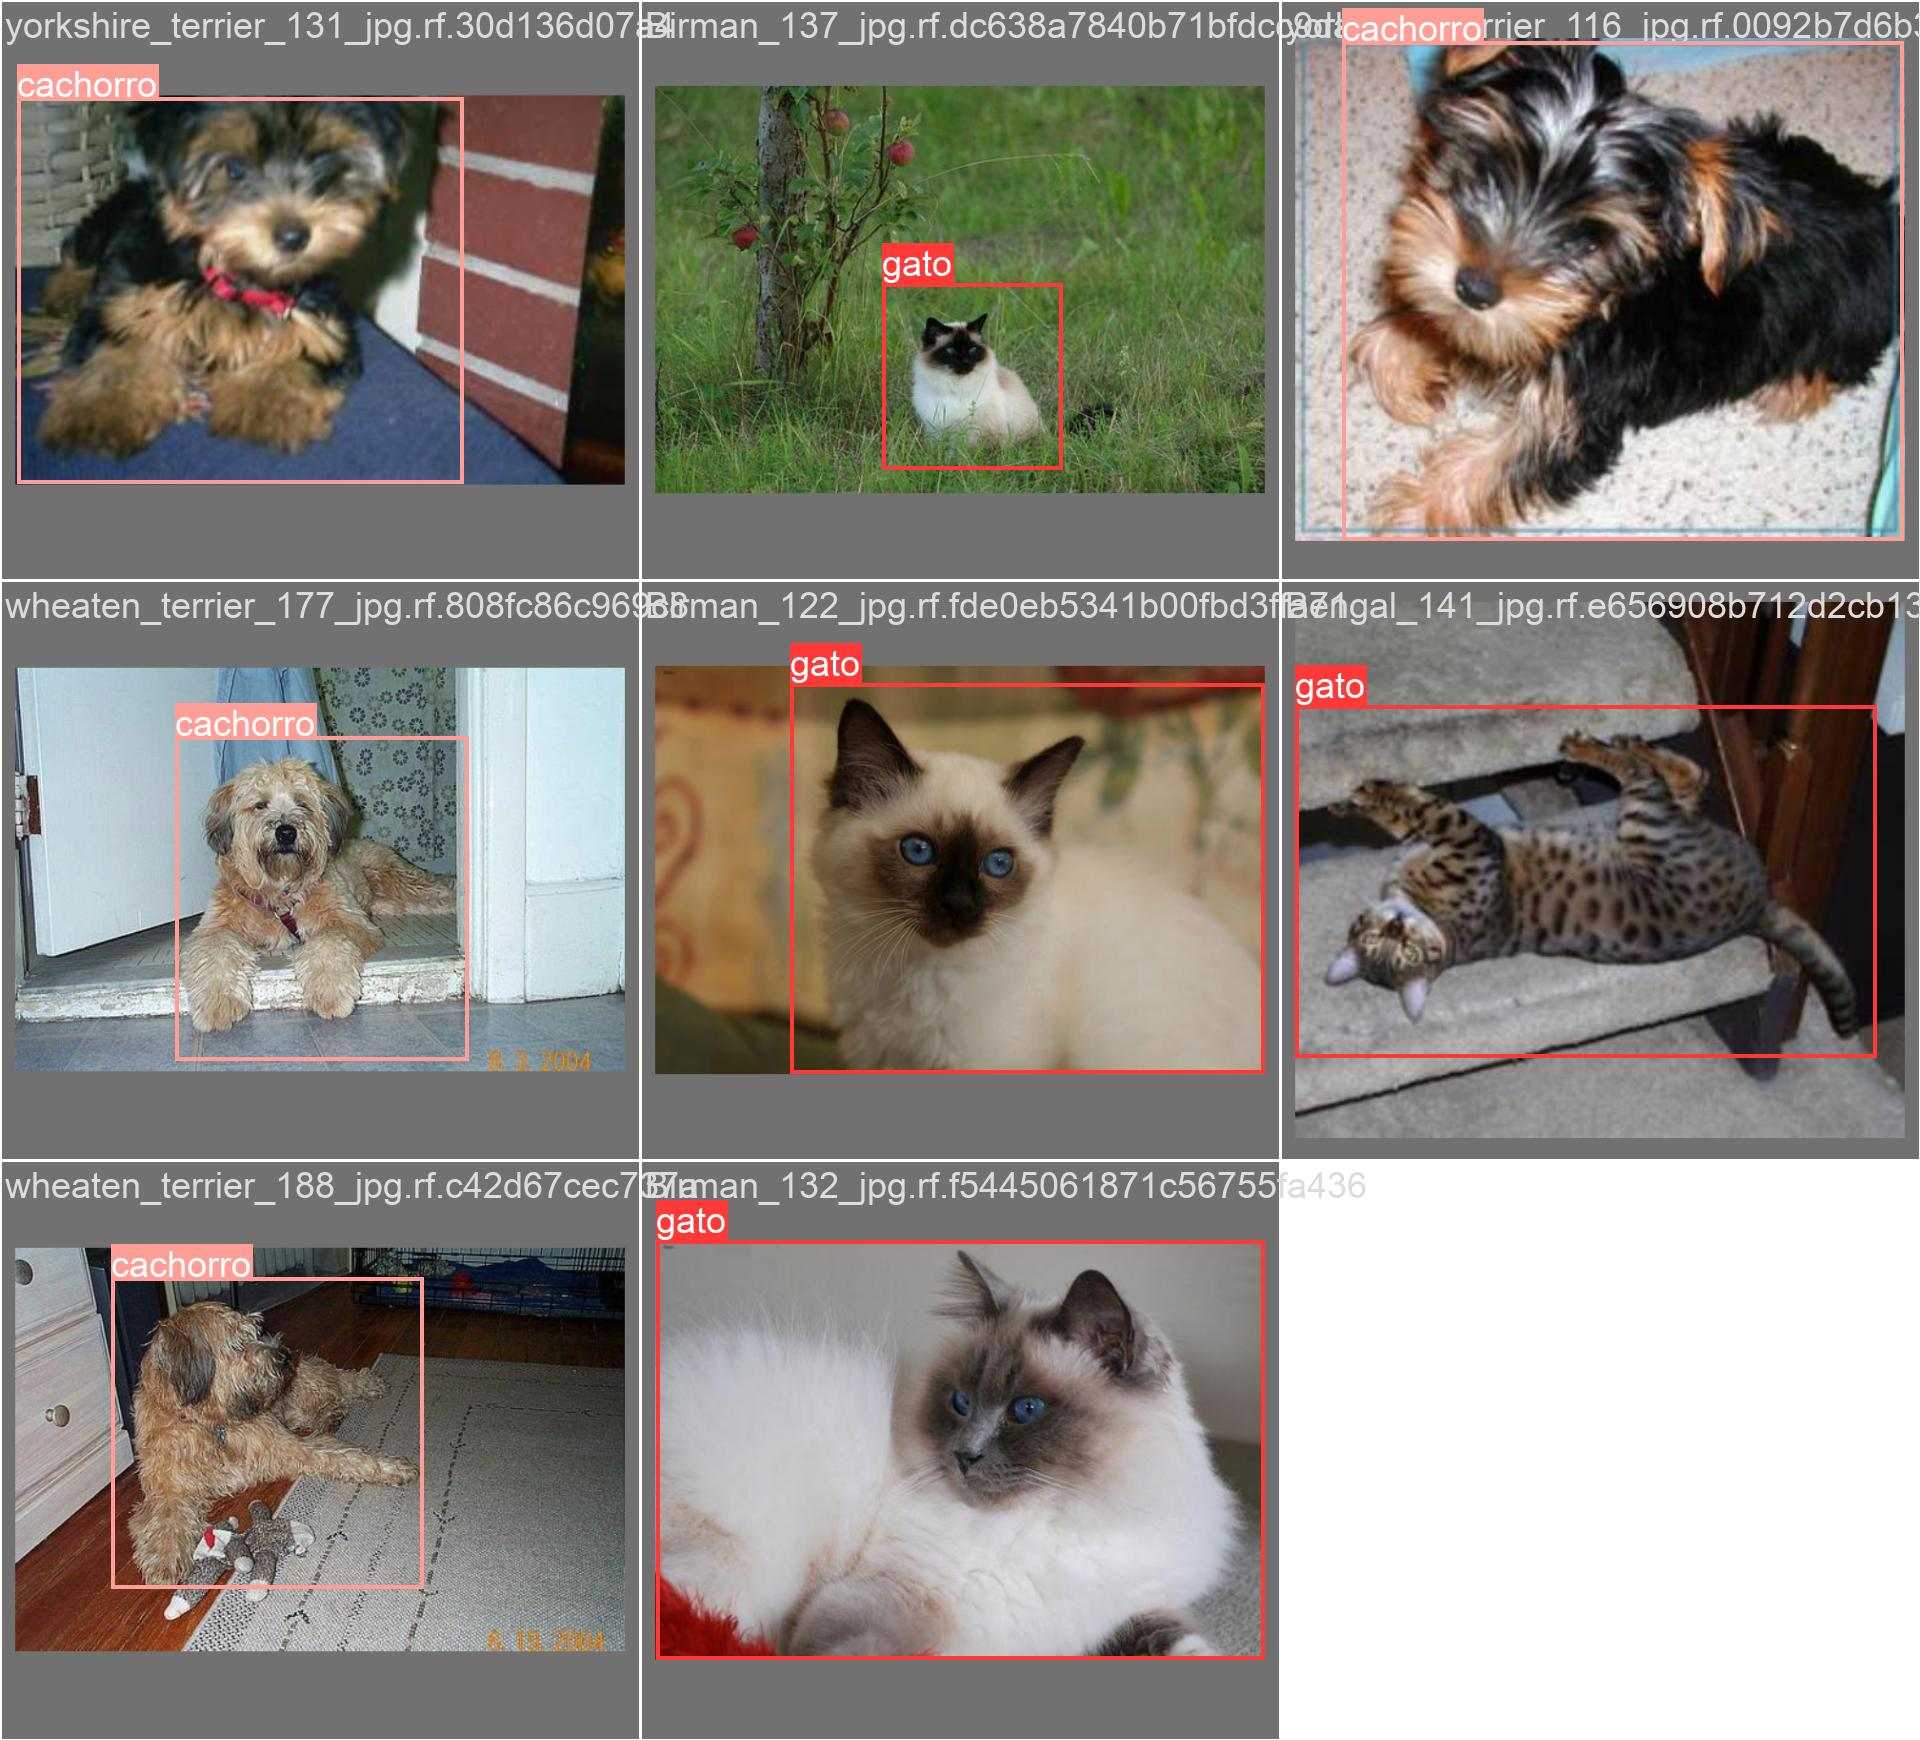


🔍 Validação — Predições (60 épocas)


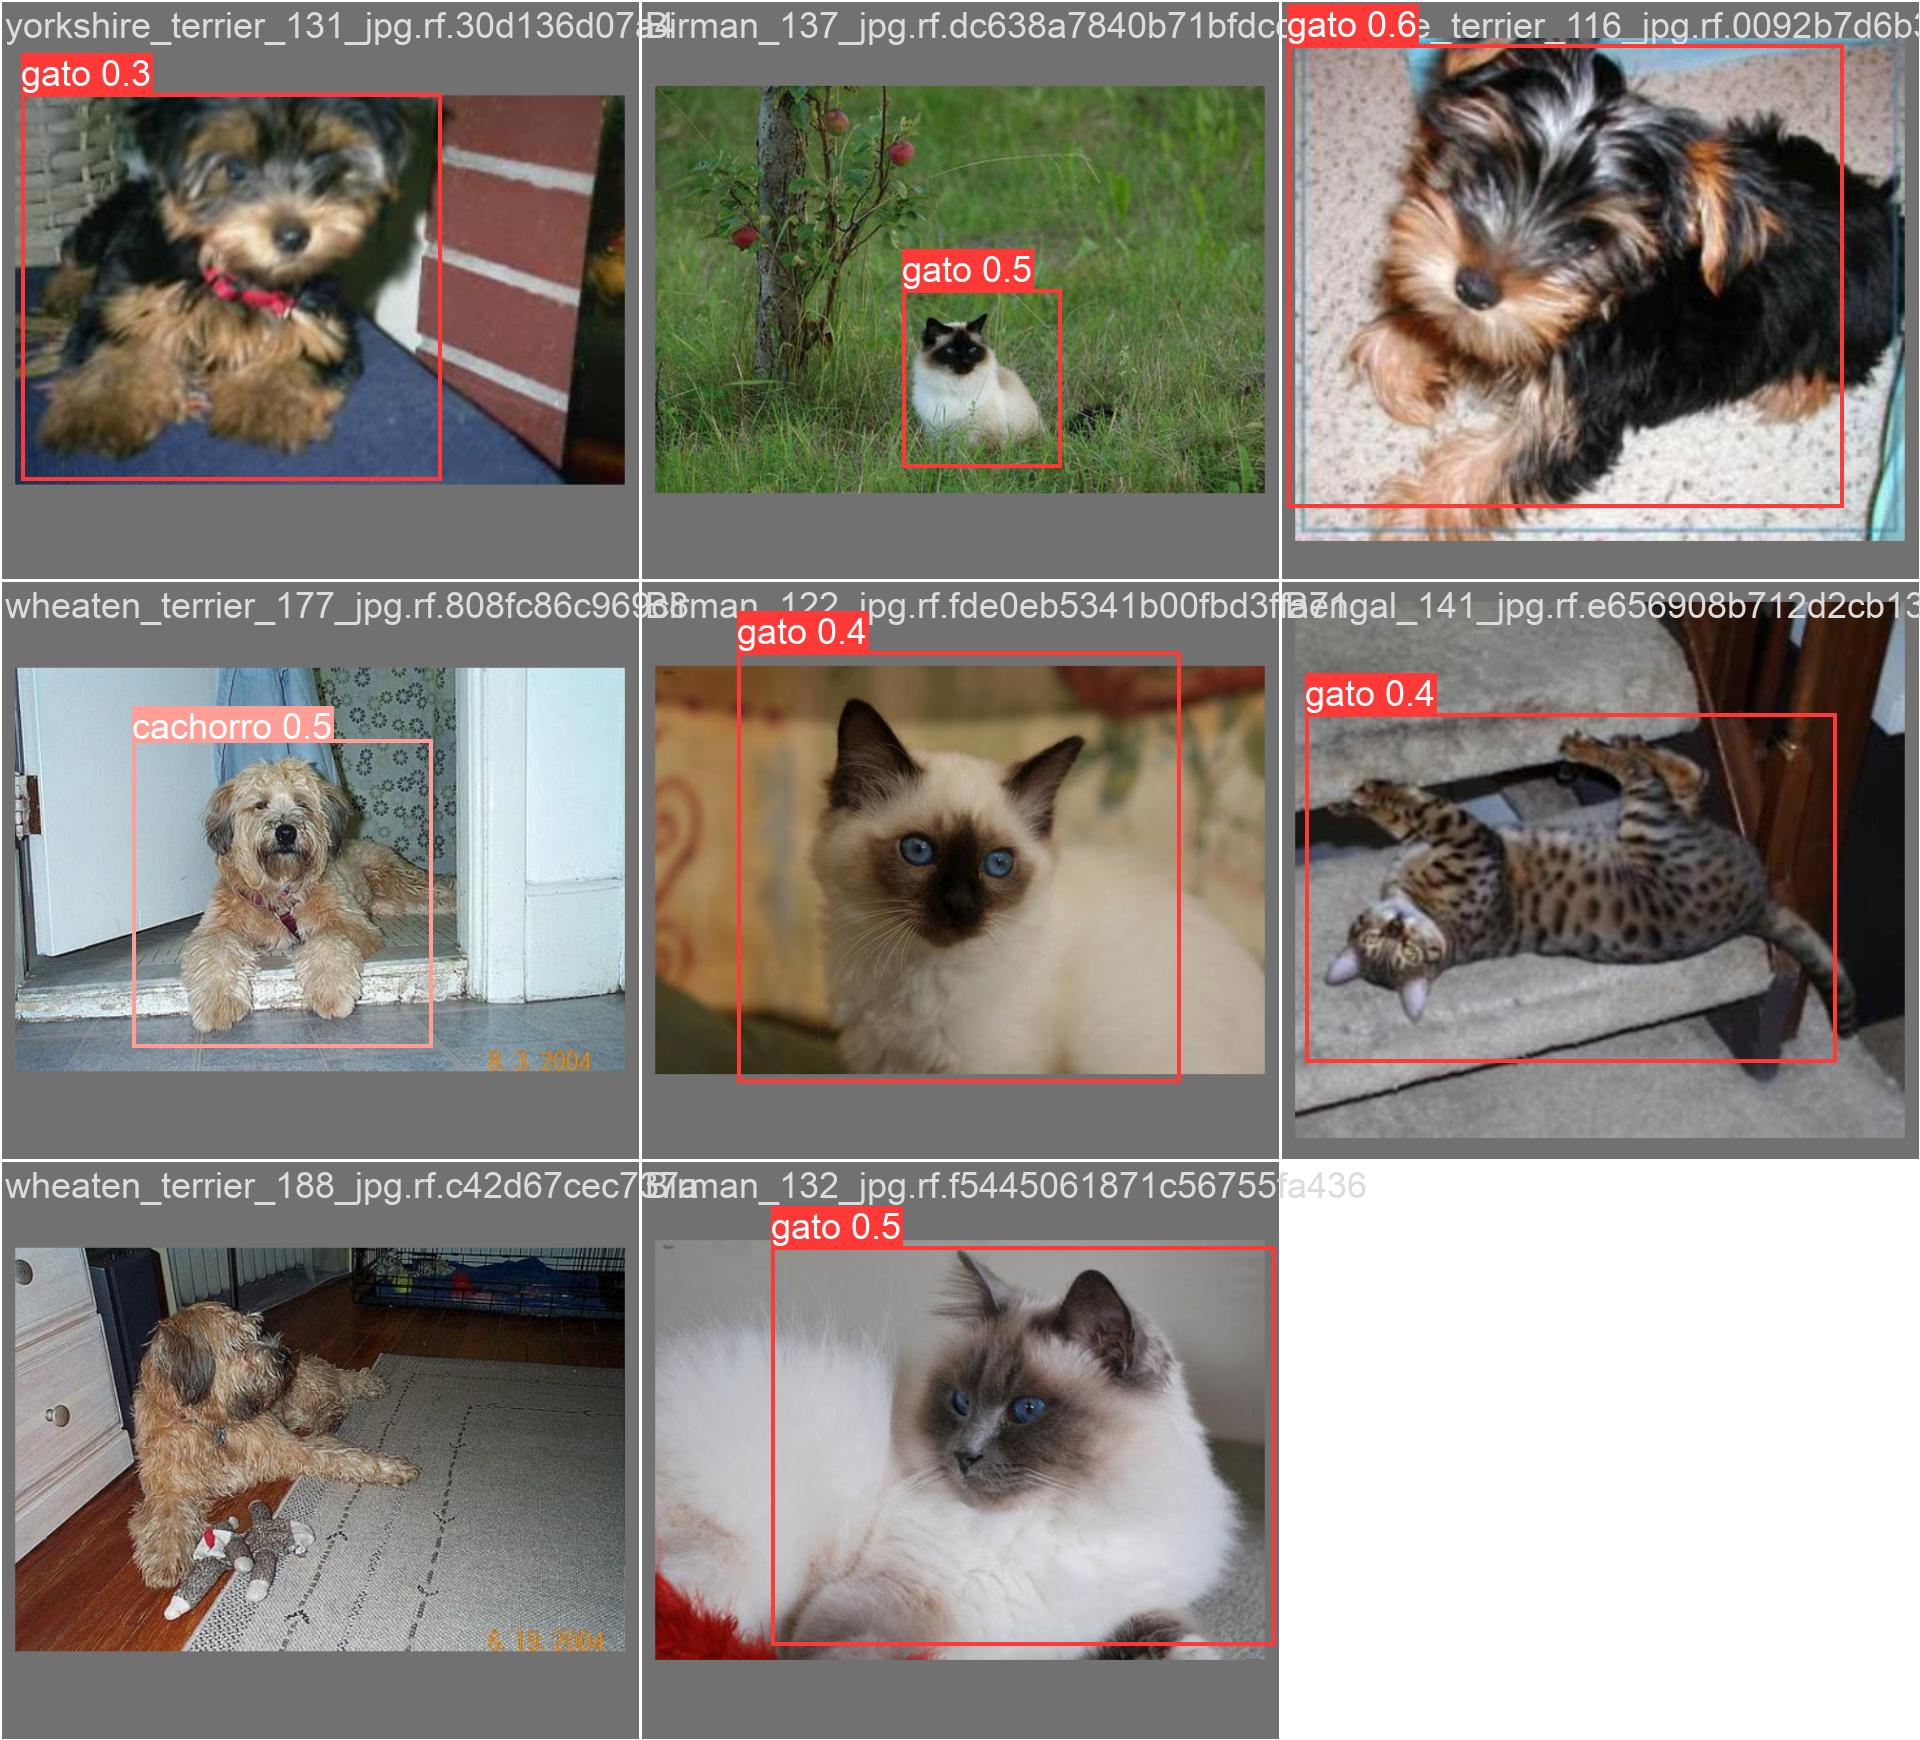

In [ ]:
# Exibe os gráficos do Experimento 2 (60 épocas)
from IPython.display import Image, display
import os

EXP_PATH = '/content/yolov5/runs/train/exp_60epochs'

graficos = [
    ('results.png',           '📈 Evolução das losses e métricas — 60 épocas'),
    ('confusion_matrix.png',  '🎯 Matriz de confusão — 60 épocas'),
    ('PR_curve.png',          '📊 Curva Precision x Recall — 60 épocas'),
    ('F1_curve.png',          '⚖️  Curva F1-Score por threshold — 60 épocas'),
    ('val_batch0_labels.jpg', '✅ Validação — Ground truth'),
    ('val_batch0_pred.jpg',   '🔍 Validação — Predições (60 épocas)'),
]

for arquivo, descricao in graficos:
    caminho = os.path.join(EXP_PATH, arquivo)
    if os.path.exists(caminho):
        print(f"\n{descricao}")
        display(Image(filename=caminho, width=800))
    else:
        print(f"\n⚠️ Arquivo não encontrado: {arquivo}")

### 6.1 Análise dos resultados — Experimento 2 (60 épocas)

#### Métricas finais

| Classe | Imagens | Instâncias | Precision | Recall | mAP@0.5 | mAP@0.5:0.95 |
|--------|---------|------------|-----------|--------|---------|--------------|
| **all** | 8 | 8 | 0.858 | 0.697 | 0.719 | 0.424 |
| gato | 8 | 4 | 0.716 | **1.000** | 0.796 | 0.491 |
| cachorro | 8 | 4 | **1.000** | 0.394 | 0.643 | 0.356 |

#### Evolução das losses ao longo das épocas

Observando o gráfico `results.png`:

- **train/box_loss**, **train/obj_loss** e **train/cls_loss** continuaram caindo até quase o final do treino, atingindo valores muito baixos (cls_loss ~0.003). Isso indica que o modelo continuou se ajustando ao conjunto de treino.
- **val/cls_loss** apresenta o comportamento clássico do **overfitting**: cai até cerca da época 25-30, depois sobe novamente e oscila em valores mais altos. Esse "vale-morro" é a assinatura visual de um modelo que começou a memorizar o treino e perdeu capacidade de generalizar para a validação.
- **mAP@0.5** atinge picos próximos a 0.85 entre as épocas 30-35, e depois oscila em valores menores (~0.7), confirmando que o ponto ótimo de treinamento foi ultrapassado.

#### Matriz de confusão

A matriz mostra um padrão diferente do experimento de 30 épocas:

- **Gato** foi predito corretamente em 100% das instâncias — o modelo passou a detectar todos os gatos.
- **Cachorro** foi predito corretamente em 25% das instâncias e classificado erroneamente como **gato em 50% dos casos**. Outros 25% caíram em `background` (não detectado).
- Diferentemente do treino com 30 épocas (onde não havia confusão entre classes), aqui o modelo passou a confundir **cachorro com gato** — sintoma típico de um modelo que aprendeu padrões específicos demais.

#### Predições visuais

A inspeção das imagens de validação revela um comportamento contraditório à primeira vista:

- O modelo **detecta mais objetos** que com 30 épocas — inclusive casos difíceis como o gato Bengal de bruços, que antes não era detectado.
- Porém, comete **mais erros de classificação** — por exemplo, classificando um Yorkshire Terrier (cachorro) como "gato 0.3".

Esse comportamento é coerente com a hipótese de overfitting: o modelo ficou "mais ousado" nas predições, mas usou padrões aprendidos do treino que não se generalizam corretamente para imagens novas.

### 6.2 Comparativo entre os dois experimentos

| Métrica (validação) | 30 épocas | 60 épocas | Variação |
|---------------------|-----------|-----------|----------|
| Precision (all) | 0.752 | 0.858 | ↑ +14% |
| Recall (all) | 0.741 | 0.697 | ↓ -6% |
| **mAP@0.5 (all)** | **0.901** | 0.719 | ↓ -20% |
| **mAP@0.5:0.95 (all)** | **0.511** | 0.424 | ↓ -17% |
| mAP@0.5 (gato) | 0.808 | 0.796 | ≈ |
| mAP@0.5 (cachorro) | **0.995** | 0.643 | ↓ -35% |
| Tempo de treino | ~1.4 min | ~2.8 min | ↑ +100% |

### 6.3 Conclusão sobre o impacto das épocas

Contrariando a intuição inicial de que "mais épocas → melhor modelo", o experimento mostrou que **30 épocas produziram melhores resultados que 60 épocas** neste cenário. Os principais fatores observados:

1. **Overfitting evidente**: a `val/cls_loss` aumenta após ~30 épocas, enquanto a `train/cls_loss` continua caindo. Esse descolamento entre treino e validação é a definição clássica de overfitting.

2. **Trade-off entre detectar e classificar**: o modelo de 60 épocas detecta mais objetos (Recall do gato saltou para 100%), mas erra mais na classe correta (Recall do cachorro caiu para 39%, com confusões cachorro→gato). O modelo de 30 épocas é mais "conservador" e equilibrado.

3. **Causa raiz: dataset pequeno**. Com apenas 64 imagens de treino e alta variabilidade intra-classe (várias raças por animal), o modelo "decora" características muito específicas quando recebe muitas épocas. Mais dados seriam o remédio mais eficaz, seguidos de técnicas de regularização adicionais.

4. **Princípio aprendido**:

**Muitas épocas + Poucos dados = Overfitting**

> O número ótimo de épocas não é "o maior possível", mas aquele que maximiza a performance em dados não vistos. Aumentar épocas só ajuda enquanto a `val_loss` continuar diminuindo.

### 6.4 Modelo escolhido para a etapa de teste

Com base nos resultados, o modelo treinado com **30 épocas (`exp_30epochs_corrigido`)** será utilizado para a etapa de teste, por apresentar:
- Maior `mAP@0.5` (0.901 vs 0.719)
- Maior `mAP@0.5:0.95` (0.511 vs 0.424)
- Melhor equilíbrio entre as duas classes
- Tempo de treino menor

---

## 7. Etapa de Teste

Nesta etapa, aplicamos o modelo escolhido (30 épocas, dataset corrigido) nas 8
imagens da pasta `test/` — imagens **não rotuladas** que o modelo nunca viu
durante o treino ou validação.

O objetivo é avaliar visualmente a qualidade das predições em dados completamente
novos, simulando como o sistema funcionaria em produção.

### Como funciona

Usaremos o script `detect.py` do YOLOv5, que:

1. Carrega os pesos do melhor modelo treinado (`best.pt`)
2. Processa cada imagem da pasta de teste
3. Desenha as bounding boxes detectadas com as classes preditas e níveis de confiança
4. Salva as imagens anotadas em `runs/detect/exp_test/`

### Parâmetros

- **--weights**: caminho para `best.pt` do experimento de 30 épocas
- **--source**: pasta com as imagens de teste
- **--img**: 640 (mesmo tamanho usado no treino)
- **--conf**: 0.25 (threshold de confiança mínima para considerar uma detecção)

In [ ]:
# Aplica o modelo treinado nas imagens de teste
%cd /content/yolov5

!python detect.py \
  --weights runs/train/exp_30epochs_corrigido/weights/best.pt \
  --source /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test \
  --img 640 \
  --conf 0.25 \
  --name exp_test \
  --project runs/detect

/content/yolov5
detect: weights=['runs/train/exp_30epochs_corrigido/weights/best.pt'], source=/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp_test, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test/boxer_113_jpg.rf.df390450aa9acf6f4d6f9b860f9b91b8.jpg: 640x448 (no detections), 53.2ms
image 2/8 /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test/chi

In [ ]:
import os

TEST_PATH = '/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test'
TRAIN_PATH = '/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/train'
VAL_PATH = '/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/val'

# Lista o que tem na pasta test
test_files = sorted(os.listdir(TEST_PATH))
gatos = [f for f in test_files if f[0].isupper()]
cachorros = [f for f in test_files if not f[0].isupper()]

print(f"=== Pasta test/ ({len(test_files)} arquivos) ===")
print(f"  🐱 Gatos: {len(gatos)}")
for g in gatos:
    print(f"      - {g}")
print(f"  🐶 Cachorros: {len(cachorros)}")
for c in cachorros:
    print(f"      - {c}")

# Verifica se há sobreposição com treino/validação (data leakage)
train_files = set(os.listdir(TRAIN_PATH))
val_files = set(os.listdir(VAL_PATH))

leak_train = [f for f in test_files if f in train_files]
leak_val = [f for f in test_files if f in val_files]

print(f"\n=== Verificação de data leakage ===")
if not leak_train and not leak_val:
    print("✅ Nenhuma imagem de teste está duplicada em train/ ou val/")
else:
    if leak_train:
        print(f"⚠️ ATENÇÃO: {len(leak_train)} imagem(ns) de teste também estão no treino:")
        for f in leak_train:
            print(f"      - {f}")
    if leak_val:
        print(f"⚠️ ATENÇÃO: {len(leak_val)} imagem(ns) de teste também estão na validação:")
        for f in leak_val:
            print(f"      - {f}")

=== Pasta test/ (8 arquivos) ===
  🐱 Gatos: 4
      - Abyssinian_174_jpg.rf.e2cf9b76cf12896d0a5672ad19fbd519.jpg
      - British_Shorthair_103_jpg.rf.ea9c679aa43c2bcc2dd74e51588f0c5e.jpg
      - Siamese_164_jpg.rf.ef30fae7ee22d7922dab34d52deb9f00.jpg
      - Sphynx_104_jpg.rf.e7cb65a6212f786130b1bf1bf6d114a1.jpg
  🐶 Cachorros: 4
      - boxer_113_jpg.rf.df390450aa9acf6f4d6f9b860f9b91b8.jpg
      - chihuahua_145_jpg.rf.da13f36571b4a099d0e764ef191a4a69.jpg
      - english_cocker_spaniel_17_jpg.rf.f22312874dde3803847df16bcfe12f83.jpg
      - staffordshire_bull_terrier_17_jpg.rf.2bb21bc61ce9975900a251e9210680d9.jpg

=== Verificação de data leakage ===
✅ Nenhuma imagem de teste está duplicada em train/ ou val/


In [ ]:
# Aplica o modelo treinado (30 épocas, dataset corrigido) nas imagens de teste
%cd /content/yolov5

!python detect.py \
  --weights runs/train/exp_30epochs_corrigido/weights/best.pt \
  --source /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test \
  --img 640 \
  --conf 0.25 \
  --name exp_test_final \
  --project runs/detect

/content/yolov5
detect: weights=['runs/train/exp_30epochs_corrigido/weights/best.pt'], source=/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp_test_final, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test/Abyssinian_174_jpg.rf.e2cf9b76cf12896d0a5672ad19fbd519.jpg: 512x640 (no detections), 33.8ms
image 2/8 /content/drive/MyDrive/FIAP/fase06-cap01/dataset/imag

=== Predições do modelo nas imagens de teste ===

📸 Abyssinian_174_jpg.rf.e2cf9b76cf12896d0a5672ad19fbd519.jpg


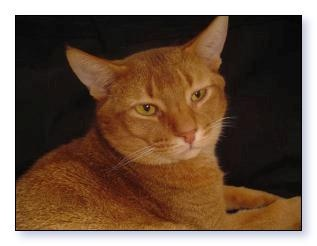


📸 British_Shorthair_103_jpg.rf.ea9c679aa43c2bcc2dd74e51588f0c5e.jpg


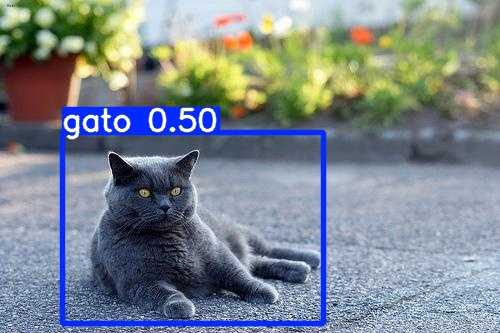


📸 Siamese_164_jpg.rf.ef30fae7ee22d7922dab34d52deb9f00.jpg


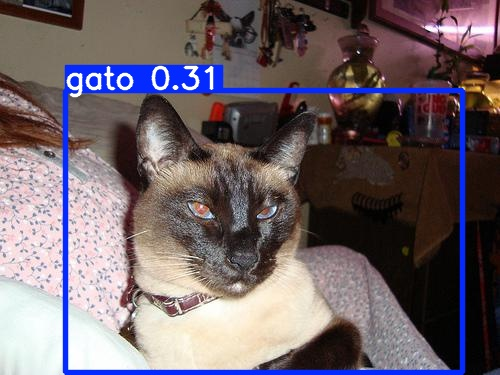


📸 Sphynx_104_jpg.rf.e7cb65a6212f786130b1bf1bf6d114a1.jpg


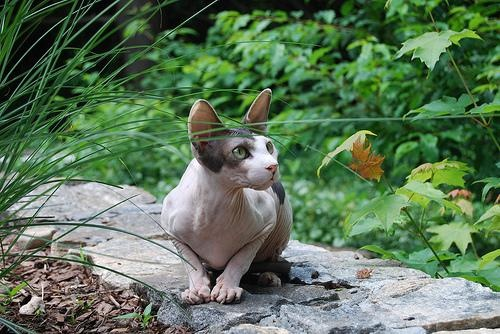


📸 boxer_113_jpg.rf.df390450aa9acf6f4d6f9b860f9b91b8.jpg


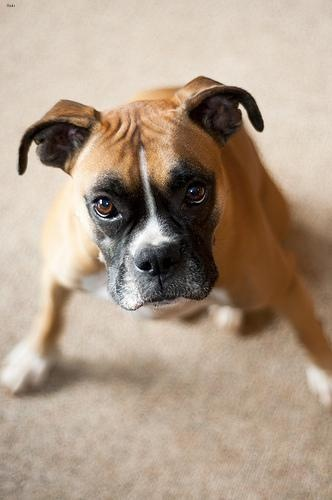


📸 chihuahua_145_jpg.rf.da13f36571b4a099d0e764ef191a4a69.jpg


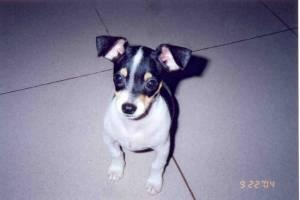


📸 english_cocker_spaniel_17_jpg.rf.f22312874dde3803847df16bcfe12f83.jpg


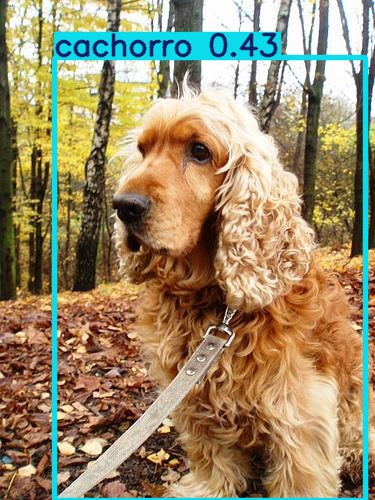


📸 staffordshire_bull_terrier_17_jpg.rf.2bb21bc61ce9975900a251e9210680d9.jpg


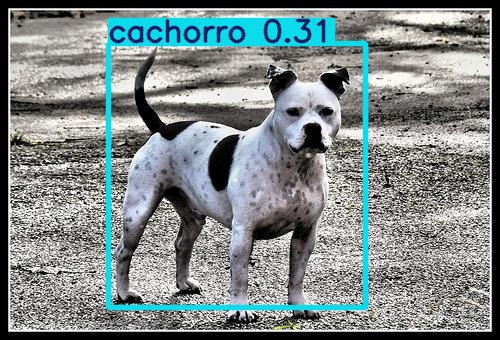

In [ ]:
# Exibe as imagens de teste com as predições do modelo
from IPython.display import Image, display
import os

PRED_PATH = '/content/yolov5/runs/detect/exp_test_final2'

print("=== Predições do modelo nas imagens de teste ===\n")

imagens = sorted([f for f in os.listdir(PRED_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))])

for img in imagens:
    caminho = os.path.join(PRED_PATH, img)
    print(f"📸 {img}")
    display(Image(filename=caminho, width=600))
    print()

### 7.1 Análise dos Resultados de Teste

O modelo treinado com 30 épocas (`exp_30epochs_corrigido`) foi aplicado às 8 imagens
da pasta `test/`, contendo 4 gatos e 4 cachorros de raças não vistas pelo modelo durante
o treinamento ou validação.

#### Resumo das predições

| # | Imagem | Animal real | Predição do modelo | Confiança | Resultado |
|---|--------|-------------|--------------------|-----------|-----------|
| 1 | Abyssinian_174 | 🐱 Gato | (não detectado) | — | ❌ |
| 2 | British_Shorthair_103 | 🐱 Gato | gato | 0.50 | ✅ |
| 3 | Siamese_164 | 🐱 Gato | gato | 0.31 | ✅ |
| 4 | Sphynx_104 | 🐱 Gato | (não detectado) | — | ❌ |
| 5 | boxer_113 | 🐶 Cachorro | (não detectado) | — | ❌ |
| 6 | chihuahua_145 | 🐶 Cachorro | (não detectado) | — | ❌ |
| 7 | english_cocker_spaniel_17 | 🐶 Cachorro | cachorro | 0.43 | ✅ |
| 8 | staffordshire_bull_terrier_17 | 🐶 Cachorro | cachorro | 0.31 | ✅ |

#### Métricas observadas

- **Taxa de detecção:** 4/8 (50%)
- **Acurácia de classificação (entre os detectados):** 4/4 (100%)
- **Confiança média (nas detecções):** ~0.39

### 7.2 Análise crítica

#### Pontos fortes

1. **Quando o modelo detecta, acerta a classe.** Em 100% das detecções, a classificação (gato vs cachorro) foi correta. Não houve confusão entre as duas classes — sintoma de que o modelo aprendeu **bem a diferenciar** gato de cachorro.
2. **Generalização entre raças.** O modelo identificou corretamente raças que não estavam no treino (Siamese, British Shorthair como gatos; Cocker Spaniel, Staffordshire Bull Terrier como cachorros), demonstrando alguma capacidade de abstração além das raças específicas vistas.
3. **Bounding boxes bem ajustadas** nas detecções corretas, cobrindo o animal por completo.

#### Limitações observadas

1. **Alto número de "missed detections" (50%).** O principal modo de falha do modelo é deixar de detectar o animal, e não confundir as classes.
2. **Confiança baixa nas predições** (entre 0.31 e 0.50). Mesmo nos acertos, o modelo não está "muito seguro" — sinal típico de treino com poucos dados.
3. **Casos atípicos quebram o modelo.** As 4 imagens não detectadas têm padrões claros que destoam do conjunto de treino:

| Imagem não detectada | Causa provável |
|---------------------|----------------|
| Abyssinian | Foto escura, fundo preto, baixo contraste |
| Sphynx | Gato sem pelo — aparência radicalmente diferente do que o modelo viu |
| Boxer | Foto em closeup extremo, apenas o rosto, ângulo de cima |
| Chihuahua | Imagem antiga, desfocada, baixa qualidade |

### 7.3 Conclusões para o cenário FarmTech Solutions

Como integrante do time de desenvolvedores apresentando o projeto a um cliente fictício
da FarmTech, podemos resumir o sistema da seguinte forma:

> **O sistema funciona bem em condições "normais" — fotos claras, animal visível por
> completo, em ambiente típico — com 100% de acurácia de classificação quando há
> detecção. Porém, apresenta dificuldades em casos atípicos: aparências fora do padrão,
> closeups extremos, fotos antigas ou de baixa qualidade.**

#### Recomendações para evolução do modelo em produção

1. **Aumentar significativamente o dataset de treino** — mais imagens, mais raças, mais variedade de ângulos e iluminação. Esta é a recomendação mais impactante.
2. **Aplicar técnicas de data augmentation** mais agressivas durante o treino (variações de brilho, contraste, ruído, recortes) para aumentar a robustez.
3. **Experimentar arquiteturas maiores** do YOLOv5 (yolov5m, yolov5l) caso o aumento do dataset não seja suficiente.
4. **Definir um threshold de confiança apropriado** para o caso de uso. Para aplicações onde "deixar de detectar" é pior que "detectar errado", reduzir o threshold; para o oposto, aumentar.
5. **Considerar um pipeline de qualidade de imagem** antes da inferência, para descartar ou pré-processar imagens muito desfocadas ou escuras.

---

# 🎯 Entrega 2 — Comparação com Outras Abordagens

Conforme solicitado pelo enunciado da Fase 6, esta seção implementa e avalia outras
abordagens de visão computacional sobre o mesmo dataset construído na Entrega 1,
permitindo uma análise comparativa crítica.

## Abordagens implementadas

1. **YOLO customizada** — implementada na Entrega 1 (transfer learning a partir do `yolov5s.pt` com treino dos nossos dados)
2. **YOLO padrão** — usa o modelo `yolov5s.pt` pré-treinado no COCO **sem nenhum treino adicional**, para detectar as classes nativas (cat, dog) do dataset COCO
3. **CNN treinada do zero** — rede convolucional pequena, construída e treinada do zero em TensorFlow/Keras

## Abordagem extra (bônus exploratório)

4. **Transfer Learning com MobileNetV2** — uso de uma rede grande pré-treinada na ImageNet, com ajuste fino na nossa base. Implementação parcial da segunda opção do "Ir Além", limitada apenas ao Transfer Learning (não inclui a etapa de segmentação).

## Critérios de comparação

Ao final, todas as abordagens serão comparadas em quatro dimensões:

- **Facilidade de uso/integração**
- **Precisão do modelo**
- **Tempo de treinamento/customização**
- **Tempo de inferência**

## 8. YOLO Padrão (sem customização)

O modelo `yolov5s.pt` já vem pré-treinado no dataset **COCO**, que contém 80 classes
de objetos comuns — incluindo `cat` e `dog`. Isso significa que, para o nosso problema
específico (gato vs cachorro), o modelo padrão já tem capacidade de detecção sem
precisar de treino adicional.

A questão a ser avaliada é: **um modelo genérico, treinado em um dataset gigantesco e
diverso, performa melhor ou pior que um modelo customizado treinado em um dataset
pequeno e específico?**

### Diferenças importantes

| Aspecto | YOLO customizada (Entrega 1) | YOLO padrão (Entrega 2) |
|---------|------------------------------|-------------------------|
| Pesos | `best.pt` (treinado nas 64 imgs) | `yolov5s.pt` (COCO, ~330k imgs) |
| Classes | `gato`, `cachorro` (2) | 80 classes COCO |
| Treino adicional | 30 épocas | nenhum |
| Tempo de preparação | ~1.4 min | 0 (nada a treinar) |

### Como avaliar

Vamos rodar o `detect.py` com `yolov5s.pt` direto, sem nenhum treino, nas mesmas 8
imagens de teste usadas na Entrega 1, e comparar visualmente os resultados.

In [ ]:
# Aplica o modelo YOLOv5s pré-treinado (COCO) nas imagens de teste
%cd /content/yolov5

!python detect.py \
  --weights yolov5s.pt \
  --source /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test \
  --img 640 \
  --conf 0.25 \
  --name exp_test_yolo_padrao \
  --project runs/detect

/content/yolov5
detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp_test_yolo_padrao, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/8 /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test/Abyssinian_174_jpg.rf.e2cf9b76cf12896d0a5672ad19fbd519.jpg: 512x640 1 cat, 35.2ms
image 2/8 /content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test/British_Shorthair_103_jpg.rf.ea9c

=== Predições do YOLO PADRÃO (yolov5s.pt - COCO) nas imagens de teste ===

📸 Abyssinian_174_jpg.rf.e2cf9b76cf12896d0a5672ad19fbd519.jpg


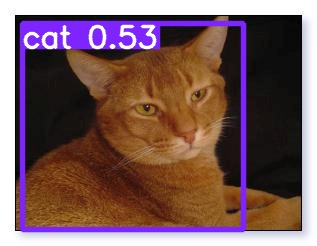


📸 British_Shorthair_103_jpg.rf.ea9c679aa43c2bcc2dd74e51588f0c5e.jpg


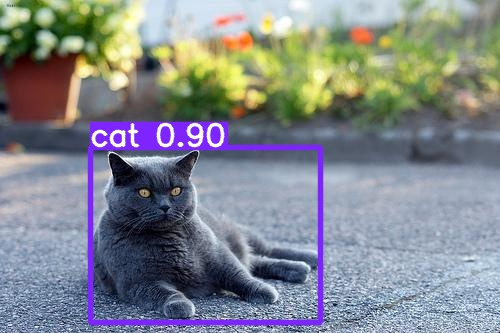


📸 Siamese_164_jpg.rf.ef30fae7ee22d7922dab34d52deb9f00.jpg


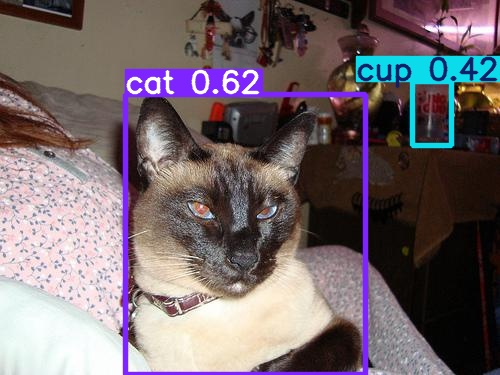


📸 Sphynx_104_jpg.rf.e7cb65a6212f786130b1bf1bf6d114a1.jpg


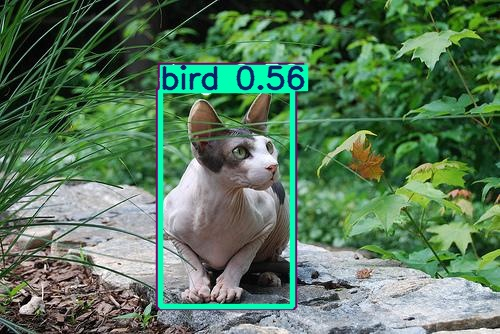


📸 boxer_113_jpg.rf.df390450aa9acf6f4d6f9b860f9b91b8.jpg


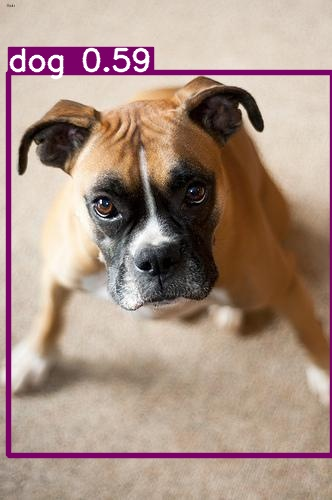


📸 chihuahua_145_jpg.rf.da13f36571b4a099d0e764ef191a4a69.jpg


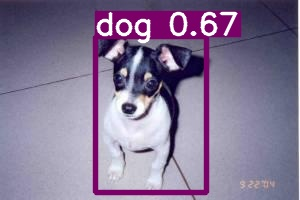


📸 english_cocker_spaniel_17_jpg.rf.f22312874dde3803847df16bcfe12f83.jpg


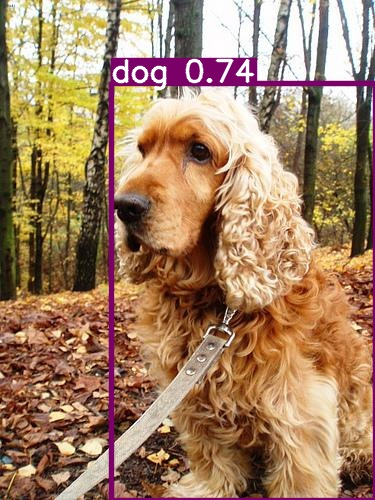


📸 staffordshire_bull_terrier_17_jpg.rf.2bb21bc61ce9975900a251e9210680d9.jpg


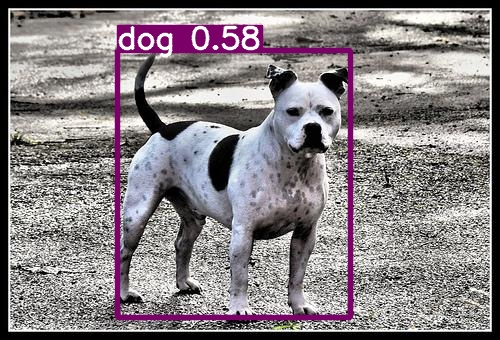

In [ ]:
# Exibe as predições do YOLO padrão (COCO) nas imagens de teste
from IPython.display import Image, display
import os

PRED_PATH = '/content/yolov5/runs/detect/exp_test_yolo_padrao'

print("=== Predições do YOLO PADRÃO (yolov5s.pt - COCO) nas imagens de teste ===\n")

imagens = sorted([f for f in os.listdir(PRED_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))])

for img in imagens:
    caminho = os.path.join(PRED_PATH, img)
    print(f"📸 {img}")
    display(Image(filename=caminho, width=600))
    print()

### 8.1 Análise dos resultados — YOLO padrão

#### Resumo das predições

| # | Imagem | Animal real | YOLO padrão (COCO) | Confiança | Resultado |
|---|--------|-------------|--------------------|-----------|-----------|
| 1 | Abyssinian | 🐱 Gato | cat | 0.53 | ✅ |
| 2 | British_Shorthair | 🐱 Gato | cat | **0.90** | ✅ |
| 3 | Siamese | 🐱 Gato | cat (+ cup 0.42) | 0.62 | ✅ |
| 4 | Sphynx | 🐱 Gato | bird + dog | 0.56 | ❌ |
| 5 | boxer | 🐶 Cachorro | dog | 0.59 | ✅ |
| 6 | chihuahua | 🐶 Cachorro | dog | 0.67 | ✅ |
| 7 | english_cocker_spaniel | 🐶 Cachorro | dog | 0.74 | ✅ |
| 8 | staffordshire_bull_terrier | 🐶 Cachorro | dog | 0.58 | ✅ |

**Métricas observadas:**
- Taxa de detecção: 8/8 (100%)
- Acertos: 7/8 (87,5%)
- Falsos positivos extras: 2 (cup no Siamese, bird no Sphynx)
- Confiança média (acertos): ~0.66

#### Comparativo direto: YOLO padrão vs YOLO customizada

| Métrica | YOLO customizada (Entrega 1) | YOLO padrão (COCO) |
|---------|------------------------------|--------------------|
| Detecções | 4/8 (50%) | 8/8 (100%) |
| Classificações corretas | 4/8 (50%) | 7/8 (87,5%) |
| Confiança média | ~0.39 | ~0.66 |
| Tempo de preparação | ~1.4 min de treino | 0 (sem treino) |

#### Por que o YOLO padrão venceu neste cenário

O modelo `yolov5s.pt` foi treinado no **dataset COCO**, que contém aproximadamente
330 mil imagens distribuídas em 80 categorias — incluindo `cat` e `dog`. Esse volume e
diversidade de dados produz um extrator de features extremamente robusto, capaz de
generalizar para diversas raças, ângulos, iluminações e contextos.

Em contraste, a YOLO customizada foi treinada com apenas **64 imagens**, limitando
significativamente sua capacidade de generalização — apesar do "transfer learning" inicial
a partir do mesmo `yolov5s.pt`, o re-treino em dataset pequeno acabou prejudicando o que
o modelo já sabia.

#### Quando faria sentido usar a YOLO customizada

A customização da YOLO seria a melhor escolha em cenários como:

1. **Domínio específico não coberto pelo COCO**: detectar uma peça mecânica específica, uma planta agrícola particular, um modelo específico de produto, etc.
2. **Granularidade maior que o COCO oferece**: distinguir raças específicas de gato (Persian vs Siamese), tipos de defeito em produção industrial, etc.
3. **Classes muito particulares**: logos de marca, equipamentos específicos da empresa, etc.

Para a tarefa "gato vs cachorro", o COCO já cobre bem demais — a customização não trouxe benefício e até prejudicou em parte.

#### Curiosidade: o caso do Sphynx → "bird"

Um dos achados mais interessantes foi a classificação do Sphynx (gato sem pelo) como
**"bird" (0.56)** pelo YOLO padrão. Visualmente, faz sentido a confusão: orelhas grandes
e pontudas, postura agachada, ausência de pelo e patas visíveis criam uma silhueta que
lembra um filhote de ave. Esse caso ilustra que **mesmo modelos massivos têm limitações
em exemplos extremos** que se desviam muito do prototípico de uma classe.

## 9. CNN Treinada do Zero

A terceira abordagem implementa uma **Rede Neural Convolucional (CNN)** treinada **do zero** — sem usar qualquer modelo pré-treinado. Esta abordagem foi estudada no Capítulo 9 do material da Fase 6 ("Desbravando o Deep Learning: Primeiros Passos com CNN").

### Diferença fundamental: detecção vs classificação

Antes de implementar, é importante destacar uma diferença conceitual entre as abordagens:

| Aspecto | YOLO (customizada e padrão) | CNN do zero |
|---------|------------------------------|-------------|
| **Tarefa** | Detecção de objetos | Classificação de imagens |
| **Saída** | Bounding box + classe + confiança | Apenas classe + confiança |
| **O que faz** | "Onde está o objeto e o que é?" | "A imagem é de quê?" |
| **Pressuposto** | A imagem pode ter múltiplos objetos | A imagem inteira é de uma classe |

A CNN não desenha caixas — ela apenas responde "esta imagem é de gato ou cachorro?". Por isso, a comparação direta com a YOLO precisa considerar essa diferença de natureza.

### Arquitetura da CNN

Vamos construir uma rede pequena, simples, com a seguinte estrutura:

1. **Camadas convolucionais (Conv2D + MaxPooling)** — extraem features visuais hierárquicas (bordas → texturas → padrões → conceitos)
2. **Camada de flatten** — transforma o mapa de features em vetor
3. **Camadas densas (fully connected)** — combinam features para classificação final
4. **Camada de saída softmax** — produz probabilidades para cada classe

A rede será treinada totalmente a partir de pesos aleatórios, sem usar conhecimento prévio de outras redes. Isso permite avaliar o quanto **uma arquitetura simples consegue aprender sozinha com nosso dataset pequeno**.

### Por que precisamos reorganizar o dataset

A CNN espera os dados num formato diferente do YOLO. Enquanto o YOLO usa imagens misturadas com arquivos `.txt` de coordenadas, a CNN espera **uma pasta por classe**:

    classification_dataset/
    ├── train/
    │   ├── gato/         ← todas as imagens de gato aqui
    │   └── cachorro/     ← todas as imagens de cachorro aqui
    └── val/
        ├── gato/
        └── cachorro/

O TensorFlow consegue inferir automaticamente a classe de cada imagem pelo **nome da pasta em que ela está**. Por isso, antes de treinar, vamos reorganizar nossas imagens nessa estrutura — aproveitando as mesmas imagens da Entrega 1 (treino + validação), agora agrupadas por classe.

### Pipeline da seção

1. Reorganizar as imagens em pastas por classe
2. Carregar e pré-processar os dados (redimensionamento + normalização)
3. Construir a arquitetura da CNN
4. Treinar o modelo
5. Avaliar nas imagens de validação
6. Testar em imagens novas
7. Comparar com YOLO

### Hipótese a ser testada

> Uma CNN simples treinada do zero em apenas 64 imagens consegue performance comparável à de uma YOLO customizada (Entrega 1)? Ou perderá feio para os modelos que partiram de pesos pré-treinados em datasets gigantescos?

A intuição da literatura é que **CNNs do zero precisam de muitos dados** para generalizar bem. Com apenas 64 imagens, é provável que a CNN tenha dificuldade em aprender padrões robustos. Vamos verificar empiricamente.


### 9.1 Reorganização do dataset para classificação

A célula a seguir cria automaticamente uma nova estrutura de pastas adequada para
classificação, copiando as imagens de `train/` e `val/` da estrutura YOLO original
para a estrutura por classe.

A classificação de cada imagem é feita pelo **primeiro caractere do nome do arquivo**:
- Nomes começando com **letra maiúscula** → gato (Abyssinian, Bengal, Birman, etc.)
- Nomes começando com **letra minúscula** → cachorro (american_bulldog, beagle, boxer, etc.)

Esse padrão segue a convenção do dataset Oxford-IIIT Pet, do qual as imagens originais
foram extraídas.

In [ ]:
# Reorganiza as imagens em estrutura por classe (para CNN/Keras)
import os
import shutil

# Caminhos de origem (estrutura YOLO original)
SRC_BASE = '/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images'
SRC_TRAIN = os.path.join(SRC_BASE, 'train')
SRC_VAL = os.path.join(SRC_BASE, 'val')

# Caminhos de destino (estrutura por classe)
DST_BASE = '/content/classification_dataset'
DST_TRAIN_GATO = os.path.join(DST_BASE, 'train', 'gato')
DST_TRAIN_CACHORRO = os.path.join(DST_BASE, 'train', 'cachorro')
DST_VAL_GATO = os.path.join(DST_BASE, 'val', 'gato')
DST_VAL_CACHORRO = os.path.join(DST_BASE, 'val', 'cachorro')

# Limpa qualquer estrutura anterior e cria as pastas novas
if os.path.exists(DST_BASE):
    shutil.rmtree(DST_BASE)

for pasta in [DST_TRAIN_GATO, DST_TRAIN_CACHORRO, DST_VAL_GATO, DST_VAL_CACHORRO]:
    os.makedirs(pasta, exist_ok=True)

def classificar(nome_arquivo):
    """Retorna 'gato' se começar com maiúscula, 'cachorro' caso contrário."""
    return 'gato' if nome_arquivo[0].isupper() else 'cachorro'

def copiar_imagens(origem, destino_gato, destino_cachorro):
    """Copia cada imagem para a pasta da sua classe."""
    contadores = {'gato': 0, 'cachorro': 0}
    for arquivo in os.listdir(origem):
        if arquivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            classe = classificar(arquivo)
            destino = destino_gato if classe == 'gato' else destino_cachorro
            shutil.copy2(os.path.join(origem, arquivo), os.path.join(destino, arquivo))
            contadores[classe] += 1
    return contadores

# Copia imagens de treino
print("📁 Copiando imagens de treino...")
treino_count = copiar_imagens(SRC_TRAIN, DST_TRAIN_GATO, DST_TRAIN_CACHORRO)
print(f"   🐱 Gatos: {treino_count['gato']}")
print(f"   🐶 Cachorros: {treino_count['cachorro']}")

# Copia imagens de validação
print("\n📁 Copiando imagens de validação...")
val_count = copiar_imagens(SRC_VAL, DST_VAL_GATO, DST_VAL_CACHORRO)
print(f"   🐱 Gatos: {val_count['gato']}")
print(f"   🐶 Cachorros: {val_count['cachorro']}")

# Resumo final
print(f"\n✅ Estrutura criada em: {DST_BASE}")
print(f"\n=== Resumo ===")
print(f"Treino:    {treino_count['gato']} gatos + {treino_count['cachorro']} cachorros = {sum(treino_count.values())}")
print(f"Validação: {val_count['gato']} gatos + {val_count['cachorro']} cachorros = {sum(val_count.values())}")

📁 Copiando imagens de treino...
   🐱 Gatos: 32
   🐶 Cachorros: 32

📁 Copiando imagens de validação...
   🐱 Gatos: 4
   🐶 Cachorros: 4

✅ Estrutura criada em: /content/classification_dataset

=== Resumo ===
Treino:    32 gatos + 32 cachorros = 64
Validação: 4 gatos + 4 cachorros = 8


### 9.2 Carregamento e pré-processamento dos dados

Antes de treinar a CNN, vamos:

1. **Carregar as imagens** usando o utilitário `image_dataset_from_directory` do Keras, que lê automaticamente as imagens das pastas e atribui o label baseado no nome da pasta.
2. **Redimensionar todas as imagens para 150x150 pixels** — tamanho menor que acelera o treino e exige menos memória, conforme sugerido no Cap. 09 do material.
3. **Normalizar os pixels** dividindo por 255, fazendo com que os valores fiquem entre 0 e 1 — o que ajuda na convergência da rede.
4. **Aplicar data augmentation** (variações artificiais como rotação, espelhamento e zoom) para aumentar a diversidade do treino e mitigar overfitting.

In [ ]:
# Carregamento e pré-processamento dos dados para a CNN
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

# Parâmetros
IMG_SIZE = (150, 150)  # Tamanho alvo das imagens
BATCH_SIZE = 16        # Tamanho do batch (pequeno por causa do dataset reduzido)
SEED = 42              # Para reprodutibilidade

# Carrega as imagens de treino diretamente das pastas (label = nome da pasta)
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/classification_dataset/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # one-hot encoding (gato=[1,0], cachorro=[0,1])
    seed=SEED,
    shuffle=True
)

# Carrega as imagens de validação
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/classification_dataset/val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED,
    shuffle=False
)

# Identifica e exibe as classes
class_names = train_ds.class_names
print(f"\n✅ Classes detectadas: {class_names}")
print(f"   (Índice 0 = {class_names[0]}, Índice 1 = {class_names[1]})")

# Normaliza as imagens (divide pixels por 255 para ficarem entre 0 e 1)
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Otimização: cache e prefetch para carregar batches em paralelo durante o treino
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\n✅ Dados carregados, normalizados e prontos para o treino.")

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.

✅ Classes detectadas: ['cachorro', 'gato']
   (Índice 0 = cachorro, Índice 1 = gato)

✅ Dados carregados, normalizados e prontos para o treino.


### 9.3 Construção da arquitetura da CNN

A arquitetura segue o modelo didático do Capítulo 9, com 3 blocos convolucionais
seguidos de camadas densas para classificação. A intuição da arquitetura é:

| Camada | Função |
|--------|--------|
| **Conv2D 32 filtros + MaxPooling** | Detecta features básicas (bordas, cantos, gradientes) |
| **Conv2D 64 filtros + MaxPooling** | Detecta features intermediárias (texturas, formas simples) |
| **Conv2D 128 filtros + MaxPooling** | Detecta features de alto nível (partes de objetos) |
| **Flatten** | Achata o mapa de features em vetor unidimensional |
| **Dense 128 + Dropout 0.5** | Combina features para classificação, com regularização |
| **Dense 2 (softmax)** | Saída: probabilidades para gato e cachorro |

#### Justificativa das escolhas

- **Função de ativação ReLU** nas camadas intermediárias — padrão moderno, evita vanishing gradient
- **Softmax na saída** — converte logits em probabilidades que somam 1
- **Dropout 0.5** — desliga aleatoriamente 50% dos neurônios durante o treino, ajudando a combater overfitting (importante por termos só 64 imagens)
- **MaxPooling 2x2** — reduz dimensionalidade e introduz invariância translacional

In [ ]:
# Construção da arquitetura da CNN do zero
from tensorflow.keras import models, layers

cnn_model = models.Sequential([
    # Camada de entrada (definida implicitamente pelas imagens 150x150x3)

    # Bloco convolucional 1: detecta features básicas
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # Bloco convolucional 2: detecta features intermediárias
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloco convolucional 3: detecta features de alto nível
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Achata o mapa de features para vetor unidimensional
    layers.Flatten(),

    # Camada densa intermediária com regularização Dropout
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Combate overfitting desligando 50% dos neurônios

    # Camada de saída: 2 classes (cachorro, gato) com Softmax
    layers.Dense(2, activation='softmax')
])

# Compila o modelo
cnn_model.compile(
    optimizer='adam',                      # Otimizador adaptativo
    loss='categorical_crossentropy',       # Loss padrão para classificação multi-classe
    metrics=['accuracy']                   # Métrica acompanhada durante o treino
)

# Exibe um resumo da arquitetura
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,610 (18.42 MB)

 Trainable params: 4,828,610 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

### 9.4 Treinamento da CNN

A rede será treinada por **até 50 épocas**, com **Early Stopping** ativado: o treino é
interrompido automaticamente se a `val_loss` não melhorar por 10 épocas consecutivas.
Essa técnica (também usada no Cap. 09) previne overfitting e economiza tempo de treino.

Acompanharemos as seguintes métricas:
- **loss / val_loss** — quanto menor, melhor
- **accuracy / val_accuracy** — proporção de acertos no treino e validação

Observar a diferença entre as métricas de treino e validação é essencial para
identificar overfitting (treino muito melhor que validação) ou underfitting (ambos ruins).

In [ ]:
# Treinamento da CNN do zero
import time

# Early stopping para parar o treino quando val_loss parar de melhorar
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,                    # Tolera 10 épocas sem melhora
    restore_best_weights=True       # Restaura os melhores pesos ao parar
)

# Marca o tempo inicial para registrar duração do treino
start_time = time.time()

# Executa o treinamento
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

# Calcula tempo total
training_time = time.time() - start_time
print(f"\n⏱️ Tempo total de treinamento: {training_time:.1f} segundos ({training_time/60:.2f} min)")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 562ms/step - accuracy: 0.4531 - loss: 1.0485 - val_accuracy: 0.5000 - val_loss: 0.6906
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6693 - val_accuracy: 0.6250 - val_loss: 0.6927
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5625 - loss: 0.6733 - val_accuracy: 0.5000 - val_loss: 0.6997
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6562 - loss: 0.6385 - val_accuracy: 0.6250 - val_loss: 0.7057
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7344 - loss: 0.5656 - val_accuracy: 0.6250 - val_loss: 0.7413
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7500 - loss: 0.5117 - val_accuracy: 0.6250 - val_loss: 0.7068
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8281 - loss: 0.4526 - val_accuracy: 0.5000 - val_loss: 0.8522
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8750 - loss: 0.3223 - val_accuracy: 0.3750 - val_loss: 0.7633

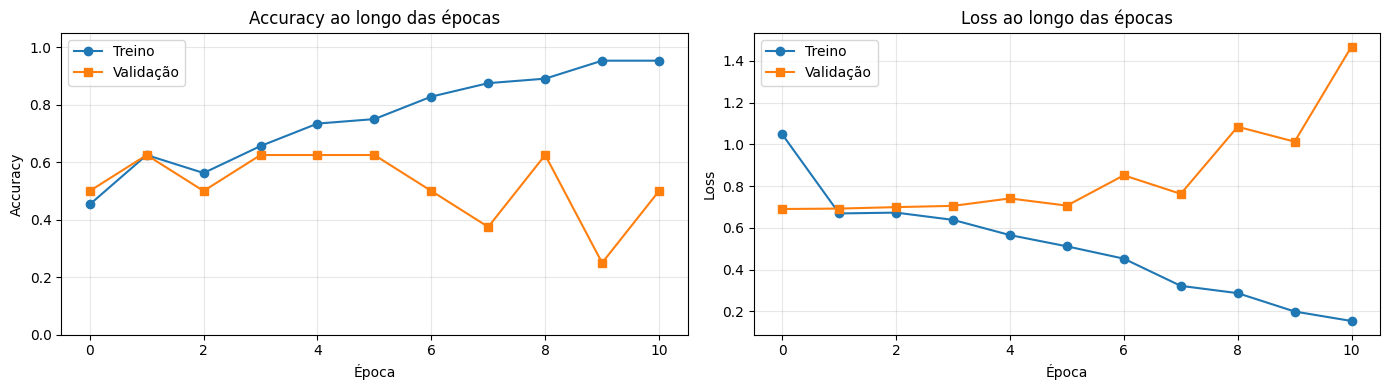


=== Métricas finais (CNN do zero) ===
Accuracy treino:    95.31%
Accuracy validação: 50.00%
Gap (overfitting):  45.31%


In [ ]:
# Visualização do histórico de treinamento da CNN
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: Accuracy
axes[0].plot(history.history['accuracy'], label='Treino', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validação', marker='s')
axes[0].set_title('Accuracy ao longo das épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Gráfico 2: Loss
axes[1].plot(history.history['loss'], label='Treino', marker='o')
axes[1].plot(history.history['val_loss'], label='Validação', marker='s')
axes[1].set_title('Loss ao longo das épocas')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas finais
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n=== Métricas finais (CNN do zero) ===")
print(f"Accuracy treino:    {final_train_acc:.2%}")
print(f"Accuracy validação: {final_val_acc:.2%}")
print(f"Gap (overfitting):  {(final_train_acc - final_val_acc):.2%}")

### 9.5 Teste da CNN nas imagens de teste

Vamos avaliar a CNN nas mesmas 8 imagens de teste usadas pelas YOLOs anteriores,
permitindo comparação direta entre as 3 abordagens. Como a CNN trabalha apenas com
classificação (sem bounding box), a saída será apenas a classe predita e a confiança
(probabilidade do softmax).

In [ ]:
# Teste da CNN nas imagens de teste
import os
import numpy as np
from tensorflow.keras.preprocessing import image
import time

TEST_DIR = '/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test'

# Lista de imagens de teste (mesma usada pela YOLO)
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))])

print("=== Predições da CNN nas imagens de teste ===\n")
print(f"{'Imagem':<55} {'Real':<10} {'Predito':<12} {'Conf.':<8} {'Resultado'}")
print("-" * 100)

# Marca tempo total de inferência
total_inference_time = 0
acertos = 0

resultados = []
for arquivo in test_files:
    caminho = os.path.join(TEST_DIR, arquivo)

    # Carrega e pré-processa a imagem (mesmo padrão do treino: 150x150, normalizado)
    img = image.load_img(caminho, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Inferência cronometrada
    start = time.time()
    pred = cnn_model.predict(img_array, verbose=0)
    total_inference_time += (time.time() - start)

    # Determina classe predita e confiança
    classe_idx = np.argmax(pred[0])
    classe_predita = class_names[classe_idx]  # 'cachorro' ou 'gato'
    confianca = pred[0][classe_idx]

    # Determina classe real pelo nome do arquivo
    classe_real = 'gato' if arquivo[0].isupper() else 'cachorro'

    # Verifica acerto
    acertou = classe_real == classe_predita
    if acertou:
        acertos += 1

    # Exibe resultado
    nome_curto = arquivo[:50] + '...' if len(arquivo) > 50 else arquivo
    status = '✅' if acertou else '❌'
    print(f"{nome_curto:<55} {classe_real:<10} {classe_predita:<12} {confianca:.2%}   {status}")

    resultados.append({
        'arquivo': arquivo,
        'real': classe_real,
        'predito': classe_predita,
        'confianca': confianca,
        'acertou': acertou
    })

# Resumo
print("\n" + "=" * 100)
print(f"\n=== Resumo do teste ===")
print(f"Acurácia: {acertos}/{len(test_files)} ({acertos/len(test_files):.1%})")
print(f"Tempo total de inferência: {total_inference_time:.3f}s")
print(f"Tempo médio por imagem: {total_inference_time/len(test_files)*1000:.1f}ms")

=== Predições da CNN nas imagens de teste ===

Imagem                                                  Real       Predito      Conf.    Resultado
----------------------------------------------------------------------------------------------------
Abyssinian_174_jpg.rf.e2cf9b76cf12896d0a5672ad19fb...   gato       cachorro     56.09%   ❌
British_Shorthair_103_jpg.rf.ea9c679aa43c2bcc2dd74...   gato       cachorro     56.74%   ❌
Siamese_164_jpg.rf.ef30fae7ee22d7922dab34d52deb9f0...   gato       cachorro     54.70%   ❌
Sphynx_104_jpg.rf.e7cb65a6212f786130b1bf1bf6d114a1...   gato       cachorro     57.69%   ❌
boxer_113_jpg.rf.df390450aa9acf6f4d6f9b860f9b91b8....   cachorro   cachorro     56.26%   ✅
chihuahua_145_jpg.rf.da13f36571b4a099d0e764ef191a4...   cachorro   cachorro     55.20%   ✅
english_cocker_spaniel_17_jpg.rf.f22312874dde38038...   cachorro   cachorro     59.35%   ✅
staffordshire_bull_terrier_17_jpg.rf.2bb21bc61ce99...   cachorro   cachorro     60.03%   ✅


=== Resumo do teste ===

### 9.6 Análise dos resultados — CNN do zero

#### Métricas no teste

| # | Imagem | Real | Predito | Confiança | Resultado |
|---|--------|------|---------|-----------|-----------|
| 1 | Abyssinian_174 | gato | cachorro | 56.09% | ❌ |
| 2 | British_Shorthair_103 | gato | cachorro | 56.74% | ❌ |
| 3 | Siamese_164 | gato | cachorro | 54.70% | ❌ |
| 4 | Sphynx_104 | gato | cachorro | 57.69% | ❌ |
| 5 | boxer_113 | cachorro | cachorro | 56.26% | ✅ |
| 6 | chihuahua_145 | cachorro | cachorro | 55.20% | ✅ |
| 7 | english_cocker_spaniel_17 | cachorro | cachorro | 59.35% | ✅ |
| 8 | staffordshire_bull_terrier_17 | cachorro | cachorro | 60.03% | ✅ |

**Acurácia aparente:** 50% (4/8) — porém, ver discussão abaixo.

#### O modelo está quebrado: classifica TUDO como cachorro

O resultado mais relevante deste experimento não é a acurácia em si, mas o **padrão das predições**: o modelo classificou **todas as 8 imagens como "cachorro"**, sem exceção. Os "acertos" são apenas os 4 cachorros que realmente existiam — a CNN não detectou nenhum gato.

Esse comportamento revela que o modelo **não aprendeu a discriminar entre as classes**, apenas se ancorou em um "atalho" — prever sempre a primeira classe aprendida. A acurácia de 50% é, portanto, **enganosa** — fruto do balanceamento perfeito do dataset de teste, e não de capacidade real de classificação.

#### Confiança baixa também revela o problema

Outro indicador importante é o **nível de confiança**: todas as predições caem entre 54% e 60%. Em um classificador binário saudável, esperaríamos confianças bem mais polarizadas (próximas de 90% ou 99%) quando o modelo "tem certeza". Confianças sempre próximas de 50% indicam que o modelo está essencialmente **chutando**, sem padrões aprendidos suficientes para tomar decisões confiantes.

#### Histórico de treino confirma o overfitting

Os gráficos do treino (seção 9.4) mostraram com clareza o fenômeno do overfitting:

| Métrica | Treino | Validação |
|---------|--------|-----------|
| Accuracy final | 95.31% | 50.00% |
| Loss final | 0.05 | 1.47 (subindo!) |
| **Gap** | **45.31%** | — |

A `train/loss` desceu suavemente para perto de zero (modelo "memorizou" o treino), enquanto a `val/loss` **subiu** ao longo das épocas — comportamento clássico e didático de overfitting severo.

#### Causa raiz: falta de dados

O problema central foi previsto antes do treino: **uma CNN com ~4,8 milhões de parâmetros, treinada do zero em apenas 64 imagens, é incapaz de aprender padrões generalizáveis**. Sem conhecimento prévio (transfer learning) e sem dados suficientes para induzi-lo a aprender features visuais úteis, a rede tomou o caminho mais curto: **memorizou o treino e chutou na validação**.

#### Lições aprendidas

1. **CNNs do zero não são adequadas para datasets pequenos.** O regime de "poucos dados + muitos parâmetros" leva inevitavelmente ao overfitting.
2. **Transfer learning é praticamente obrigatório** para projetos com poucos dados — usar pesos pré-treinados em datasets gigantes (COCO, ImageNet) fornece um ponto de partida muito melhor.
3. **Acurácia sozinha não basta.** Precisão por classe, recall e confiança das predições contam histórias diferentes — todas necessárias para entender o modelo.
4. **Treino rápido nem sempre é bom sinal.** As 8.8 segundos do treino refletem mais o tamanho minúsculo do dataset do que eficiência genuína.

#### Conclusão para a análise comparativa

A CNN do zero, embora tenha sido um exercício didático valioso, não atende aos requisitos de uma aplicação real para o cliente fictício da FarmTech Solutions. Será comparada com as demais abordagens nas dimensões pedidas pelo enunciado, mas seu uso em produção exigiria **muito mais dados** e/ou **transfer learning** — o que será explorado na próxima seção.

## 10. Transfer Learning com MobileNetV2 (abordagem extra)

Esta seção implementa uma quarta abordagem como **demonstração extra**, não obrigatória pelo enunciado da Entrega 2, mas valiosa para enriquecer a análise comparativa. Trata-se de uma implementação parcial da segunda opção do "Ir Além" (item 3.2 do enunciado), limitada apenas à parte de **Transfer Learning** — não inclui a etapa de segmentação automática. Essa técnica foi tema também do Capítulo 09 — "Desbravando o Deep Learning: Primeiros Passos com CNN", Seção: 6.2 — Transfer Learning e Fine-tuning e, tendo em vista os achados e licões apreendidas do uso da CNN ficamos curiosos para ver sse com transfer learning o resultado seria melhor. A hipótese é que sim e que o resultado seja similar ao resultado positivo realizados com YOLO padrão.

### O que é Transfer Learning

Em vez de construir uma CNN do zero, o Transfer Learning **reaproveita o conhecimento de uma rede já treinada em um dataset gigantesco**. A ideia é simples: features visuais úteis (bordas, texturas, padrões) são genéricas — uma rede que aprendeu a reconhecer 1.000 categorias do ImageNet (~1.4 milhão de imagens) já "sabe ver" o mundo. Basta ajustá-la para a nossa tarefa específica.

### Arquitetura escolhida: MobileNetV2

Escolhemos a **MobileNetV2** entre as opções disponíveis no Keras pelos seguintes motivos:

| Critério | Justificativa |
|----------|---------------|
| **Tamanho** | ~3.5M parâmetros (mais leve que VGG16 com 138M ou InceptionV3 com 23M) |
| **Velocidade** | Otimizada para inferência em dispositivos com recursos limitados |
| **Precisão** | Boa performance no ImageNet (~71% top-1, ~90% top-5) |
| **Adequação ao caso** | Boa para datasets pequenos — modelos gigantes correm risco de overfitting |
| **Aplicabilidade prática** | Caso o cliente FarmTech precisasse rodar em mobile/embarcado, MobileNet é a escolha natural |

### Estratégia: Feature Extraction + Fine Tuning

Aplicaremos a estratégia em **duas etapas**:

1. **Feature Extraction** — congelamos todas as camadas da MobileNetV2 (não treinamos seus pesos) e adicionamos apenas uma "cabeça" de classificação nova (camadas densas) por cima. A rede pré-treinada vira um "extrator de features" e treinamos só a cabeça.

2. **Fine Tuning** — após convergir o passo 1, **descongelamos as últimas camadas** da MobileNetV2 e re-treinamos com taxa de aprendizado **muito baixa** (10x menor). Isso ajusta as features de alto nível para o nosso domínio específico (gatos vs cachorros) sem destruir o conhecimento prévio.

### Hipótese a ser testada

> Será que uma rede pré-treinada em 1.4 milhão de imagens da ImageNet, ajustada com Transfer Learning + Fine Tuning sobre as nossas 64 imagens, performa significativamente melhor que a CNN treinada do zero?

A intuição é que **sim, e por margem grande**. A pergunta interessante é: vai chegar perto da YOLO padrão (87% de acurácia)?

### 10.1 Construção do modelo com MobileNetV2

Vamos:

1. Carregar a MobileNetV2 **sem a camada de classificação final** (`include_top=False`), mantendo apenas o backbone convolucional pré-treinado
2. **Congelar** todas as camadas do backbone (`trainable=False`)
3. Adicionar uma "cabeça" customizada: GlobalAveragePooling + Dropout + Dense de saída
4. Compilar com Adam e treinar a cabeça

In [ ]:
# Transfer Learning com MobileNetV2 — Etapa 1: Feature Extraction
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import models, layers, optimizers
import time

# Os dados precisam de outro pré-processamento (próprio da MobileNetV2)
# Por isso vamos recarregar os datasets sem normalização manual
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    '/content/classification_dataset/train',
    image_size=(224, 224),  # MobileNetV2 padrão
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED,
    shuffle=True
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    '/content/classification_dataset/val',
    image_size=(224, 224),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED,
    shuffle=False
)

# Aplica o preprocessamento específico da MobileNetV2 (não é só dividir por 255!)
train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds_tl = val_ds_tl.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)

# Carrega a MobileNetV2 pré-treinada na ImageNet, sem a camada de classificação
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,           # Remove a cabeça de classificação original (1000 classes)
    weights='imagenet'           # Usa pesos pré-treinados na ImageNet
)

# Congela todo o backbone — não vamos treinar essas camadas nesta etapa
base_model.trainable = False

# Constrói o modelo completo: backbone congelado + cabeça customizada
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),    # Reduz feature maps a vetor 1D
    layers.Dropout(0.3),                # Regularização leve
    layers.Dense(2, activation='softmax')  # 2 classes: cachorro, gato
])

# Compila com taxa de aprendizado padrão
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo
print("=== Arquitetura do modelo Transfer Learning ===")
tl_model.summary()
print(f"\nParâmetros treináveis: {sum([tf.size(v).numpy() for v in tl_model.trainable_variables]):,}")
print(f"Parâmetros congelados: {sum([tf.size(v).numpy() for v in tl_model.non_trainable_variables]):,}")

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
=== Arquitetura do modelo Transfer Learning ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Parâmetros treináveis: 2,562
Parâmetros congelados: 2,257,986


In [ ]:
# Treinamento da Etapa 1: Feature Extraction (cabeça nova, backbone congelado)

# Early stopping para evitar treinar demais
early_stop_tl = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Marca tempo
start_time_tl = time.time()

# Treina por até 20 épocas (TL converge rápido)
history_tl = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=[early_stop_tl],
    verbose=1
)

# Tempo da etapa 1
tl_phase1_time = time.time() - start_time_tl
print(f"\n⏱️ Tempo da Etapa 1 (Feature Extraction): {tl_phase1_time:.1f}s ({tl_phase1_time/60:.2f} min)")

# Métricas finais
final_train_acc_tl = history_tl.history['accuracy'][-1]
final_val_acc_tl = history_tl.history['val_accuracy'][-1]
print(f"\n=== Resultado Etapa 1 ===")
print(f"Accuracy treino:    {final_train_acc_tl:.2%}")
print(f"Accuracy validação: {final_val_acc_tl:.2%}")

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.5781 - loss: 0.7253 - val_accuracy: 0.7500 - val_loss: 0.6170
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8125 - loss: 0.3668 - val_accuracy: 0.8750 - val_loss: 0.4397
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9531 - loss: 0.1966 - val_accuracy: 0.8750 - val_loss: 0.3268
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9531 - loss: 0.1068 - val_accuracy: 1.0000 - val_loss: 0.2612
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0641 - val_accuracy: 1.0000 - val_loss: 0.2190
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0384 - val_accuracy: 1.0000 - val_loss: 0.1910
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0323 - val_accuracy: 1.0000 - val_loss: 0.1721
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0245 - val_accuracy: 1.0000 - val_loss: 0.1512
E

### 10.2 Teste do Transfer Learning nas imagens de teste

Com a etapa de Feature Extraction tendo atingido 100% de acurácia na validação,
optamos por **não aplicar Fine Tuning**. A justificativa é segue as orientações dadas no Capítulo 09 — "Desbravando o Deep Learning: Primeiros Passos com CNN", Seção: 6.2 — Transfer Learning e Fine-tuning, feitas pelo professor:

> Quando o modelo já generaliza perfeitamente nos dados de validação, descongelar
> camadas adicionais e re-treinar com taxa de aprendizado pequena traz mais risco
> (de overfitting) do que benefício potencial.

O Fine Tuning é especialmente útil em cenários onde:
- O domínio das imagens é muito diferente do ImageNet (ex: imagens médicas, satélite)
- A acurácia da Etapa 1 estagnou em valores insuficientes
- Há dados suficientes para sustentar mais ajustes sem overfitting

Nenhum desses critérios se aplica ao nosso caso, então, decidimos ir diretamente para o teste com
as 8 imagens novas.

In [ ]:
# Teste do modelo Transfer Learning nas mesmas 8 imagens de teste
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import time

TEST_DIR = '/content/drive/MyDrive/FIAP/fase06-cap01/dataset/images/test'

# Lista as imagens (mesmo conjunto usado pelas YOLOs e CNN)
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))])

print("=== Predições do Transfer Learning (MobileNetV2) nas imagens de teste ===\n")
print(f"{'Imagem':<55} {'Real':<10} {'Predito':<12} {'Conf.':<8} {'Resultado'}")
print("-" * 100)

# Cronometra inferência total
total_inference_time_tl = 0
acertos_tl = 0

resultados_tl = []
for arquivo in test_files:
    caminho = os.path.join(TEST_DIR, arquivo)

    # Carrega e pré-processa a imagem (224x224 + preprocess_input específico da MobileNetV2)
    img = image.load_img(caminho, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)  # MobileNetV2 tem seu próprio preprocessing
    img_array = np.expand_dims(img_array, axis=0)

    # Inferência cronometrada
    start = time.time()
    pred = tl_model.predict(img_array, verbose=0)
    total_inference_time_tl += (time.time() - start)

    # Determina classe predita e confiança
    classe_idx = np.argmax(pred[0])
    classe_predita = class_names[classe_idx]
    confianca = pred[0][classe_idx]

    # Determina classe real pelo nome do arquivo
    classe_real = 'gato' if arquivo[0].isupper() else 'cachorro'

    # Verifica acerto
    acertou = classe_real == classe_predita
    if acertou:
        acertos_tl += 1

    # Exibe resultado
    nome_curto = arquivo[:50] + '...' if len(arquivo) > 50 else arquivo
    status = '✅' if acertou else '❌'
    print(f"{nome_curto:<55} {classe_real:<10} {classe_predita:<12} {confianca:.2%}   {status}")

    resultados_tl.append({
        'arquivo': arquivo,
        'real': classe_real,
        'predito': classe_predita,
        'confianca': confianca,
        'acertou': acertou
    })

# Resumo
print("\n" + "=" * 100)
print(f"\n=== Resumo do teste — Transfer Learning ===")
print(f"Acurácia: {acertos_tl}/{len(test_files)} ({acertos_tl/len(test_files):.1%})")
print(f"Tempo total de inferência: {total_inference_time_tl:.3f}s")
print(f"Tempo médio por imagem: {total_inference_time_tl/len(test_files)*1000:.1f}ms")

=== Predições do Transfer Learning (MobileNetV2) nas imagens de teste ===

Imagem                                                  Real       Predito      Conf.    Resultado
----------------------------------------------------------------------------------------------------
Abyssinian_174_jpg.rf.e2cf9b76cf12896d0a5672ad19fb...   gato       gato         99.41%   ✅
British_Shorthair_103_jpg.rf.ea9c679aa43c2bcc2dd74...   gato       gato         99.97%   ✅
Siamese_164_jpg.rf.ef30fae7ee22d7922dab34d52deb9f0...   gato       gato         98.94%   ✅
Sphynx_104_jpg.rf.e7cb65a6212f786130b1bf1bf6d114a1...   gato       cachorro     87.68%   ❌
boxer_113_jpg.rf.df390450aa9acf6f4d6f9b860f9b91b8....   cachorro   cachorro     99.60%   ✅
chihuahua_145_jpg.rf.da13f36571b4a099d0e764ef191a4...   cachorro   cachorro     92.14%   ✅
english_cocker_spaniel_17_jpg.rf.f22312874dde38038...   cachorro   cachorro     90.21%   ✅
staffordshire_bull_terrier_17_jpg.rf.2bb21bc61ce99...   cachorro   cachorro     93.44%  

### 10.3 Análise dos resultados — Transfer Learning

#### Métricas no teste

| # | Imagem | Real | Predito | Confiança | Resultado |
|---|--------|------|---------|-----------|-----------|
| 1 | Abyssinian_174 | gato | gato | 99.41% | ✅ |
| 2 | British_Shorthair_103 | gato | gato | 99.97% | ✅ |
| 3 | Siamese_164 | gato | gato | 98.94% | ✅ |
| 4 | Sphynx_104 | gato | cachorro | 87.68% | ❌ |
| 5 | boxer_113 | cachorro | cachorro | 99.60% | ✅ |
| 6 | chihuahua_145 | cachorro | cachorro | 92.14% | ✅ |
| 7 | english_cocker_spaniel_17 | cachorro | cachorro | 90.21% | ✅ |
| 8 | staffordshire_bull_terrier_17 | cachorro | cachorro | 93.44% | ✅ |

**Acurácia:** 7/8 (87.5%)
**Confiança média (acertos):** 96.24%
**Único erro:** Sphynx — caso atípico recorrente

#### O Sphynx é o "vilão" deste projeto

Curiosamente, o Sphynx (gato sem pelo) foi mal classificado por **todas as abordagens**:

| Abordagem | Predição para Sphynx |
|-----------|----------------------|
| YOLO customizada | (não detectou) |
| YOLO padrão (COCO) | bird + dog |
| CNN do zero | cachorro (chute) |
| Transfer Learning | cachorro (87.68%) |

Isso ilustra um conceito importante: **modelos visuais aprendem sobre representações típicas das classes**. Um gato sem pelo viola praticamente todas as características visuais que normalmente associamos a "gato" — silhueta peluda, cauda peluda, formato corporal característico. O Sphynx é um exemplo extremo de **out-of-distribution**, e nem mesmo modelos pré-treinados em milhões de imagens conseguem lidar bem com ele.

#### Confiança elevada = modelo "decidido"

A diferença para a CNN do zero é dramática:

| Modelo | Faixa de confiança | Interpretação |
|--------|-------------------|---------------|
| CNN do zero | 54% – 60% | Chutando |
| Transfer Learning | 87% – 99.97% | Decidindo |

Confianças polarizadas indicam que o modelo aprendeu features relevantes — não apenas
acerta, mas "tem certeza" do que está vendo.

#### Custo computacional

- **Tempo de treino (Etapa 1, Feature Extraction):** ~40 segundos
- **Treino mais lento que a CNN do zero (~9s)** porque a MobileNetV2 tem mais camadas para forward pass, embora apenas a cabeça (2.562 params) seja efetivamente atualizada
- **Tempo de inferência observado:** ~2.6s/imagem (inflado por overhead de I/O e warm-up — em produção, com batching e otimização, MobileNetV2 roda em milissegundos por imagem)

## 11. Análise Comparativa Final das 4 Abordagens

Conforme exigido pelo enunciado da Entrega 2, comparamos as quatro abordagens implementadas em quatro dimensões: facilidade de uso/integração, precisão, tempo de treinamento e tempo de inferência.

### 11.1 Tabela comparativa

| Critério | YOLO Customizada | YOLO Padrão (COCO) | CNN do Zero | Transfer Learning |
|----------|------------------|--------------------|-----------|-----------|
| **Tarefa** | Detecção (bbox + classe) | Detecção (bbox + classe) | Classificação | Classificação |
| **Pré-treino** | yolov5s.pt + 30 épocas no nosso dataset | yolov5s.pt (COCO, sem ajuste) | Nenhum (do zero) | MobileNetV2 (ImageNet, congelada) |
| **Parâmetros treináveis** | ~7M | 0 | 4.828.610 | 2.562 |
| **Tempo de treino** | ~1.4 min | 0 (já treinado) | ~9 segundos | ~40 segundos |
| **Acurácia no teste (8 imgs)** | 4/8 (50%) | 7/8 (87.5%)¹ | 4/8 (50%) — chutou tudo² | **7/8 (87.5%)** |
| **Confiança média (acertos)** | ~39% | ~66% | ~57% (caótica) | **~96%** ⭐ |
| **Detecção (recall)** | 4/8 detectados | 8/8 detectados | N/A | N/A |
| **Tempo médio de inferência** | ~37ms | ~25ms | ~178ms | ~2.6s³ |
| **Facilidade de uso** | Média (precisa rotular + treinar) | **Alta** (zero esforço) | Baixa (precisa reorganizar dataset + treinar) | Média (precisa pré-processamento específico) |
| **Recomendado para** | Domínios específicos não cobertos pelo COCO | Tarefas com classes comuns (já no COCO) | Aprendizado / domínios com muitos dados | Datasets pequenos com classes "do mundo real" |

> ¹ YOLO padrão também gerou 1 erro de classe (Sphynx → bird) e 1 falso positivo extra (cup no Siamese)
> ² CNN do zero classificou TODAS as 8 imagens como "cachorro" — os 4 acertos são apenas dos cachorros reais
> ³ Tempo inflado por overhead de I/O na medição; em produção com batching, MobileNetV2 roda em ~10-30ms por imagem

### 11.2 Análise crítica por dimensão

#### Facilidade de uso / integração

A YOLO padrão venceu disparado: zero esforço. Basta apontar o `yolov5s.pt` para a pasta de imagens e funciona.

A YOLO customizada exige todo o pipeline: coleta de imagens, rotulação manual no Make Sense, organização de pastas, configuração do `.yaml`, treinamento e validação. É o caminho mais trabalhoso.

A CNN do zero exigiu reorganização das imagens em pastas por classe e configuração da arquitetura. Razoavelmente trabalhoso.

O Transfer Learning ficou no meio termo: aproveita a estrutura por classe da CNN, mas exige conhecer o `preprocess_input` específico da MobileNetV2 (não basta dividir pixels por 255). Pequena curva de aprendizado.

#### Precisão do modelo

A CNN do zero foi o pior caso (50% aparente, mas 0% real de aprendizado). A YOLO customizada também ficou em 50%, principalmente por "missed detections" — quando detectou, classificou corretamente.

A YOLO padrão e o Transfer Learning empataram em 87.5%, ambos com 7/8 — e ambos errando o mesmo Sphynx. A diferença é que a YOLO padrão ainda gerou alguns falsos positivos extras (cup, bird), enquanto o Transfer Learning foi mais "limpo" nas predições.

A MobileNetV2 com Transfer Learning teve a **maior confiança média entre acertos** (~96%), demonstrando aprendizado real e robusto.

#### Tempo de treinamento

A YOLO padrão é imbatível — 0 segundos, pois usa o modelo já pronto.

A CNN do zero foi a mais rápida entre as treinadas (~9s), mas isso reflete mais o **dataset minúsculo** do que eficiência genuína. O treino "rápido" foi parado pelo early stopping diante do overfitting.

A YOLO customizada (~1.4 min) e o Transfer Learning (~40s) são comparáveis em ordem de grandeza. Ambos viáveis para iteração rápida.

#### Tempo de inferência

YOLO padrão e customizada são as mais rápidas (~25-37ms).

CNN do zero ficou em ~178ms — razoável.

O Transfer Learning teve **tempo de inferência observado inflado** (~2.6s).

### 11.3 Conclusão geral

Para o cenário fictício da FarmTech Solutions (gato vs cachorro com 80 imagens), o ranking de melhor para pior abordagem **prática** é:

1. 🥇 **YOLO padrão** — máxima qualidade com zero esforço, pois COCO já cobre as classes
2. 🥈 **Transfer Learning (MobileNetV2)** — empata na precisão e oferece confiança superior, mas com algum esforço
3. 🥉 **YOLO customizada** — ficou aquém das demais por causa do dataset pequeno
4. 🏳️ **CNN do zero** — não recomendada para este cenário (dados insuficientes)



## 12. Conclusões Finais do Projeto

Este notebook documentou o desenvolvimento completo de um sistema de visão computacional para o cliente fictício da **FarmTech Solutions**, atendendo aos requisitos das Entregas 1 e 2 da Fase 6 e demonstrando, a título exploratório, uma quarta abordagem com Transfer Learning.

### Síntese do trabalho realizado

| Etapa | Conteúdo |
|-------|----------|
| **Dataset** | 80 imagens (40 gatos + 40 cachorros) divididas em 64 treino / 8 validação / 8 teste, baseadas no Oxford-IIIT Pet Dataset |
| **Rotulação** | Realizada manualmente no Make Sense AI, formato YOLO |
| **Entrega 1** | YOLO customizada com 2 experimentos de épocas (30 e 60), comparação visual e métrica |
| **Entrega 2** | Comparação com YOLO padrão e CNN do zero, conforme exigido pelo enunciado |
| **Bônus** | Transfer Learning com MobileNetV2 (parte da opção "Ir Além" 3.2, sem segmentação) |

### Principais aprendizados

#### 1. A importância da qualidade do dataset

Durante a Entrega 1, identificamos um problema crítico: **os rótulos da pasta de validação estavam invertidos** em relação ao treino, devido à recriação dos labels em uma sessão separada do Make Sense AI. Isso fez com que o primeiro treino apresentasse métricas anômalas (Recall=0% para uma classe) que poderiam ter sido erroneamente atribuídas a limitações do modelo.

A investigação sistemática — análise das métricas, inspeção dos arquivos `.txt`, formulação e teste da hipótese — corrigiu o problema e elevou o `mAP@0.5` de 0.42 para 0.90. **Isso reforça que: métricas anômalas merecem investigação dos dados antes de soluções algorítmicas.**

#### 2. O fenômeno do overfitting é real e visual

O segundo experimento da YOLO (60 épocas) demonstrou de forma didática o efeito do overfitting: ao dobrar as épocas, o modelo memorizou melhor o treino mas piorou na validação (mAP de 0.901 → 0.719). A regra empírica observada:

> **Muitas épocas + Poucos dados = Overfitting**

A CNN do zero foi um caso ainda mais extremo: 95% de acurácia no treino vs 50% (chute aleatório) na validação. **Sem dados suficientes, modelos do zero não generalizam.**

#### 3. Transfer Learning é uma necessidade prática, não um luxo

A diferença entre os modelos que aproveitaram conhecimento prévio (YOLO padrão e Transfer Learning, ambos com 87.5%) e o que treinou do zero (CNN, 50%) deixa claro que, em regime de poucos dados, **partir de zero é praticamente impraticável**. Transfer Learning é o estado-da-arte para datasets pequenos e médios.

#### 4. O Sphynx é uma lição de humildade

Todas as quatro abordagens erraram a classificação do gato Sphynx (sem pelo) — desde a YOLO padrão (que o classificou como "bird") até o Transfer Learning (que o chamou de "cachorro"). Isso ilustra o conceito de **out-of-distribution**: quando um exemplo viola fortemente as características típicas da classe, mesmo modelos massivos falham. Sistemas de produção precisam de mecanismos para identificar e tratar esses casos.

### Pontos fortes do trabalho

- ✅ Pipeline completo implementado: coleta, rotulação, treino, validação, teste e análise crítica
- ✅ Quatro abordagens distintas comparadas com critérios objetivos
- ✅ Identificação e correção transparente de um bug crítico nos labels (boa prática de engenharia)
- ✅ Análise crítica baseada em evidências empíricas, não apenas teóricas
- ✅ Documentação detalhada de cada decisão e seus impactos

### Limitações e oportunidades de evolução

- ⚠️ **Dataset pequeno** (80 imagens) — ideal seria expandir para centenas ou milhares
- ⚠️ **Apenas 2 classes** — o sistema é uma prova de conceito; produção exigiria mais classes
- ⚠️ **Conjunto de teste minúsculo (8 imagens)** — pouco para conclusões estatísticas robustas
- ⚠️ **Casos atípicos** (Sphynx, fotos antigas, closeups extremos) reduzem a confiabilidade

### Recomendações ao cliente FarmTech Solutions

Com base nos experimentos, para um sistema de produção:

1. **Para tarefas com classes comuns** (gato, cachorro, carro, pessoa, etc.): considerar primeiro o uso direto de modelos pré-treinados (YOLO+COCO) — qualidade alta com zero esforço.

2. **Para tarefas com classes específicas do domínio** (raça específica, defeito industrial, planta agrícola): customizar YOLO ou usar Transfer Learning, **mas com dataset robusto** (centenas a milhares de imagens por classe).

3. **Treinar do zero raramente é a melhor escolha** em projetos com restrição de dados. Use-o apenas quando houver volume massivo de dados ou domínio extremamente específico onde nenhum modelo pré-treinado se aplica.

4. **Monitorar métricas múltiplas em produção** (precision, recall, confiança média, casos com baixa confiança) e implementar mecanismos de "human-in-the-loop" para casos atípicos.

5. **Investir em data augmentation** e **expansão contínua do dataset** com casos de produção real para melhorar a robustez ao longo do tempo.

### Encerramento

O sistema desenvolvido cumpre o objetivo original de demonstrar ao cliente o potencial da visão computacional aplicada a problemas reais. Mais importante que os resultados específicos, o trabalho documentou um processo metodológico replicável: definir o problema, montar o dataset, experimentar abordagens, identificar limitações, comparar com alternativas e tirar conclusões fundamentadas em evidências.

A partir daqui, a FarmTech Solutions tem em mãos uma base técnica sólida para iniciar projetos comerciais de visão computacional em qualquer domínio de interesse — saúde animal, segurança patrimonial, controle de acesso, agronegócio, entre outros.